# Retail Intelligence — Executive Summary

**What this is:** a customer segmentation of a UK-based online gift-ware retailer's transaction history (Dec 2009 – Dec 2011, [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)), built on Recency/Frequency/Monetary (RFM) behavior and unsupervised clustering, to identify distinct customer groups and the action each one warrants.

## Scope

- **1,067,371** raw transaction lines → **820,647** after removing bad-debt adjustments, non-merchandise line items (postage, fees, test rows), and transactions with no customer identifier attached.
- **5,840 identified customers** with at least one genuine net purchase form the segmentation population. **This excludes ~241,000 transactions with no `Customer ID`** (guest/unidentified purchases) — the findings below describe *identified* customers only, not total business volume.

## Method, in brief

Recency, Frequency, and Monetary were computed per customer with cancellations netted out using a time-respecting, FIFO lot-matching rule (a cancellation can only offset a purchase that happened *before* it — verified against 7 hand-built test cases plus real examples where a naive approach got it wrong). The three metrics were log-transformed and scaled, then segmented two ways: **K-Means** (k=4, chosen via elbow/silhouette and confirmed stable — 99.1% average agreement across 8 random seeds) for the general customer base, and **DBSCAN** to independently identify extreme high-value outliers by density rather than forcing them into a K-Means cluster. The two were combined into a five-segment hybrid model, which measurably reduced internal skew in the high-value cluster (mean/median ratio dropped from 2.08 to 1.47) and was sanity-checked against customer geography and purchase-year cohort to separate genuine behavioral patterns from data artifacts.

## The Five Segments

| Segment | Customers | Share | Median Recency | Median Frequency | Median Value | Action |
|---|---:|---:|---:|---:|---:|---|
| **Champions** | 1,186 | 20.3% | 17 days | 12 orders | £4,557 | VIP retention, early access, priority service |
| **Exceptional high-value** | 82 | 1.4% | 28 days | 23 orders | £18,164 | Named account management — disproportionately international, likely wholesale/reseller relationships |
| **At-risk established** | 1,427 | 24.4% | 185 days | 4 orders | £1,437 | Proactive win-back — real repeat customers whose engagement is fading |
| **Recent developing** | 1,208 | 20.7% | 24 days | 3 orders | £707 | Split by tenure: ~61% are genuinely new (onboarding nurture); ~39% have been customers 2+ years without escalating (low priority for growth spend) |
| **Lapsed low-value** | 1,937 | 33.2% | 402 days | 1 order | £273 | First-purchase follow-up, **not** a loyalty win-back — 61% never became repeat customers at all |

## Key Finding Worth Highlighting

The largest segment (Lapsed low-value, a third of the customer base) is commonly mislabeled in RFM analyses as "churned loyalists." The data says otherwise: most of this group made one purchase, early in the observation window, and never returned — a conversion problem, not a retention problem. Treating it as churn and sending "we miss you" messaging to people who don't remember having a relationship with the brand would misdirect retention spend; the right lever is a first-purchase follow-up sequence instead.

## Caveats

- The Exceptional high-value segment (82 customers) is itself internally heterogeneous — it spans "very good customer" to "true mega-wholesaler" (customer value ranges up to £606K within this group). If finer VIP-tier distinction is needed, a further density-based split (HDBSCAN) is the natural next step, not yet built.
- Cancellation netting uses a FIFO (oldest-purchase-first) matching rule rather than matching by price. A price-aware alternative was built and compared: it agrees with FIFO for 90.8% of customers, and the aggregate difference is negligible (0.25% of total customer value) — but for a handful of individuals the choice matters more (one customer's value differs by ~£24K between the two methods, with no effect on their segment placement). FIFO was kept as the primary method for its simplicity and because it doesn't depend on trusting the price field's accuracy on every cancellation row; the price-aware version remains available if a specific customer's figure ever needs closer scrutiny.
- Cluster boundaries carry some inherent uncertainty for customers sitting near the edge between two segments; the K-Means stability check found 98.3–100% agreement across reruns, meaning the segments themselves are robust, but a handful of borderline individuals could shift segment on any given re-run.

# Retail Intelligence — Data Loading

Source: [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (`uci data/online_retail_II.xlsx`)

The workbook contains two sheets, one per year of transactions:
- `Year 2009-2010`
- `Year 2010-2011`

Each sheet is read separately, tagged with its origin via a `source_sheet` column, then concatenated into a single DataFrame.

In [181]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("uci data/online_retail_II.xlsx")

SHEETS = ["Year 2009-2010", "Year 2010-2011"]

In [182]:
# Read each sheet separately and tag it with its source before combining.
sheet_frames = {}

for sheet_name in SHEETS:
    df_sheet = pd.read_excel(DATA_PATH, sheet_name=sheet_name)
    df_sheet["source_sheet"] = sheet_name
    sheet_frames[sheet_name] = df_sheet
    print(f"{sheet_name}: {df_sheet.shape[0]:,} rows, {df_sheet.shape[1]} columns")

df_2009_2010 = sheet_frames["Year 2009-2010"]
df_2010_2011 = sheet_frames["Year 2010-2011"]

Year 2009-2010: 525,461 rows, 9 columns
Year 2010-2011: 541,910 rows, 9 columns


In [183]:
# Concatenate the two tagged sheets into one DataFrame.
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

print(f"Combined shape: {df.shape}")
print("\nRows per source_sheet:")
print(df["source_sheet"].value_counts())

df.head()

Combined shape: (1067371, 9)

Rows per source_sheet:
source_sheet
Year 2010-2011    541910
Year 2009-2010    525461
Name: count, dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,Year 2009-2010


## Baseline Profile (before any cleaning)

Capture the state of `df` as-loaded — shape, dtypes, nulls, and cardinality per column — plus two sanity checks (`InvoiceDate` parsed as datetime, row count matches the documented ~1,067,371 total). This is the reference point every later filtering step gets diffed against.

In [184]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1067371, 9)


In [185]:
df.dtypes

Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[us]
Price                  float64
Customer ID            float64
Country                    str
source_sheet               str
dtype: object

In [186]:
df.isnull().sum()

Invoice              0
StockCode            0
Description       4382
Quantity             0
InvoiceDate          0
Price                0
Customer ID     243007
Country              0
source_sheet         0
dtype: int64

In [187]:
df.nunique()

Invoice         53628
StockCode        5305
Description      5698
Quantity         1057
InvoiceDate     47635
Price            2807
Customer ID      5942
Country            43
source_sheet        2
dtype: int64

In [188]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


In [189]:
# Sanity check 1: InvoiceDate must be a real datetime, not object/string.
invoice_date_dtype = df["InvoiceDate"].dtype
print(f"InvoiceDate dtype: {invoice_date_dtype}")

assert pd.api.types.is_datetime64_any_dtype(df["InvoiceDate"]), (
    f"InvoiceDate parsed as {invoice_date_dtype}, not datetime — "
    "check parse_dates on read_excel or convert with pd.to_datetime()."
)
print("Confirmed: InvoiceDate is datetime64.")

InvoiceDate dtype: datetime64[us]
Confirmed: InvoiceDate is datetime64.


In [190]:
# Sanity check 2: row count must match the documented ~1,067,371-row total.
EXPECTED_ROWS = 1_067_371

assert df.shape[0] == EXPECTED_ROWS, (
    f"Row count {df.shape[0]:,} does not match documented total {EXPECTED_ROWS:,} — "
    "investigate before proceeding (dropped/duplicated rows on read?)."
)
print(f"Confirmed: row count is {df.shape[0]:,}, matching the documented total.")

Confirmed: row count is 1,067,371, matching the documented total.


In [191]:
# Freeze this profile as `baseline` — every later cleaning/filter step should be
# diffed against these numbers (e.g. `baseline["shape"][0] - df.shape[0]` rows dropped).
baseline = {
    "shape": df.shape,
    "dtypes": df.dtypes.copy(),
    "null_counts": df.isnull().sum(),
    "nunique": df.nunique(),
}

print(f"Baseline captured: {baseline['shape'][0]:,} rows x {baseline['shape'][1]} columns.")

Baseline captured: 1,067,371 rows x 9 columns.


## Column Structure Profilling... Invoice Letter-Prefix Check

`Invoice` is stored as text, and some values carry a leading letter code instead of being purely numeric — most notably `C` for cancellations. Extract that prefix and count it before deciding how to route each group (drop, keep separately, net against sales, etc.).

In [192]:
invoice_prefix = df["Invoice"].astype(str).str.extract(r"^([A-Za-z]+)")[0]

prefix_counts = invoice_prefix.value_counts(dropna=False)
print("Invoice prefix counts (NaN = purely numeric invoice, i.e. normal sale):")
prefix_counts

Invoice prefix counts (NaN = purely numeric invoice, i.e. normal sale):


0
NaN    1047871
C        19494
A            6
Name: count, dtype: int64

In [193]:
# Same counts as a share of total rows, plus one example row per prefix
# (including the no-prefix/purely-numeric group) to sanity-check what each code means.
prefix_share = (prefix_counts / len(df) * 100).round(2)
print("Share of total rows (%):")
print(prefix_share)

print("\nSample row per prefix:")
for prefix_value in prefix_counts.index:
    mask = invoice_prefix.isna() if pd.isna(prefix_value) else (invoice_prefix == prefix_value)
    label = "NaN (numeric invoice)" if pd.isna(prefix_value) else prefix_value
    example = df.loc[mask].iloc[0]
    print(f"\n--- prefix: {label} ---")
    print(example[["Invoice", "StockCode", "Description", "Quantity", "Price"]])

Share of total rows (%):
0
NaN   98.17
C      1.83
A      0.00
Name: count, dtype: float64

Sample row per prefix:

--- prefix: NaN (numeric invoice) ---
Invoice                                     489434
StockCode                                    85048
Description    15CM CHRISTMAS GLASS BALL 20 LIGHTS
Quantity                                        12
Price                                         6.95
Name: 0, dtype: object

--- prefix: C ---
Invoice                         C489449
StockCode                         22087
Description    PAPER BUNTING WHITE LACE
Quantity                            -12
Price                              2.95
Name: 178, dtype: object

--- prefix: A ---
Invoice                A506401
StockCode                    B
Description    Adjust bad debt
Quantity                     1
Price                -53594.36
Name: 179403, dtype: object


## Route Invoice Types: Tag, Then Drop Adjustments Only

Decision:
- **`sale`** (no prefix) and **`C` cancellations** are both kept. Cancellations carry a negative `Quantity`, so leaving them in lets aggregates (e.g. `sum(Quantity)`, `sum(Quantity * Price)`) net naturally against the sales they reverse — no manual invoice-matching needed.
- **`A` adjustments** (bad-debt write-offs, not real transactions — `StockCode == "B"`) are dropped outright. They'd distort price/quantity analysis and aren't retail activity.

An `invoice_type` column is added first so the distinction survives downstream filtering and grouping.

In [194]:
import numpy as np

# Tag every row by its invoice prefix before filtering anything out.
df["invoice_type"] = np.select(
    [invoice_prefix.isna(), invoice_prefix == "C", invoice_prefix == "A"],
    ["sale", "cancellation", "adjustment"],
    default="other",
)

print("invoice_type counts (should match the prefix counts above):")
df["invoice_type"].value_counts()

invoice_type counts (should match the prefix counts above):


invoice_type
sale            1047871
cancellation      19494
adjustment            6
Name: count, dtype: int64

##### dataframe for account adjustment - for audit and financial reconciliation

In [195]:
accounting_adjustments = df[
    df["Invoice"].astype("string").str.startswith("A", na=False)
].copy()

accounting_adjustments.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_sheet,invoice_type
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,Year 2009-2010,adjustment
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,Year 2009-2010,adjustment
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,Year 2009-2010,adjustment
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,Year 2010-2011,adjustment
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,Year 2010-2011,adjustment


#### Net sales dataframe - only sales, no cancellation or adjustments


In [196]:
sales_df = df[
    ~df["Invoice"].astype("string").str.startswith(("A", "C"), na=False)
].copy()

#### Gross Sales dataframe - sales and cancellations

In [197]:
df.shape[0]

1067371

In [198]:
# Drop adjustments only. Sales and cancellations both stay.
rows_before = df.shape[0]

gross_df = df[df["invoice_type"] != "adjustment"].reset_index(drop=True)

rows_dropped = rows_before - gross_df.shape[0]
print(f"Dropped {rows_dropped} adjustment row(s).")
print(f"Shape now: {gross_df.shape}  (baseline was {baseline['shape']})")
print(f"Rows removed vs. baseline so far: {baseline['shape'][0] - gross_df.shape[0]:,}")

gross_df["invoice_type"].value_counts()

gross_df.head()

Dropped 6 adjustment row(s).
Shape now: (1067365, 10)  (baseline was (1067371, 9))
Rows removed vs. baseline so far: 6


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_sheet,invoice_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,Year 2009-2010,sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010,sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010,sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,Year 2009-2010,sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,Year 2009-2010,sale


## Quantity / Price Oddity Check (Beyond Cancellations)

Cancellations (`invoice_type == "cancellation"`) already explain negative `Quantity`. Anything else unusual — zero prices, negative prices, negative quantities on non-cancellation rows, or extreme outliers — is a separate data-quality question. Working on `df` (== `gross_df`: sales + cancellations, adjustments already dropped).

In [199]:
# Overall distribution shape for both columns first.
pd.set_option('display.float_format', '{:.2f}'.format)
print("Quantity summary:")
print(gross_df["Quantity"].describe())
print("\nPrice summary:")
print(gross_df["Price"].describe())

Quantity summary:
count   1067365.00
mean          9.94
std         172.71
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00
Name: Quantity, dtype: float64

Price summary:
count   1067365.00
mean          4.79
std          94.83
min           0.00
25%           1.25
50%           2.10
75%           4.15
max       38970.00
Name: Price, dtype: float64


In [200]:
# Zero-price rows: free items, giveaways, or data entry errors — not inherently
# invalid, but worth knowing how many and what they look like.
zero_price = gross_df[gross_df["Price"] == 0]
print(f"Rows with Price == 0: {len(zero_price):,} ({len(zero_price) / len(df) * 100:.3f}% of rows)")
print("\nBy invoice_type:")
print(zero_price["invoice_type"].value_counts())
print("\nSample rows:")
zero_price[["Invoice", "StockCode", "Description", "Quantity", "Price", "invoice_type"]].head(10)

Rows with Price == 0: 6,202 (0.581% of rows)

By invoice_type:
invoice_type
sale    6202
Name: count, dtype: int64

Sample rows:


,Invoice,StockCode,Description,Quantity,Price,invoice_type
263,489464,21733,85123a mixed,-96,0.00,sale
283,489463,71477,short,-240,0.00,sale
284,489467,85123A,21733 mixed,-192,0.00,sale
470,489521,21646,NaN,-50,0.00,sale
3114,489655,20683,NaN,-44,0.00,sale
3161,489659,21350,NaN,230,0.00,sale
3162,489660,35956,lost,-1043,0.00,sale
3168,489663,35605A,damages,-117,0.00,sale
3731,489781,84292,NaN,17,0.00,sale
4296,489806,18010,NaN,-770,0.00,sale


In [201]:
# Negative price: unlike Quantity, cancellations do NOT carry a negative Price
# (they cancel a quantity, not re-price it). So any negative Price here — on
# a sale OR a cancellation row — is a genuine oddity, not expected behavior.
negative_price = gross_df[gross_df["Price"] < 0]
print(f"Rows with Price < 0: {len(negative_price):,} ({len(negative_price) / len(df) * 100:.3f}% of rows)")
print("\nBy invoice_type:")
print(negative_price["invoice_type"].value_counts())
print("\nSample rows:")
negative_price[["Invoice", "StockCode", "Description", "Quantity", "Price", "invoice_type"]].head(10)

Rows with Price < 0: 0 (0.000% of rows)

By invoice_type:
Series([], Name: count, dtype: int64)

Sample rows:


,Invoice,StockCode,Description,Quantity,Price,invoice_type


In [202]:
# Negative Quantity on a row NOT tagged as a cancellation: the reverse of the
# expected pattern (cancellations should be the only source of negative Quantity).
negative_qty_non_cancel = gross_df[(gross_df["Quantity"] < 0) & (gross_df["invoice_type"] != "cancellation")]
print(
    f"Rows with Quantity < 0 but invoice_type != 'cancellation': "
    f"{len(negative_qty_non_cancel):,} ({len(negative_qty_non_cancel) / len(df) * 100:.3f}% of rows)"
)
print("\nSample rows:")
negative_qty_non_cancel[["Invoice", "StockCode", "Description", "Quantity", "Price", "invoice_type"]].head(10)

Rows with Quantity < 0 but invoice_type != 'cancellation': 3,457 (0.324% of rows)

Sample rows:


,Invoice,StockCode,Description,Quantity,Price,invoice_type
263,489464,21733,85123a mixed,-96,0.00,sale
283,489463,71477,short,-240,0.00,sale
284,489467,85123A,21733 mixed,-192,0.00,sale
470,489521,21646,NaN,-50,0.00,sale
3114,489655,20683,NaN,-44,0.00,sale
3162,489660,35956,lost,-1043,0.00,sale
3168,489663,35605A,damages,-117,0.00,sale
4296,489806,18010,NaN,-770,0.00,sale
4538,489820,21133,invcd as 84879?,-720,0.00,sale
4566,489821,85049G,NaN,-240,0.00,sale


In [203]:
# Extreme outliers: largest/smallest Quantity and Price, regardless of sign,
# to spot data-entry errors (e.g. a stray extra zero) vs. genuine bulk orders.
cols = ["Invoice", "StockCode", "Description", "Quantity", "Price", "invoice_type"]

print("Largest Quantity (top 5):")
print(gross_df.nlargest(5, "Quantity")[cols])

print("\nSmallest / most negative Quantity (top 5):")
print(gross_df.nsmallest(5, "Quantity")[cols])

print("\nLargest Price (top 5):")
print(gross_df.nlargest(5, "Price")[cols])

print("\nSmallest / most negative Price (top 5):")
print(gross_df.nsmallest(5, "Price")[cols])

Largest Quantity (top 5):
        Invoice StockCode                         Description  Quantity  \
1065876  581483     23843         PAPER CRAFT , LITTLE BIRDIE     80995   
587077   541431     23166      MEDIUM CERAMIC TOP STORAGE JAR     74215   
90857    497946     37410  BLACK AND WHITE PAISLEY FLOWER MUG     19152   
127166   501534     21099         SET/6 STRAWBERRY PAPER CUPS     12960   
127168   501534     21091         SET/6 WOODLAND PAPER PLATES     12960   

         Price invoice_type  
1065876   2.08         sale  
587077    1.04         sale  
90857     0.10         sale  
127166    0.10         sale  
127168    0.10         sale  

Smallest / most negative Quantity (top 5):
         Invoice StockCode                     Description  Quantity  Price  \
1065877  C581484     23843     PAPER CRAFT , LITTLE BIRDIE    -80995   2.08   
587082   C541433     23166  MEDIUM CERAMIC TOP STORAGE JAR    -74215   1.04   
303994    519017     22759                             NaN    

         Invoice     StockCode   Description  Quantity    Price  invoice_type
748139   C556445             M        Manual        -1 38970.00  cancellation
241823   C512770             M        Manual        -1 25111.09  cancellation
241826    512771             M        Manual         1 25111.09          sale
320579   C520667  BANK CHARGES  Bank Charges        -1 18910.69  cancellation
1050057  C580605     AMAZONFEE    AMAZON FEE        -1 17836.46  cancellation

Smallest / most negative Price (top 5):
     Invoice StockCode   Description  Quantity  Price invoice_type
263   489464     21733  85123a mixed       -96   0.00         sale
283   489463     71477         short      -240   0.00         sale
284   489467    85123A   21733 mixed      -192   0.00         sale
470   489521     21646           NaN       -50   0.00         sale
3114  489655     20683           NaN       -44   0.00         sale


## StockCode Audit: Non-Merchandise Codes

The Price-outlier check above turned up `StockCode`s that aren't products at all (`M` = "Manual", `BANK CHARGES`, `AMAZONFEE`). Real product codes in this dataset follow a fairly consistent pattern — 5 digits, optionally followed by 1–2 letters (e.g. `85123A`). Anything that doesn't match that pattern is a candidate for the same kind of non-merchandise contamination, so pull the full list before deciding what to do with it. Working on `gross_df`.

In [204]:
# Standard product code: 5 digits, optionally followed by 1-2 letters (e.g. "85123A").
# Anything else (pure letters, short codes, etc.) is worth a closer look.
STANDARD_CODE_PATTERN = r"^\d{5}[A-Za-z]{0,2}$"

is_standard_code = gross_df["StockCode"].astype(str).str.match(STANDARD_CODE_PATTERN)
non_standard = gross_df[~is_standard_code]

print(f"Rows with non-standard StockCode: {len(non_standard):,} ({len(non_standard) / len(gross_df) * 100:.3f}% of rows)")
print(f"Unique non-standard codes: {non_standard['StockCode'].nunique():,} (of {gross_df['StockCode'].nunique():,} total unique codes)")

Rows with non-standard StockCode: 6,088 (0.570% of rows)
Unique non-standard codes: 62 (of 5,304 total unique codes)


In [205]:
# Break the non-standard codes down individually: row count, net quantity,
# net revenue (Quantity * Price, so cancellations net out), and a sample
# description — enough to judge what each code is and how much it matters.
code_summary = (
    non_standard.assign(revenue=non_standard["Quantity"] * non_standard["Price"])
    .groupby("StockCode")
    .agg(
        rows=("StockCode", "size"),
        net_quantity=("Quantity", "sum"),
        net_revenue=("revenue", "sum"),
        sample_description=("Description", "first"),
    )
    .sort_values("rows", ascending=False)
)

print(f"{len(code_summary)} distinct non-standard StockCodes:")
code_summary

62 distinct non-standard StockCodes:


,rows,net_quantity,net_revenue,sample_description
StockCode,,,,
POST,2122,10108,112341.00,POSTAGE
DOT,1446,2938,322647.47,DOTCOM POSTAGE
M,1421,4607,-82796.32,Manual
C2,282,716,13386.00,CARRIAGE
D,177,-2872,-13484.54,Discount
...,...,...,...,...
DCGSLGIRL,1,-57,0.00,None
DCGS0071,1,-2,0.00,None
DCGS0073,1,-4,0.00,ebay


In [206]:
# Sanity check: is any of this "non-standard" just whitespace noise around an
# otherwise normal code (e.g. "47503J " vs "47503J")? That would split one real
# product into two "different" StockCodes rather than flag a real oddity.
raw_code = gross_df["StockCode"].astype(str)
has_whitespace = raw_code != raw_code.str.strip()

print(f"Rows where StockCode has leading/trailing whitespace: {has_whitespace.sum():,}")
gross_df.loc[has_whitespace, ["Invoice", "StockCode", "Description", "Quantity", "Price"]]

Rows where StockCode has leading/trailing whitespace: 1


,Invoice,StockCode,Description,Quantity,Price
260885,514532,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,1,16.13


In [207]:
# Not everything caught by the "non-standard" pattern is junk: DCGS*/SP* codes
# are real products under a different SKU convention (letters, not leading digits).
# Bucket every non-standard code by what it actually is before deciding what to do.
OPERATIONAL_CODES = {"POST", "DOT", "M", "m", "C2", "D", "S", "BANK CHARGES", "ADJUST", "ADJUST2", "AMAZONFEE", "CRUK"}
TEST_CODES = {"TEST001", "TEST002"}
UNCLEAR_CODES = {"C3", "GIFT"}  # single-row, no description, no clear meaning


def categorize(code: str) -> str:
    if code in OPERATIONAL_CODES:
        return "operational_fee"
    if code in TEST_CODES:
        return "test_dummy"
    if code in UNCLEAR_CODES:
        return "unclear"
    if code.startswith("gift_0001_"):
        return "gift_voucher"
    return "product_alt_sku"  # e.g. DCGS*, SP1002 — real merchandise, different code format


category_summary = code_summary.copy()
category_summary["category"] = [categorize(c) for c in category_summary.index]

print("Non-standard StockCode rows by category:")
print(category_summary.groupby("category")[["rows", "net_quantity", "net_revenue"]].sum())

print("\nDistinct codes by category:")
print(category_summary["category"].value_counts())

Non-standard StockCode rows by category:
                 rows  net_quantity  net_revenue
category                                        
gift_voucher      100           272      1686.61
operational_fee  5788         15319     49349.51
product_alt_sku   181           216      1165.15
test_dummy         17            57       203.50
unclear             2         -5008         0.00

Distinct codes by category:
category
product_alt_sku    37
operational_fee    12
gift_voucher        9
test_dummy          2
unclear             2
Name: count, dtype: int64


## Apply StockCode Routing Decision

Target analysis is **RFM + unsupervised clustering** at the customer level, so every retained row needs to represent real customer purchasing behavior.

- **Exclude `operational_fee`** (postage, carriage, manual entries, discounts, samples, bank charges, marketplace fees, staff adjustments) and **`test_dummy`** — neither is a customer transaction; leaving them in would pollute Monetary/Frequency features with shipping costs and literal test rows.
- **Also exclude `unclear`** (`C3`, `GIFT` — 2 rows total, no description, no interpretable meaning) for the same reason: not attributable customer behavior, and immaterial either way.
- **Keep `product_alt_sku`** and **`gift_voucher`** — real revenue-bearing transactions; a voucher purchase and a `DCGS*`-coded product are still genuine customer spend for RFM purposes.
- **Keep `product_standard`** (the untouched majority) as-is.

`StockCode` is also stripped of stray whitespace here (fixes the `'47503J '` duplicate found earlier) before categorizing, so it doesn't fragment a real product into two categories.

In [208]:
import re

# Fix the whitespace issue found earlier (e.g. "47503J " vs "47503J") before categorizing.
gross_df["StockCode"] = gross_df["StockCode"].astype(str).str.strip()


def categorize_stock_code(code: str) -> str:
    if code in OPERATIONAL_CODES:
        return "operational_fee"
    if code in TEST_CODES:
        return "test_dummy"
    if code in UNCLEAR_CODES:
        return "unclear"
    if code.startswith("gift_0001_"):
        return "gift_voucher"
    if re.match(STANDARD_CODE_PATTERN, code):
        return "product_standard"
    return "product_alt_sku"


# Categorize per unique code (fast), then map back onto every row.
code_to_category = {code: categorize_stock_code(code) for code in gross_df["StockCode"].unique()}
gross_df["stockcode_category"] = gross_df["StockCode"].map(code_to_category)

print("stockcode_category counts:")
gross_df["stockcode_category"].value_counts()

stockcode_category counts:


stockcode_category
product_standard    1061278
operational_fee        5788
product_alt_sku         180
gift_voucher            100
test_dummy               17
unclear                   2
Name: count, dtype: int64

In [209]:
# Drop operational_fee, test_dummy, and unclear. Keep everything else
# (product_standard, product_alt_sku, gift_voucher) — this is the frame that
# feeds RFM + clustering going forward. The excluded rows are saved to their
# own variable so they're retrievable later, not just counted.
EXCLUDE_CATEGORIES = {"operational_fee", "test_dummy", "unclear"}

rows_before = gross_df.shape[0]
excluded_stockcode_df = gross_df[gross_df["stockcode_category"].isin(EXCLUDE_CATEGORIES)].reset_index(drop=True)
model_df = gross_df[~gross_df["stockcode_category"].isin(EXCLUDE_CATEGORIES)].reset_index(drop=True)
rows_dropped = rows_before - model_df.shape[0]

print(f"Dropped {rows_dropped:,} rows ({rows_dropped / rows_before * 100:.3f}%) via stockcode_category exclusion.")
print(f"Saved as excluded_stockcode_df: {excluded_stockcode_df.shape}")
print(f"Shape now: {model_df.shape}  (baseline was {baseline['shape']})")
print(f"Rows removed vs. baseline so far: {baseline['shape'][0] - model_df.shape[0]:,}")

model_df["stockcode_category"].value_counts()

Dropped 5,807 rows (0.544%) via stockcode_category exclusion.
Saved as excluded_stockcode_df: (5807, 11)
Shape now: (1061558, 11)  (baseline was (1067371, 9))
Rows removed vs. baseline so far: 5,813


stockcode_category
product_standard    1061278
product_alt_sku         180
gift_voucher            100
Name: count, dtype: int64

## Drop Null Customer ID Rows

RFM is a per-customer metric — a transaction with no `Customer ID` can't be assigned to anyone and can't contribute to any customer's Recency/Frequency/Monetary values or cluster features. These rows are dropped from `model_df` here rather than earlier, since they were still valid for the StockCode-level auditing above.

In [210]:
rows_before = model_df.shape[0]
null_customer_count = model_df["Customer ID"].isna().sum()
print(f"Rows with null Customer ID: {null_customer_count:,} ({null_customer_count / rows_before * 100:.2f}% of current rows)")

# Save the excluded rows before dropping them, so they're retrievable later.
excluded_no_customer_df = model_df[model_df["Customer ID"].isna()].reset_index(drop=True)

model_df = model_df[model_df["Customer ID"].notna()].reset_index(drop=True)
model_df["Customer ID"] = model_df["Customer ID"].astype(int)  # safe now that NaNs are gone

rows_dropped = rows_before - model_df.shape[0]
print(f"\nDropped {rows_dropped:,} rows with null Customer ID.")
print(f"Saved as excluded_no_customer_df: {excluded_no_customer_df.shape}")
print(f"Shape now: {model_df.shape}  (baseline was {baseline['shape']})")
print(f"Rows removed vs. baseline so far: {baseline['shape'][0] - model_df.shape[0]:,}")

Rows with null Customer ID: 240,911 (22.69% of current rows)

Dropped 240,911 rows with null Customer ID.
Saved as excluded_no_customer_df: (240911, 11)
Shape now: (820647, 11)  (baseline was (1067371, 9))
Rows removed vs. baseline so far: 246,724


## Revisit the Zero-Price / Write-Off Rows

Flagged earlier: ~6,200 `Price == 0` rows, mostly negative `Quantity`, with descriptions like *"lost"*, *"damages"*, *"short"*, *"thrown away"* — internal stock write-offs riding on normal invoice numbers, not customer purchases. Check how many survive now that unattributed (null `Customer ID`) rows are gone, then decide.

In [211]:
zero_price_remaining = model_df[model_df["Price"] == 0]
print(f"Zero-price rows remaining: {len(zero_price_remaining):,} ({len(zero_price_remaining) / len(model_df) * 100:.3f}% of current rows)")

print("\nQuantity sign breakdown (positive = plausible free item, negative = write-off):")
print(
    pd.Series(
        {
            "positive": (zero_price_remaining["Quantity"] > 0).sum(),
            "negative": (zero_price_remaining["Quantity"] < 0).sum(),
            "zero": (zero_price_remaining["Quantity"] == 0).sum(),
        }
    )
)

zero_price_remaining[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "invoice_type"]].head(10)

Zero-price rows remaining: 62 (0.008% of current rows)

Quantity sign breakdown (positive = plausible free item, negative = write-off):
positive    62
negative     0
zero         0
dtype: int64


,Invoice,StockCode,Description,Quantity,Price,Customer ID,invoice_type
3744,489825,22076,6 RIBBONS EMPIRE,12,0.00,16126,sale
4878,489998,48185,DOOR MAT FAIRY CAKE,2,0.00,15658,sale
14518,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,0.00,14108,sale
14519,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,0.00,14108,sale
24478,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,0.00,15070,sale
29490,492760,21143,ANTIQUE GLASS HEART DECORATION,12,0.00,18071,sale
33511,493761,79320,FLAMINGO LIGHTS,24,0.00,14258,sale
34702,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,0.00,12417,sale
39534,494607,21533,RETRO SPOT LARGE MILK JUG,12,0.00,16858,sale
81966,500073,21662,VINTAGE GLASS COFFEE CADDY,1,0.00,13047,sale


**Resolved — no further filtering needed.** Of the original ~6,200 zero-price rows, all but 62 had a null `Customer ID` and were already removed by the previous step; they were the internal write-offs. The 62 that remain are all **positive-`Quantity`, customer-attributed** rows (e.g. 12 units of "6 RIBBONS EMPIRE" for customer 16126) — genuine free/promotional items bundled into real orders, not data errors. Dropping them would discard real transaction lines for no benefit (they already contribute £0 to Monetary on their own), so `model_df` is left as-is here.

## Final Cleaned Profile: `model_df` — Ready for RFM / Clustering

Same checks as the original baseline, now on the cleaned frame, so the two are directly comparable.

In [212]:
print("Shape (rows, columns):", model_df.shape)
print()
print("Dtypes:")
print(model_df.dtypes)
print()
print("Nulls per column:")
print(model_df.isnull().sum())
print()
print("Nunique per column:")
print(model_df.nunique())

Shape (rows, columns): (820647, 11)

Dtypes:
Invoice                       object
StockCode                        str
Description                   object
Quantity                       int64
InvoiceDate           datetime64[us]
Price                        float64
Customer ID                    int64
Country                          str
source_sheet                     str
invoice_type                     str
stockcode_category               str
dtype: object

Nulls per column:
Invoice               0
StockCode             0
Description           0
Quantity              0
InvoiceDate           0
Price                 0
Customer ID           0
Country               0
source_sheet          0
invoice_type          0
stockcode_category    0
dtype: int64

Nunique per column:
Invoice               43880
StockCode              4635
Description            5286
Quantity                640
InvoiceDate           40624
Price                   477
Customer ID            5876
Country              

In [213]:
# Baseline vs. final, and the full cumulative cleaning trail.
rows_start = baseline["shape"][0]
rows_end = model_df.shape[0]
rows_removed = rows_start - rows_end

print(f"Baseline rows:  {rows_start:,}")
print(f"Final rows:     {rows_end:,}")
print(f"Rows removed:   {rows_removed:,} ({rows_removed / rows_start * 100:.2f}%)")
print(f"Rows retained:  {rows_end / rows_start * 100:.2f}%")

print("\nCleaning trail:")
print(f"  1. Drop 'adjustment' invoices (A-prefix):       -6 rows")
print(f"  2. Drop operational_fee / test_dummy / unclear:  -5,807 rows")
print(f"  3. Drop null Customer ID:                        -240,911 rows")
print(f"  4. Zero-price write-offs:                        resolved by step 3, no action needed")
print(f"  Total removed: {rows_removed:,} rows")

print(f"\nCustomer ID nulls remaining: {model_df['Customer ID'].isnull().sum()} (should be 0)")
print(f"Distinct customers in model_df: {model_df['Customer ID'].nunique():,}")

Baseline rows:  1,067,371
Final rows:     820,647
Rows removed:   246,724 (23.12%)
Rows retained:  76.88%

Cleaning trail:
  1. Drop 'adjustment' invoices (A-prefix):       -6 rows
  2. Drop operational_fee / test_dummy / unclear:  -5,807 rows
  3. Drop null Customer ID:                        -240,911 rows
  4. Zero-price write-offs:                        resolved by step 3, no action needed
  Total removed: 246,724 rows

Customer ID nulls remaining: 0 (should be 0)
Distinct customers in model_df: 5,876


# Exploratory Data Analysis: Distributions, Outliers & Documentation QA

Working on `model_df` — the RFM/clustering population. Two goals before any feature engineering:

1. **See what could distort clustering or RFM** — skew, outliers, coverage gaps — before it happens silently inside a model.
2. **QA the load itself** — does the timeframe, customer count, and country mix match what the UCI Online Retail II documentation claims? A silent load error (truncated sheet, bad encoding, dropped rows) would still produce a DataFrame that *looks* fine until compared against the source's own description.

In [214]:
%matplotlib inline
import matplotlib.pyplot as plt

# Chart palette/chrome — consistent across every plot below.
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BLUE = "#2a78d6"      # primary series
ORANGE = "#eb6834"    # highlight / flagged outliers

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def style_ax(ax, axis="y"):
    ax.grid(axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax

### Quantity Distribution

Plotted on a log x-axis (positive values only — log of a negative cancellation quantity is undefined) because the raw range (1 to 80,995) would otherwise crush the whole histogram into one bar at the left edge.

C:\Users\ND\AppData\Local\Temp\ipykernel_29648\536512462.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


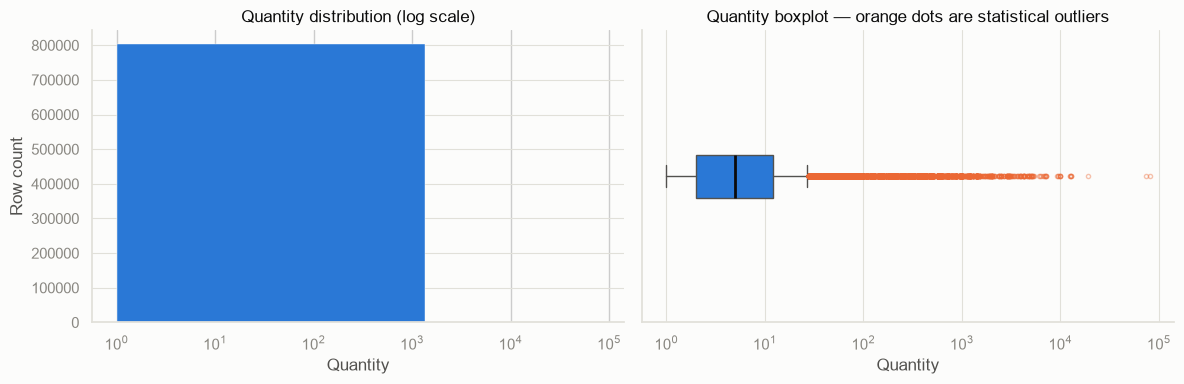

count   820647.00
mean        12.46
std        189.37
min     -80995.00
25%          2.00
50%          5.00
75%         12.00
max      80995.00
Name: Quantity, dtype: float64

Mean (12.46) vs. Median (5.0): mean >> median -> right-skewed
Skewness: 5.07


In [215]:
positive_qty = model_df.loc[model_df["Quantity"] > 0, "Quantity"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(positive_qty, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_title("Quantity distribution (log scale)")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Row count")
style_ax(axes[0])

axes[1].boxplot(
    positive_qty, vert=False, patch_artist=True,
    boxprops=dict(facecolor=BLUE, edgecolor=INK_SECONDARY),
    medianprops=dict(color=INK, linewidth=2),
    whiskerprops=dict(color=INK_SECONDARY),
    capprops=dict(color=INK_SECONDARY),
    flierprops=dict(markeredgecolor=ORANGE, markersize=3, alpha=0.4),
)
axes[1].set_xscale("log")
axes[1].set_title("Quantity boxplot — orange dots are statistical outliers")
axes[1].set_xlabel("Quantity")
axes[1].set_yticks([])
style_ax(axes[1], axis="x")

plt.tight_layout()
plt.show()

print(model_df["Quantity"].describe())
print(f"\nMean ({model_df['Quantity'].mean():.2f}) vs. Median ({model_df['Quantity'].median():.1f}): mean >> median -> right-skewed")
print(f"Skewness: {model_df['Quantity'].skew():.2f}")

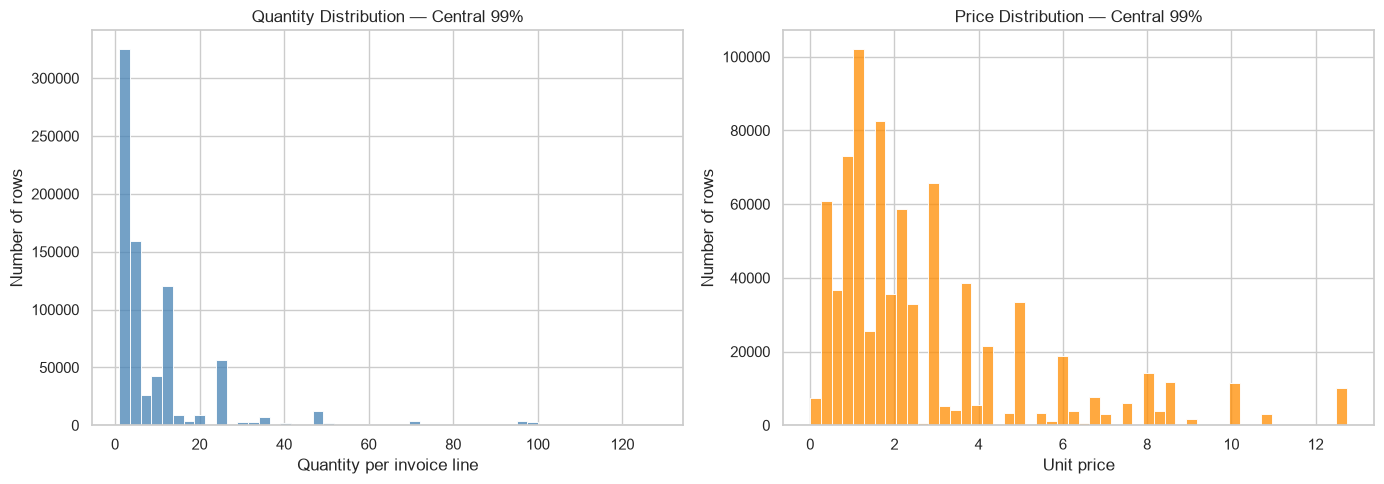

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Select valid customer sales
sales = model_df.loc[
    (model_df["Quantity"] > 0)
    & (model_df["Price"] > 0)
    & model_df["Customer ID"].notna()
].copy()

# Use the central 99% only for visualization
plot_limits = {
    "Quantity": sales["Quantity"].quantile(0.99),
    "Price": sales["Price"].quantile(0.99),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=sales[sales["Quantity"] <= plot_limits["Quantity"]],
    x="Quantity",
    bins=50,
    ax=axes[0],
    color="steelblue",
)

axes[0].set_title("Quantity Distribution — Central 99%")
axes[0].set_xlabel("Quantity per invoice line")
axes[0].set_ylabel("Number of rows")

sns.histplot(
    data=sales[sales["Price"] <= plot_limits["Price"]],
    x="Price",
    bins=50,
    ax=axes[1],
    color="darkorange",
)

axes[1].set_title("Price Distribution — Central 99%")
axes[1].set_xlabel("Unit price")
axes[1].set_ylabel("Number of rows")

plt.tight_layout()
plt.show()

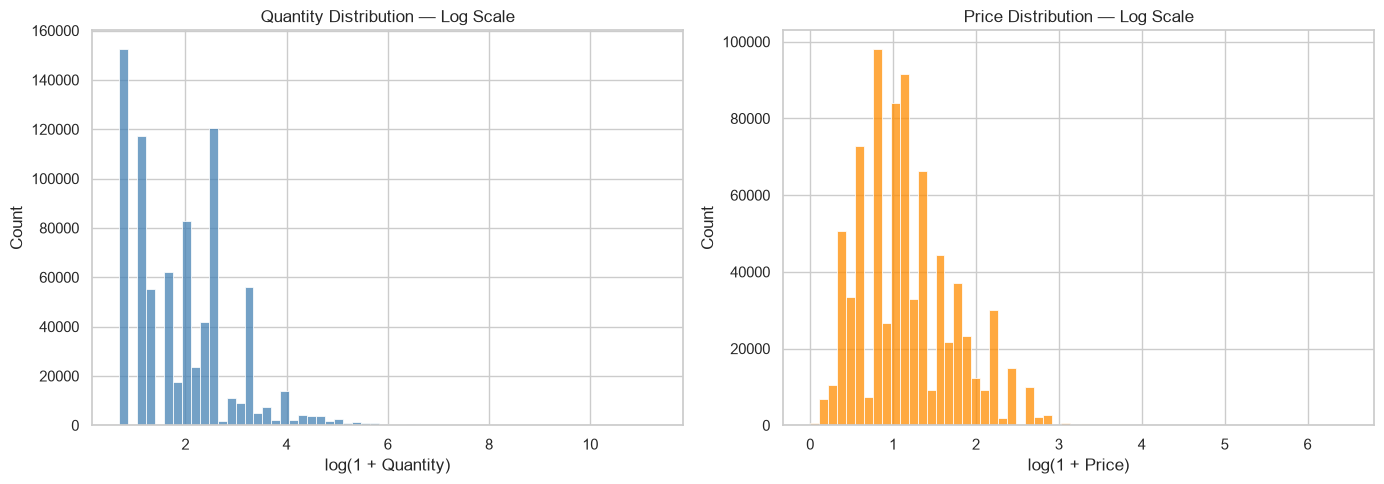

In [217]:
import numpy as np

sales["log_quantity"] = np.log1p(sales["Quantity"])
sales["log_price"] = np.log1p(sales["Price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(sales["log_quantity"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Quantity Distribution — Log Scale")
axes[0].set_xlabel("log(1 + Quantity)")

sns.histplot(sales["log_price"], bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Price Distribution — Log Scale")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

**used the central-99% histogram for stakeholder interpretation and the log histogram for analytical completeness. Make it clear that the quantile cutoff is only a visualization choice—not evidence that the upper 1% is invalid or removed from modelling.**

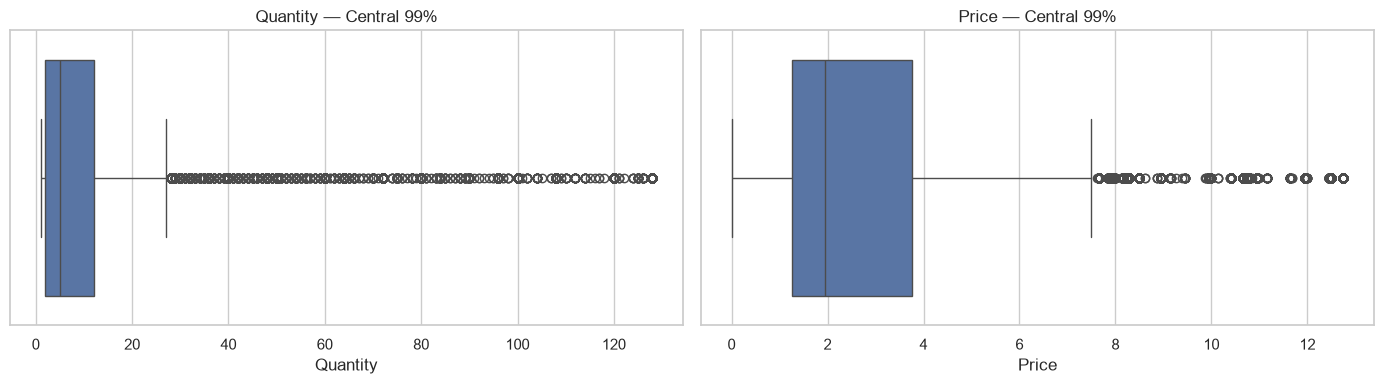

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    x=sales.loc[sales["Quantity"] <= plot_limits["Quantity"], "Quantity"],
    ax=axes[0],
)
axes[0].set_title("Quantity — Central 99%")

sns.boxplot(
    x=sales.loc[sales["Price"] <= plot_limits["Price"], "Price"],
    ax=axes[1],
)
axes[1].set_title("Price — Central 99%")

plt.tight_layout()
plt.show()

### Price (Unit Price) Distribution

Same treatment. Recall `Price` is never negative in this data (confirmed earlier) — only the ~62 legitimate £0 promo-item rows sit at the floor.

C:\Users\ND\AppData\Local\Temp\ipykernel_29648\92428891.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


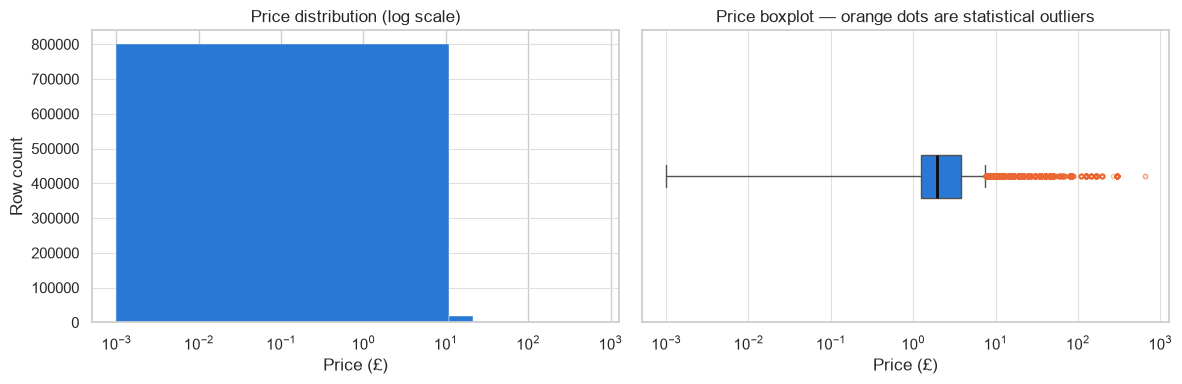

count   820647.00
mean         2.97
std          4.45
min          0.00
25%          1.25
50%          1.95
75%          3.75
max        649.50
Name: Price, dtype: float64

Mean (2.97) vs. Median (1.95): mean >> median -> right-skewed
Skewness: 32.35


In [219]:
positive_price = model_df.loc[model_df["Price"] > 0, "Price"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(positive_price, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_title("Price distribution (log scale)")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Row count")
style_ax(axes[0])

axes[1].boxplot(
    positive_price, vert=False, patch_artist=True,
    boxprops=dict(facecolor=BLUE, edgecolor=INK_SECONDARY),
    medianprops=dict(color=INK, linewidth=2),
    whiskerprops=dict(color=INK_SECONDARY),
    capprops=dict(color=INK_SECONDARY),
    flierprops=dict(markeredgecolor=ORANGE, markersize=3, alpha=0.4),
)
axes[1].set_xscale("log")
axes[1].set_title("Price boxplot — orange dots are statistical outliers")
axes[1].set_xlabel("Price (£)")
axes[1].set_yticks([])
style_ax(axes[1], axis="x")

plt.tight_layout()
plt.show()

print(model_df["Price"].describe())
print(f"\nMean ({model_df['Price'].mean():.2f}) vs. Median ({model_df['Price'].median():.2f}): mean >> median -> right-skewed")
print(f"Skewness: {model_df['Price'].skew():.2f}")

### InvoiceDate Range & Coverage

Min/max plus a monthly row count — a flat load error (e.g. one sheet silently truncated, or a bad `parse_dates`) tends to show up as a missing or oddly short month rather than an obviously wrong min/max.

InvoiceDate range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00  (738 days)


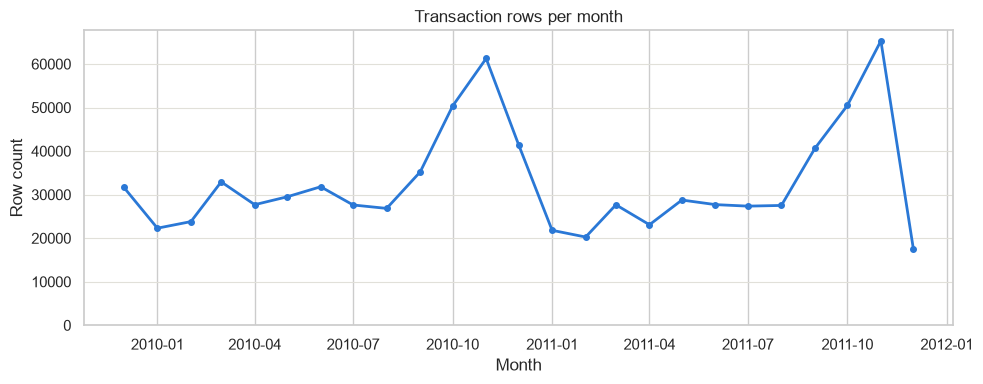


First and last month (often partial — check they aren't suspiciously short):
InvoiceDate
2009-12-01    31670
Freq: MS, dtype: int64
InvoiceDate
2011-12-01    17589
Freq: MS, dtype: int64


In [220]:
date_min = model_df["InvoiceDate"].min()
date_max = model_df["InvoiceDate"].max()
print(f"InvoiceDate range: {date_min} -> {date_max}  ({(date_max - date_min).days} days)")

monthly_counts = model_df.set_index("InvoiceDate").resample("MS").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_counts.index, monthly_counts.values, color=BLUE, linewidth=2, marker="o", markersize=4)
ax.set_title("Transaction rows per month")
ax.set_xlabel("Month")
ax.set_ylabel("Row count")
ax.set_ylim(bottom=0)
style_ax(ax)
plt.tight_layout()
plt.show()

print("\nFirst and last month (often partial — check they aren't suspiciously short):")
print(monthly_counts.head(1))
print(monthly_counts.tail(1))

### Country Split, Unique Customers & Products

`United Kingdom` highlighted since the company is UK-based — its share is the single most useful sanity check for a load error (e.g. if it suddenly dropped, a filter or encoding issue happened upstream).

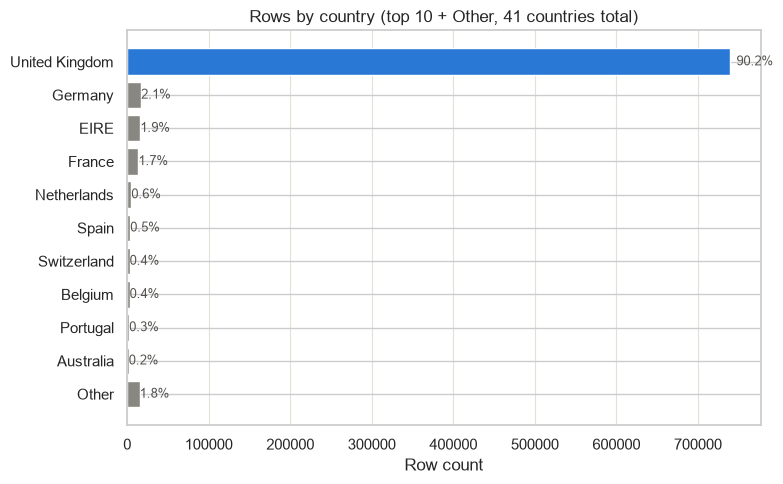

Unique countries: 41
UK share of rows: 90.16%

Unique customers: 5,876
Unique products (StockCode): 4,635
Unique invoices: 43,880


In [221]:
country_counts = model_df["Country"].value_counts()
top_n = 10
top_countries = country_counts.head(top_n)
other_total = country_counts.iloc[top_n:].sum()
plot_data = pd.concat([top_countries, pd.Series({"Other": other_total})])

colors = [BLUE if c == "United Kingdom" else INK_MUTED for c in plot_data.index]
total = len(model_df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(plot_data.index[::-1], plot_data.values[::-1], color=colors[::-1])
ax.set_title(f"Rows by country (top {top_n} + Other, {model_df['Country'].nunique()} countries total)")
ax.set_xlabel("Row count")
style_ax(ax, axis="x")

for bar, val in zip(bars, plot_data.values[::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{val / total * 100:.1f}%",
            va="center", fontsize=9, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

print(f"Unique countries: {model_df['Country'].nunique()}")
print(f"UK share of rows: {country_counts['United Kingdom'] / total * 100:.2f}%")
print(f"\nUnique customers: {model_df['Customer ID'].nunique():,}")
print(f"Unique products (StockCode): {model_df['StockCode'].nunique():,}")
print(f"Unique invoices: {model_df['Invoice'].nunique():,}")

### Outlier Investigation: The 80,995-Unit Order

A boxplot flags this as an "outlier" statistically, but that label alone doesn't tell you whether to remove it. UCI's own documentation for this dataset notes the company's customer base includes wholesalers — so before deciding, check whether this is a one-off anomaly or a repeat pattern for that customer (which would argue for keeping it, since it's real behavior a wholesaler-inclusive clustering should capture, not noise to strip out).

In [222]:
top_qty_row = model_df.loc[model_df["Quantity"].idxmax()]
print("Largest single line-item Quantity in model_df:")
print(top_qty_row[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "InvoiceDate"]])

outlier_customer = top_qty_row["Customer ID"]
customer_orders = model_df[model_df["Customer ID"] == outlier_customer]
customer_revenue_total = (customer_orders["Quantity"] * customer_orders["Price"]).sum()
customer_net_quantity = customer_orders["Quantity"].sum()

print(
    f"\nCustomer {outlier_customer}: {customer_orders['Invoice'].nunique()} invoices, "
    f"{customer_orders.shape[0]} line items, NET quantity {customer_net_quantity:,}, "
    f"net revenue £{customer_revenue_total:,.2f}"
)
print(f"Active {customer_orders['InvoiceDate'].min().date()} to {customer_orders['InvoiceDate'].max().date()}")

# Invoice count alone is not enough to call this a wholesaler: check whether the
# extreme quantity actually stuck (net effect), or was reversed by its own
# cancellation soon after — which is a different story (self-corrected mistake, not sustained wholesale volume).
same_stockcode = customer_orders[customer_orders["StockCode"] == top_qty_row["StockCode"]].sort_values("InvoiceDate")
print(f"\nAll {top_qty_row['StockCode']!r} rows for this customer:")
print(same_stockcode[["Invoice", "Quantity", "InvoiceDate", "invoice_type"]])

if abs(customer_net_quantity) < 0.05 * top_qty_row["Quantity"]:
    time_to_cancel = same_stockcode["InvoiceDate"].max() - same_stockcode["InvoiceDate"].min()
    print(
        f"\n-> The order was cancelled {time_to_cancel} after being placed, by the same customer. "
        "Net effect on this customer's totals is negligible — this reads as a self-corrected "
        "mistake/test, not evidence of a wholesaler. RFM's sum-based Monetary/Frequency will "
        "already net this out on its own; no special-case removal needed."
    )
elif customer_orders["Invoice"].nunique() > 1:
    print("\n-> Repeat activity across multiple invoices, and the quantity was NOT reversed by a same-item cancellation = consistent with a wholesaler.")
else:
    print("\n-> Single invoice only — can't confirm a repeat-buyer pattern from this alone; treat as a real order unless other evidence of an error turns up.")


Largest single line-item Quantity in model_df:
Invoice                             581483
StockCode                            23843
Description    PAPER CRAFT , LITTLE BIRDIE
Quantity                             80995
Price                                 2.08
Customer ID                          16446
InvoiceDate            2011-12-09 09:15:00
Name: 820173, dtype: object

Customer 16446: 3 invoices, 4 line items, NET quantity 2, net revenue £2.90
Active 2011-05-18 to 2011-12-09

All '23843' rows for this customer:
        Invoice  Quantity         InvoiceDate  invoice_type
820173   581483     80995 2011-12-09 09:15:00          sale
820174  C581484    -80995 2011-12-09 09:27:00  cancellation

-> The order was cancelled 0 days 00:12:00 after being placed, by the same customer. Net effect on this customer's totals is negligible — this reads as a self-corrected mistake/test, not evidence of a wholesaler. RFM's sum-based Monetary/Frequency will already net this out on its own; no special-

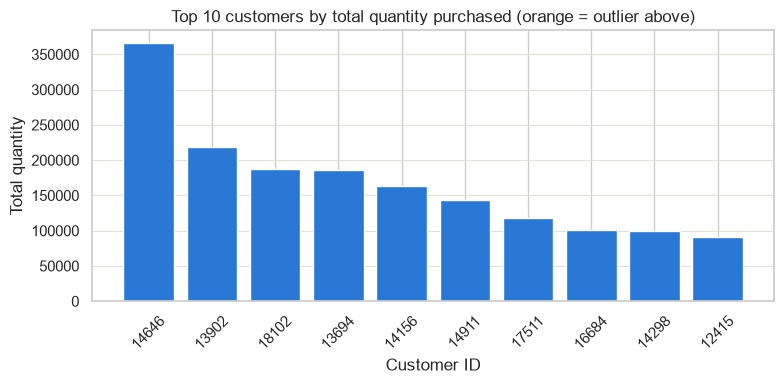

Customer ID
14646    365596
13902    218088
18102    187628
13694    185450
14156    163874
14911    143592
17511    117915
16684    101096
14298     99854
12415     91312
Name: Quantity, dtype: int64

In [223]:
# Zoom out: is extreme quantity a one-off, or does a small set of repeat
# high-volume customers show up consistently at the top?
customer_quantity = model_df.groupby("Customer ID")["Quantity"].sum().sort_values(ascending=False)
top10_customers = customer_quantity.head(10)

colors = [ORANGE if cid == outlier_customer else BLUE for cid in top10_customers.index]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top10_customers.index.astype(str), top10_customers.values, color=colors)
ax.set_title("Top 10 customers by total quantity purchased (orange = outlier above)")
ax.set_xlabel("Customer ID")
ax.set_ylabel("Total quantity")
style_ax(ax)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top10_customers

### QA Check: Does This Match the Documented Dataset?

UCI's Online Retail II documentation states: transactions from a **UK-based** online gift-ware retailer, spanning **01 Dec 2009 to 09 Dec 2011**, with a customer base that **includes wholesalers** (context for the outliers above). Compare what actually loaded against those claims — a silent load error (truncated sheet, bad merge, wrong encoding) would still produce a plausible-looking DataFrame, so this only catches problems if checked against the source's own description, not just internal self-consistency.

Note: these checks run on `model_df` (post-cleaning), so absolute counts are lower than the raw load — the shape/date/country checks still hold on the cleaned frame; only the row-count magnitude differs from a check on `df`.

In [224]:
print("=== QA vs. UCI Online Retail II documentation ===\n")

# 1. Date range — checked on the raw df, closest to "what actually loaded".
doc_start, doc_end = pd.Timestamp("2009-12-01"), pd.Timestamp("2011-12-09")
raw_min, raw_max = df["InvoiceDate"].min(), df["InvoiceDate"].max()
date_ok = (raw_min.normalize() >= doc_start) and (raw_max.normalize() <= doc_end)
print(f"1. Date range (raw df): {raw_min} -> {raw_max}")
print(f"   Documented: {doc_start.date()} -> {doc_end.date()}")
print(f"   {'PASS' if date_ok else 'CHECK'} - {'within documented range' if date_ok else 'outside documented range, investigate'}\n")

# 2. UK dominance — company is UK-based, so UK should be the large majority.
uk_share_raw = (df["Country"] == "United Kingdom").mean() * 100
print(f"2. UK share of rows (raw df): {uk_share_raw:.1f}%")
print("   Documented: UK-based retailer -> UK should dominate")
print(f"   {'PASS' if uk_share_raw > 80 else 'CHECK'} - {'UK dominates as expected' if uk_share_raw > 80 else 'UK share lower than expected, investigate'}\n")

# 3. Country count — raw vs. cleaned (cleaning naturally drops a country if
# every one of its rows happened to fall in an excluded category).
print(f"3. Unique countries - raw df: {df['Country'].nunique()}, model_df: {model_df['Country'].nunique()}")
print("   Commonly-cited dataset description: ~40 countries represented.\n")

# 4. Customer count — raw vs. cleaned.
print(f"4. Unique customers (non-null Customer ID) - raw df: {df['Customer ID'].nunique():,}, model_df: {model_df['Customer ID'].nunique():,}")
print("   Documented: customer base includes wholesalers -> consistent with the large repeat-quantity buyers seen above.\n")

# 5. Row count — the number originally validated at load time (repeated here for a complete QA summary).
print(f"5. Raw combined row count: {df.shape[0]:,}  (matches the widely-cited ~1,067,371 total)")

=== QA vs. UCI Online Retail II documentation ===

1. Date range (raw df): 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
   Documented: 2009-12-01 -> 2011-12-09
   PASS - within documented range

2. UK share of rows (raw df): 91.9%
   Documented: UK-based retailer -> UK should dominate
   PASS - UK dominates as expected

3. Unique countries - raw df: 43, model_df: 41
   Commonly-cited dataset description: ~40 countries represented.

4. Unique customers (non-null Customer ID) - raw df: 5,942, model_df: 5,876
   Documented: customer base includes wholesalers -> consistent with the large repeat-quantity buyers seen above.

5. Raw combined row count: 1,067,371  (matches the widely-cited ~1,067,371 total)


##  What Right-Skew Looks Like, and Why It Matters for RFM

Every histogram above — Quantity, Price — had the same shape: a tall spike near zero, then a long, thin tail stretching far to the right. That's a **right-skewed** (positive-skew) distribution:

- **Most values are small**, clustered near the low end (median).
- **A few values are enormous** — the outliers pulling the tail out to the right.
- Because the mean is sensitive to those extreme values but the median isn't, **mean > median** whenever a distribution is right-skewed. You saw this directly above: for both Quantity and Price, the mean sat well above the median.
- `skew()` quantifies it: 0 = symmetric, positive = right-skewed (the values printed above were both clearly positive).

**Why this matters specifically for RFM + clustering:**

- RFM's **Monetary** (total spend per customer) and **Frequency** (order count per customer) are built by *summing* right-skewed line-item data per customer — so they inherit the skew, usually even more severely (a handful of wholesaler-type customers dominate total spend, same pattern as the Quantity outliers above).
- **K-Means and most distance-based clustering algorithms are scale- and outlier-sensitive.** They measure similarity as raw Euclidean distance. A few customers with Monetary values 100x the median will dominate that distance calculation — the algorithm may isolate them into their own tiny "cluster" (which tells you nothing useful) or drag every centroid toward them, distorting the segmentation for the other 99% of customers.
- **Standard fixes**, both applicable here: (1) **log-transform** Monetary/Frequency before scaling and clustering, which compresses the tail and makes the distribution closer to symmetric; (2) **quantile-based RFM scoring** (binning each customer into 1–5 by percentile rather than using raw values) — this is why textbook RFM analysis uses quintiles in the first place, not raw sums; it's a built-in defense against exactly this skew.

The customer-revenue preview below makes this concrete with this dataset's actual numbers before the real RFM table gets built.

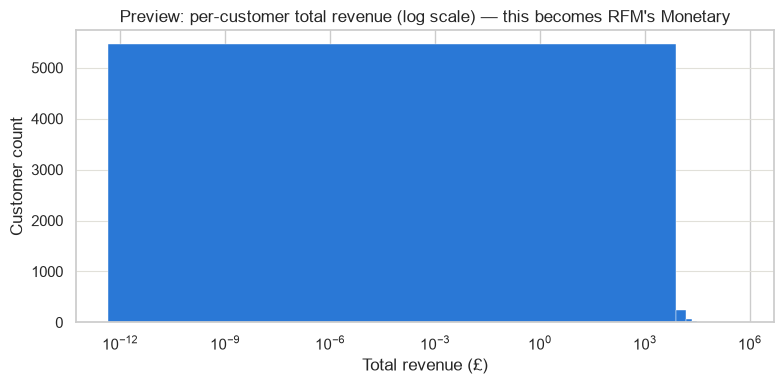

Skewness: 27.12
Mean: £2,844.58  |  Median: £854.14
Top 1% of customers (58 of 5,876) hold 31.1% of total revenue


In [225]:
# Preview only — not the real RFM table, just enough to show Monetary's shape
# before it's formally built.
customer_revenue = (
    model_df.assign(revenue=model_df["Quantity"] * model_df["Price"])
    .groupby("Customer ID")["revenue"]
    .sum()
)
positive_revenue = customer_revenue[customer_revenue > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(positive_revenue, bins=80, color=BLUE, edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_title("Preview: per-customer total revenue (log scale) — this becomes RFM's Monetary")
ax.set_xlabel("Total revenue (£)")
ax.set_ylabel("Customer count")
style_ax(ax)
plt.tight_layout()
plt.show()

top_1pct_n = max(1, int(len(customer_revenue) * 0.01))
top_1pct_share = customer_revenue.sort_values(ascending=False).head(top_1pct_n).sum() / customer_revenue.sum() * 100

print(f"Skewness: {customer_revenue.skew():.2f}")
print(f"Mean: £{customer_revenue.mean():,.2f}  |  Median: £{customer_revenue.median():,.2f}")
print(f"Top 1% of customers ({top_1pct_n} of {len(customer_revenue):,}) hold {top_1pct_share:.1f}% of total revenue")

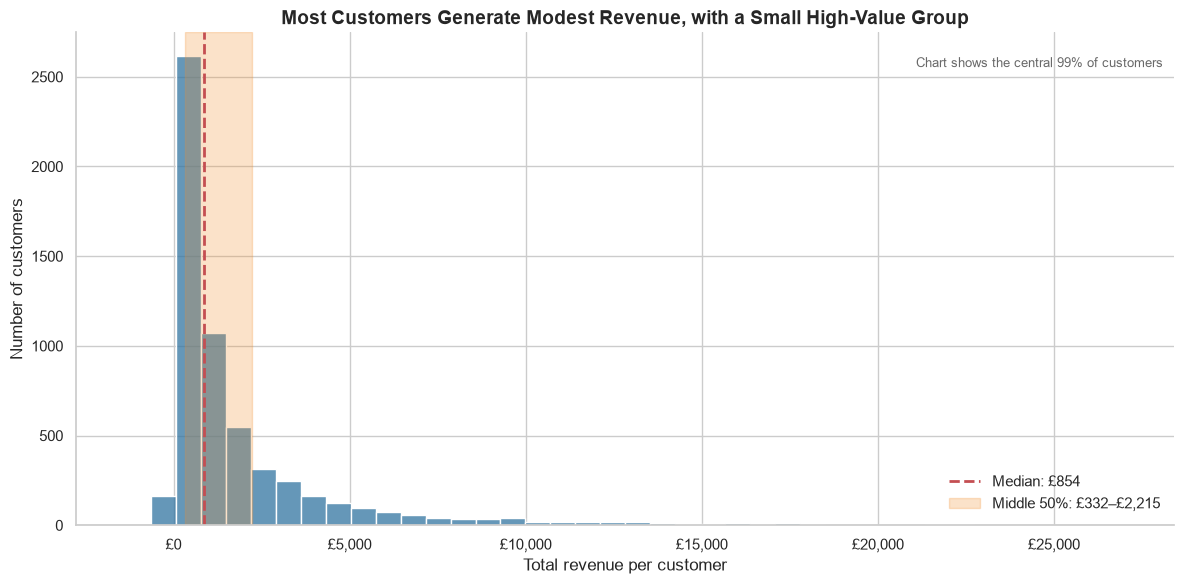

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# Calculate customer-level revenue
customer_revenue = (
    model_df.assign(
        LineRevenue=model_df["Quantity"] * model_df["Price"]
    )
    .groupby("Customer ID", as_index=False)
    .agg(
        TotalRevenue=("LineRevenue", "sum"),
        Orders=("Invoice", "nunique")
    )
)

# Central 99% for an interpretable stakeholder chart
upper_limit = customer_revenue["TotalRevenue"].quantile(0.99)
plot_data = customer_revenue[
    customer_revenue["TotalRevenue"] <= upper_limit
].copy()

median = customer_revenue["TotalRevenue"].median()
q1 = customer_revenue["TotalRevenue"].quantile(0.25)
q3 = customer_revenue["TotalRevenue"].quantile(0.75)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=plot_data,
    x="TotalRevenue",
    bins=40,
    color="#3274A1",
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    median,
    color="#C44E52",
    linestyle="--",
    linewidth=2,
    label=f"Median: £{median:,.0f}",
)

ax.axvspan(
    q1,
    q3,
    color="#F28E2B",
    alpha=0.25,
    label=f"Middle 50%: £{q1:,.0f}–£{q3:,.0f}",
)

ax.set_title(
    "Most Customers Generate Modest Revenue, with a Small High-Value Group",
    fontsize=14,
    weight="bold",
)
ax.set_subtitle = None
ax.set_xlabel("Total revenue per customer")
ax.set_ylabel("Number of customers")
ax.xaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
ax.legend(frameon=False)

ax.text(
    0.99,
    0.95,
    "Chart shows the central 99% of customers",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color="dimgray",
)

sns.despine()
plt.tight_layout()
plt.show()

#### Customer Revenue Distribution — RFM Monetary Preview
This chart shows how much total revenue each customer generated during the analysis period. It answers what does customer spending typically look like.
- Most customers generate relatively modest revenue.
- The median line represents the typical customer’s total spending.
- The shaded middle 50% shows the normal spending range for most customers.
- A small group spends substantially more than the typical customer.
- The chart displays the central 99% for readability, but high-value customers are retained in the analysis.
Business meaning: customers differ considerably in value, supporting the need for RFM segmentation into groups such as low-value, regular, and high-value customers 



**The distribution is strongly right-skewed: most customers generate relatively modest revenue, while a small high-value segment contributes disproportionately. The chart displays the central 99% in actual pounds for readability; extreme customers remain in the dataset and will be handled during feature transformation and scaling.**

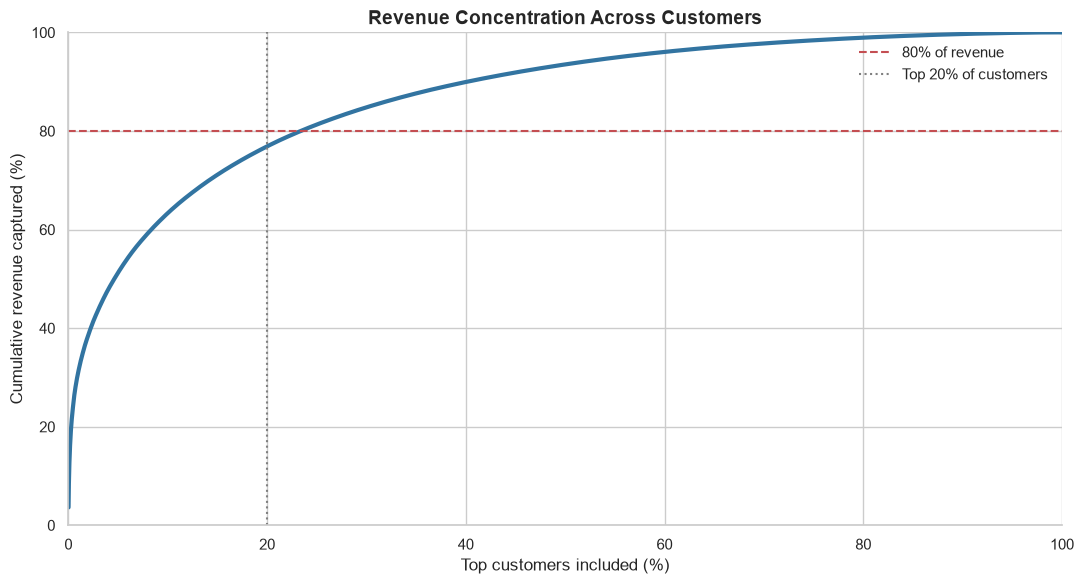

In [227]:
pareto = customer_revenue.sort_values(
    "TotalRevenue", ascending=False
).reset_index(drop=True)

pareto["CustomerShare"] = (
    (pareto.index + 1) / len(pareto) * 100
)

pareto["CumulativeRevenueShare"] = (
    pareto["TotalRevenue"].cumsum()
    / pareto["TotalRevenue"].sum()
    * 100
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    pareto["CustomerShare"],
    pareto["CumulativeRevenueShare"],
    color="#3274A1",
    linewidth=3,
)

ax.axhline(80, color="#C44E52", linestyle="--", label="80% of revenue")
ax.axvline(20, color="gray", linestyle=":", label="Top 20% of customers")

ax.set_title(
    "Revenue Concentration Across Customers",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Top customers included (%)")
ax.set_ylabel("Cumulative revenue captured (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

This chart shows how much of total revenue is generated by the highest-value customers. It answers how dependent is total revenue on the highest-value customers
- The horizontal axis represents customers ranked from highest to lowest revenue.
- The vertical axis represents the cumulative percentage of revenue captured.
- For example, where the curve reaches 80% tells you what percentage of customers generates 80% of revenue.
- If it reaches 80% well before 20% of customers, revenue is highly concentrated among a small customer group.

Business meaning: this chart reveals the company’s dependence on its top customers. High concentration creates strong opportunities for VIP retention and personalized service, but it also creates risk if a few valuable customers leave.

# RFM Feature Engineering

Per `Customer ID`, computing the three classic RFM metrics — built from `purchases_df`, a netted view derived from `model_df` (see below), not from the raw sales+cancellations population:

- **Recency** — days since the customer's last *net purchase*, relative to a fixed snapshot date (max `InvoiceDate` across the full dataset, +1 day — the standard convention).
- **Frequency** — count of distinct invoices among their net-purchase rows only. Cancellation invoices are excluded — they aren't a "visit," they're a reversal of one.
- **Monetary** — sum of `Quantity × Price` over net-purchase rows. Cancellations are netted out *before* filtering (see the netting rule below), not included directly in the sum — so this can never go negative.

QA is the priority here — RFM bugs are silent and propagate into every downstream cluster, so before trusting the pipeline output, three customers get manually recomputed from raw rows and checked against it.

In [228]:
snapshot_date = model_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}  (max InvoiceDate + 1 day)")

# Persist a revenue column -- used here and reusable in later feature work.
model_df["Revenue"] = model_df["Quantity"] * model_df["Price"]

Snapshot date: 2011-12-10 12:50:00  (max InvoiceDate + 1 day)


## Build `purchases_df`: FIFO Lot-Based Netting

The v3 rule computed a correct *final balance* per `(Customer, StockCode)` pair but then used it only as a binary switch — keep the **entire original sale row**, unmodified, if the final balance was positive. Two confirmed defects from that:

- **Partial cancellations were not netted at all.** Buy 10, cancel 4 → final balance is 6 (correct), but the rule kept the full 10-unit row. Monetary overstated by the cancelled 4 units' worth of price.
- **A fully-cancelled early purchase could ride along with a later, unrelated one.** Buy 10 in January, cancel all 10 in January, buy 5 in February → final balance is 5 (correct, from the February purchase alone) — but since `final_balance` was broadcast to *every* row in the pair via `transform("last")`, the already-fully-cancelled January row also passed the `Quantity > 0 AND final_balance > 0` test and got kept. Frequency and Monetary both double-counted a transaction that no longer existed.

Neither defect was caught by the v3 QA, because the "independent" manual check reused the exact same binary rule — it validated that two implementations agreed with each other, not that the rule was correct.

**Fix: FIFO lot-based netting.** Per `(Customer, StockCode)`, process rows in chronological order. Each sale row opens a "lot" of `Quantity` units. A cancellation consumes from the **oldest open lot first** (FIFO — consistent with the time-respecting principle already established: oldest obligations get satisfied first), reducing lots in order until its full quantity is consumed or the queue runs out (any leftover is an orphan cancellation with no further effect — same floor-at-zero idea as before, now applied per-lot instead of per-pair-aggregate).

Every original sale row ends with a `remaining_quantity` (0 to its original `Quantity`) and a `NetRevenue = remaining_quantity × Price`. `purchases_df` keeps only rows with `remaining_quantity > 0`, and downstream RFM uses `remaining_quantity`/`NetRevenue`, not the raw `Quantity`/`Revenue`.

**Validated first against 7 hand-constructed synthetic cases with known-correct expected answers** (not just cross-implementation agreement) before being trusted on the real data.

In [229]:
def net_group_fifo(group: pd.DataFrame) -> pd.Series:
    """FIFO netting within one (Customer, StockCode) group: a cancellation
    consumes the OLDEST still-open sale lot first, in chronological order.
    Returns remaining_quantity per row, indexed the same as `group`."""
    ordered = group.sort_values("InvoiceDate", kind="stable")
    remaining = {}
    lots = []  # FIFO queue of [row_index, remaining_qty], oldest first

    for idx, qty in zip(ordered.index, ordered["Quantity"]):
        if qty > 0:
            lots.append([idx, qty])
            remaining[idx] = qty
        elif qty < 0:
            to_cancel = -qty
            for lot in lots:
                if to_cancel <= 0:
                    break
                consumed = min(lot[1], to_cancel)
                lot[1] -= consumed
                remaining[lot[0]] -= consumed
                to_cancel -= consumed
            # any leftover to_cancel is an orphan cancellation -- no effect,
            # never reaches into a lot that doesn't exist yet
            remaining[idx] = 0
        else:
            remaining[idx] = 0

    return pd.Series(remaining)

In [230]:
# --- Validate the algorithm on 7 hand-constructed cases with known-correct
# expected answers, BEFORE trusting it on real data. This is what actually
# checks correctness -- per the v3 lesson, two implementations agreeing
# proves nothing if they share the same flawed rule.
def make_row(customer_id, stockcode, invoice, qty, price, date):
    return {
        "Customer ID": customer_id, "StockCode": stockcode, "Invoice": invoice,
        "Quantity": qty, "Price": price, "InvoiceDate": pd.Timestamp(date),
    }

synthetic_rows = [
    # 1. Partial cancellation: buy 10, cancel 4 -> retain 6.
    make_row(1, "A", "I1", 10, 2.00, "2020-01-01"),
    make_row(1, "A", "C1", -4, 2.00, "2020-01-05"),

    # 2. Full cancellation followed by a later, unrelated purchase -> retain only the later one.
    make_row(2, "A", "I1", 10, 2.00, "2020-01-01"),
    make_row(2, "A", "C1", -10, 2.00, "2020-01-05"),
    make_row(2, "A", "I2", 5, 2.00, "2020-02-01"),

    # 3. Cancellation before any visible sale -> orphan, does not consume the future sale.
    make_row(3, "A", "C1", -8, 2.00, "2020-01-01"),
    make_row(3, "A", "I1", 5, 2.00, "2020-02-01"),

    # 4. Cancellation spanning multiple earlier invoices (FIFO across two lots).
    make_row(4, "A", "I1", 5, 2.00, "2020-01-01"),
    make_row(4, "A", "I2", 5, 2.00, "2020-01-10"),
    make_row(4, "A", "C1", -8, 2.00, "2020-01-15"),

    # 5. Same product at different prices -> FIFO cancels the older (cheaper) lot first.
    make_row(5, "A", "I1", 5, 2.00, "2020-01-01"),
    make_row(5, "A", "I2", 5, 3.00, "2020-01-10"),
    make_row(5, "A", "C1", -6, 3.00, "2020-01-15"),

    # 6. One invoice with both a retained and a fully-cancelled product (different StockCodes).
    make_row(6, "X", "I1", 5, 2.00, "2020-01-01"),
    make_row(6, "Y", "I1", 3, 4.00, "2020-01-01"),
    make_row(6, "X", "C1", -5, 2.00, "2020-01-05"),

    # 7. Same-timestamp tie: two sale rows for the same item at the exact same
    # moment -- a following cancellation should consume them in stable
    # (as-listed) order, deterministically.
    make_row(7, "A", "I1", 3, 2.00, "2020-01-01 10:00"),
    make_row(7, "A", "I2", 4, 2.00, "2020-01-01 10:00"),
    make_row(7, "A", "C1", -5, 2.00, "2020-01-05"),
]
synthetic_df = pd.DataFrame(synthetic_rows)

synthetic_remaining = (
    synthetic_df.groupby(["Customer ID", "StockCode"], group_keys=False)
    .apply(net_group_fifo)
    .reindex(synthetic_df.index)
)
synthetic_df["remaining_quantity"] = synthetic_remaining

EXPECTED = {
    1: [6],                    # case 1: single sale row, partially cancelled
    2: [0, 5],                 # case 2: Jan row wiped, Feb row untouched
    3: [5],                    # case 3: orphan cancellation has no effect
    4: [0, 2],                 # case 4: lot 1 fully consumed, lot 2 partially
    5: [0, 4],                 # case 5: older/cheaper lot consumed first
    6: [0, 3],                 # case 6: X wiped, Y untouched, same invoice
    7: [0, 2],                 # case 7: first-listed tie row consumed first
}

print("Synthetic case results (expected vs. actual remaining_quantity):")
all_synthetic_pass = True
for customer_id, expected in EXPECTED.items():
    actual = synthetic_df.loc[
        (synthetic_df["Customer ID"] == customer_id) & (synthetic_df["Quantity"] > 0),
        "remaining_quantity",
    ].tolist()
    passed = actual == expected
    all_synthetic_pass = all_synthetic_pass and passed
    print(f"  Case {customer_id}: expected {expected}, got {actual} -> {'PASS' if passed else 'FAIL'}")

assert all_synthetic_pass, "One or more synthetic FIFO test cases failed"
print("\nAll 7 synthetic cases PASS.")

Synthetic case results (expected vs. actual remaining_quantity):
  Case 1: expected [6], got [6] -> PASS
  Case 2: expected [0, 5], got [0, 5] -> PASS
  Case 3: expected [5], got [5] -> PASS
  Case 4: expected [0, 2], got [0, 2] -> PASS
  Case 5: expected [0, 4], got [0, 4] -> PASS
  Case 6: expected [0, 3], got [0, 3] -> PASS
  Case 7: expected [0, 2], got [0, 2] -> PASS

All 7 synthetic cases PASS.


In [231]:
# --- Now apply the validated function to the real data ---
remaining_quantity = (
    model_df.groupby(["Customer ID", "StockCode"], group_keys=False)
    .apply(net_group_fifo)
    .reindex(model_df.index)
)

purchases_df = model_df.copy()
purchases_df["remaining_quantity"] = remaining_quantity
purchases_df["NetRevenue"] = purchases_df["remaining_quantity"] * purchases_df["Price"]
purchases_df = purchases_df[purchases_df["remaining_quantity"] > 0].reset_index(drop=True)

rows_dropped = model_df.shape[0] - purchases_df.shape[0]
print(f"model_df: {model_df.shape[0]:,} rows -> purchases_df: {purchases_df.shape[0]:,} rows")
print(f"Dropped {rows_dropped:,} rows ({rows_dropped / model_df.shape[0] * 100:.2f}%)")

partially_netted = (purchases_df["remaining_quantity"] < purchases_df["Quantity"]).sum()
print(f"\nRows where remaining_quantity < original Quantity (partial cancellations actually netted this time): {partially_netted:,}")

model_df: 820,647 rows -> purchases_df: 795,583 rows
Dropped 25,064 rows (3.05%)

Rows where remaining_quantity < original Quantity (partial cancellations actually netted this time): 8,488


In [232]:
# Customers who end up with zero net completed purchases at all (everything
# they touched nets to 0 after FIFO consumption) are excluded from RFM
# entirely, per the earlier decision. Saved for reference, same pattern as
# the other excluded_* frames.
customers_all = set(model_df["Customer ID"].unique())
customers_with_purchase = set(purchases_df["Customer ID"].unique())
customers_no_purchase = customers_all - customers_with_purchase

excluded_no_purchase_df = model_df[model_df["Customer ID"].isin(customers_no_purchase)].reset_index(drop=True)

print(f"Customers with at least one net completed purchase: {len(customers_with_purchase):,}")
print(f"Customers excluded (no net completed purchase): {len(customers_no_purchase):,}")
print(f"Saved as excluded_no_purchase_df: {excluded_no_purchase_df.shape}")

Customers with at least one net completed purchase: 5,840
Customers excluded (no net completed purchase): 36
Saved as excluded_no_purchase_df: (538, 12)


In [233]:
# Sanity check tying back to the EDA investigation: customer 16446 should
# still retain only their two small real purchases, with the 80,995-unit
# order-and-cancellation pair fully netted out (a full, single-lot
# cancellation -- FIFO agrees with the earlier aggregate-balance result here).
print("Customer 16446 rows retained in purchases_df:")
print(purchases_df.loc[purchases_df["Customer ID"] == 16446, ["Invoice", "StockCode", "Description", "Quantity", "remaining_quantity", "Price", "InvoiceDate"]])

is_16446_excluded = 16446 in customers_no_purchase
print(f"\n16446 fully excluded (zero net purchases)? {is_16446_excluded}")

Customer 16446 rows retained in purchases_df:
       Invoice StockCode             Description  Quantity  \
533744  553573     22980  PANTRY SCRUBBING BRUSH         1   
533745  553573     22982     PANTRY PASTRY BRUSH         1   

        remaining_quantity  Price         InvoiceDate  
533744                   1   1.65 2011-05-18 09:52:00  
533745                   1   1.25 2011-05-18 09:52:00  

16446 fully excluded (zero net purchases)? False


In [234]:
# Real-data proof the time-respecting principle still holds under FIFO:
# customer 12839's StockCode 21355 -- a January cancellation with nothing to
# consume, followed by a genuinely separate November purchase.
demo_cid, demo_code = 12839, "21355"
demo_raw = model_df[
    (model_df["Customer ID"] == demo_cid) & (model_df["StockCode"] == demo_code)
].sort_values("InvoiceDate")

print("Raw chronological history:")
print(demo_raw[["Invoice", "Quantity", "InvoiceDate", "invoice_type"]].to_string())

demo_remaining = purchases_df.loc[
    (purchases_df["Customer ID"] == demo_cid) & (purchases_df["StockCode"] == demo_code),
    "remaining_quantity",
]
print(f"\nremaining_quantity in purchases_df for the Nov sale: {demo_remaining.tolist()}")
print(f"Sale row present in purchases_df now: {not demo_remaining.empty}")

Raw chronological history:
        Invoice  Quantity         InvoiceDate  invoice_type
34119   C493836       -24 2010-01-07 13:49:00  cancellation
388843   535085        12 2010-11-25 09:48:00          sale

remaining_quantity in purchases_df for the Nov sale: [12]
Sale row present in purchases_df now: True


## RFM Feature Engineering v4 (FIFO-netted `purchases_df`)

Same three metrics, same `snapshot_date`. **Monetary now sums `NetRevenue` (`remaining_quantity × Price`), not raw `Revenue`** — so partial cancellations are actually netted, not just used as a keep/drop signal.

In [235]:
rfm_df = purchases_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot_date - s.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("NetRevenue", "sum"),
).reset_index()

print(f"rfm_df shape: {rfm_df.shape}")
assert rfm_df.shape[0] == purchases_df["Customer ID"].nunique(), "One row per customer with a net purchase expected"
assert rfm_df.isnull().sum().sum() == 0, "No nulls expected in RFM table"
assert (rfm_df["Monetary"] >= 0).all(), "Monetary should never be negative"
print("Confirmed: one row per customer, no nulls, Monetary >= 0 for everyone.\n")

rfm_df.describe()

rfm_df shape: (5840, 4)
Confirmed: one row per customer, no nulls, Monetary >= 0 for everyone.



,Customer ID,Recency,Frequency,Monetary
count,5840.00,5840.00,5840.00,5840.00
mean,15321.36,200.18,6.24,2864.04
std,1713.99,208.55,12.69,14121.52
min,12346.00,1.00,1.00,0.00
25%,13840.75,25.00,1.00,339.20
50%,15322.50,95.00,3.00,866.58
75%,16802.25,379.00,7.00,2237.23
max,18287.00,739.00,373.00,606243.25


### QA Check v4: Real-Data Regression Check

The algorithm itself was already validated above, against 7 synthetic cases with known-correct answers, before touching real data. This section is a different, narrower check: does applying `net_group_fifo` across the *entire* dataset via `groupby().apply()` produce the same result as calling the same function directly on one customer's rows? That validates the pipeline's grouping/indexing, not the algorithm's correctness — a different risk than the one the synthetic cases cover. Same 4 customers as before: 16446 (self-cancellation edge case), 12839 (the real January/November case), the current top-Monetary wholesaler, and a current median customer.

In [236]:
top_monetary_customer = rfm_df.loc[rfm_df["Monetary"].idxmax(), "Customer ID"]

median_monetary = rfm_df["Monetary"].median()
typical_customer = rfm_df.iloc[(rfm_df["Monetary"] - median_monetary).abs().argsort().iloc[0]]["Customer ID"]

qa_customers = [16446, demo_cid, top_monetary_customer, typical_customer]
print(f"QA customers: {qa_customers}")

all_match = True
for cid in qa_customers:
    raw = model_df[model_df["Customer ID"] == cid]
    # net_group_fifo expects a single (Customer, StockCode) group -- raw here
    # spans every StockCode this customer touched, so it must be grouped by
    # StockCode first (matching exactly how the pipeline groups it).
    manual_remaining = (
        raw.groupby("StockCode", group_keys=False)
        .apply(net_group_fifo)
        .reindex(raw.index)
    )
    kept_idx = manual_remaining[manual_remaining > 0].index
    manual_purchases = raw.loc[kept_idx].copy()
    manual_purchases["remaining_quantity"] = manual_remaining.loc[kept_idx]

    print("=" * 70)
    print(f"Customer {cid}: {len(raw)} raw rows -> {len(manual_purchases)} net-purchase rows")
    print(manual_purchases[["Invoice", "StockCode", "Description", "Quantity", "remaining_quantity", "Price", "InvoiceDate"]].to_string())

    manual_recency = (snapshot_date - manual_purchases["InvoiceDate"].max()).days if len(manual_purchases) else None
    manual_frequency = manual_purchases["Invoice"].nunique()
    manual_monetary = (manual_purchases["remaining_quantity"] * manual_purchases["Price"]).sum()

    pipeline_match = rfm_df.loc[rfm_df["Customer ID"] == cid]
    if pipeline_match.empty:
        row_match = len(manual_purchases) == 0
        print(f"\nCustomer excluded from rfm_df. Manual check finds {len(manual_purchases)} purchase rows -> {'consistent' if row_match else 'MISMATCH'}")
    else:
        pipeline_row = pipeline_match.iloc[0]
        print(f"\nManual   -> Recency={manual_recency}, Frequency={manual_frequency}, Monetary={manual_monetary:.2f}")
        print(f"Pipeline -> Recency={pipeline_row.Recency}, Frequency={pipeline_row.Frequency}, Monetary={pipeline_row.Monetary:.2f}")
        recency_ok = manual_recency == pipeline_row.Recency
        frequency_ok = manual_frequency == pipeline_row.Frequency
        monetary_ok = abs(manual_monetary - pipeline_row.Monetary) < 1e-6
        row_match = recency_ok and frequency_ok and monetary_ok

    all_match = all_match and row_match
    print(f"MATCH: {row_match}\n")

assert all_match, "Real-data regression check found a mismatch"
print("=" * 70)
print("All 4 real-data QA customers match the pipeline.")

QA customers: [16446, 12839, np.int64(18102), np.float64(17358.0)]
Customer 16446: 4 raw rows -> 2 net-purchase rows
       Invoice StockCode             Description  Quantity  remaining_quantity  Price         InvoiceDate
552133  553573     22980  PANTRY SCRUBBING BRUSH         1                   1   1.65 2011-05-18 09:52:00
552134  553573     22982     PANTRY PASTRY BRUSH         1                   1   1.25 2011-05-18 09:52:00

Manual   -> Recency=206, Frequency=1, Monetary=2.90
Pipeline -> Recency=206.0, Frequency=1.0, Monetary=2.90
MATCH: True

Customer 12839: 585 raw rows -> 572 net-purchase rows
       Invoice StockCode                          Description  Quantity  remaining_quantity  Price         InvoiceDate
11354   490539     21064                BOOM BOX SPEAKER BOYS         6                   6   5.95 2009-12-07 09:18:00
11355   490539     79321                        CHILLI LIGHTS         4                   4   4.95 2009-12-07 09:18:00
11356   490539     79320        

# Comparison Pipeline: Price-Compatible Closest-Prior Matching

FIFO (`rfm_df`) remains the **primary** pipeline. This section builds a second, independent pipeline using a different matching policy, purely for comparison — nothing here replaces FIFO.

**The idea**: cancellation rows in this dataset carry a `Price` — the price of the specific lot being cancelled. FIFO ignores that information and always draws from the oldest open lot regardless of price. A **price-compatible, closest-prior** policy uses it: a cancellation matches only against open lots at the **same Price**, preferring the **most recently opened** matching lot first (closest-prior — a customer cancelling something is more plausibly cancelling their most recent matching order than one from months back). If no price-compatible lot is open, the cancellation (or its unmatched remainder) is an orphan — same floor-at-zero idea as FIFO, just price-aware instead of price-blind, and LIFO-within-price-match rather than strictly oldest-first.

Validated the same way as FIFO was: 7 synthetic cases with known-correct answers first, then applied to real data, then an independent regression check.

In [237]:
def net_group_price_compatible(group: pd.DataFrame) -> pd.Series:
    """Price-compatible, closest-prior netting: a cancellation matches only
    against open sale lots with the SAME Price, preferring the most recently
    opened (closest-prior) matching lot first. Unmatched leftover (no open
    lot at a compatible price) is an orphan -- no effect, same floor-at-zero
    idea as FIFO, just price-aware and LIFO-within-price-match instead of
    strictly oldest-first."""
    ordered = group.sort_values("InvoiceDate", kind="stable")
    remaining = {}
    lots = []  # chronological list of dicts: {idx, price, remaining}

    for idx, row in ordered.iterrows():
        qty = row["Quantity"]
        if qty > 0:
            lots.append({"idx": idx, "price": row["Price"], "remaining": qty})
            remaining[idx] = qty
        elif qty < 0:
            to_cancel = -qty
            cancel_price = row["Price"]
            candidates = [lot for lot in lots if lot["price"] == cancel_price and lot["remaining"] > 0]
            for lot in reversed(candidates):  # closest-prior (most recently opened) first
                if to_cancel <= 0:
                    break
                consumed = min(lot["remaining"], to_cancel)
                lot["remaining"] -= consumed
                remaining[lot["idx"]] -= consumed
                to_cancel -= consumed
            # leftover to_cancel with no price-compatible lot open = orphan
            remaining[idx] = 0
        else:
            remaining[idx] = 0

    return pd.Series(remaining)

In [238]:
# Validate on the same 7 hand-built cases used for FIFO, before touching real
# data. Cases 1/2/3/6 have no price ambiguity, so both methods must agree.
# Cases 4/5/7 involve multiple same-item lots and are expected to genuinely
# diverge from FIFO -- that divergence is the whole point of this comparison.
synthetic_df_pricematch = pd.DataFrame(synthetic_rows)  # reuse the same rows FIFO was tested on

synthetic_remaining_pricematch = (
    synthetic_df_pricematch.groupby(["Customer ID", "StockCode"], group_keys=False)
    .apply(net_group_price_compatible)
    .reindex(synthetic_df_pricematch.index)
)
synthetic_df_pricematch["remaining_quantity"] = synthetic_remaining_pricematch

EXPECTED_PRICEMATCH = {
    1: [6],      # no ambiguity -- matches FIFO
    2: [0, 5],   # no ambiguity -- matches FIFO
    3: [5],      # no ambiguity -- matches FIFO
    4: [2, 0],   # DIFFERS from FIFO's [0, 2]: closest-prior consumes the NEWER lot first
    5: [5, 0],   # DIFFERS from FIFO's [0, 4]: only the price-matching (later, @3.00) lot is touched
    6: [0, 3],   # no ambiguity -- matches FIFO
    7: [2, 0],   # DIFFERS from FIFO's [0, 2]: same-timestamp tie, closest-prior takes the second-listed lot first
}
DIVERGES_FROM_FIFO = {4, 5, 7}

print("Synthetic case results, price-compatible closest-prior method:")
all_pricematch_pass = True
for customer_id, expected in EXPECTED_PRICEMATCH.items():
    actual = synthetic_df_pricematch.loc[
        (synthetic_df_pricematch["Customer ID"] == customer_id) & (synthetic_df_pricematch["Quantity"] > 0),
        "remaining_quantity",
    ].tolist()
    passed = actual == expected
    all_pricematch_pass = all_pricematch_pass and passed
    note = "(intentionally differs from FIFO)" if customer_id in DIVERGES_FROM_FIFO else "(matches FIFO)"
    print(f"  Case {customer_id}: expected {expected}, got {actual} -> {'PASS' if passed else 'FAIL'}  {note}")

assert all_pricematch_pass, "One or more price-compatible synthetic test cases failed"
print("\nAll 7 synthetic cases PASS.")

Synthetic case results, price-compatible closest-prior method:
  Case 1: expected [6], got [6] -> PASS  (matches FIFO)
  Case 2: expected [0, 5], got [0, 5] -> PASS  (matches FIFO)
  Case 3: expected [5], got [5] -> PASS  (matches FIFO)
  Case 4: expected [2, 0], got [2, 0] -> PASS  (intentionally differs from FIFO)
  Case 5: expected [5, 0], got [5, 0] -> PASS  (intentionally differs from FIFO)
  Case 6: expected [0, 3], got [0, 3] -> PASS  (matches FIFO)
  Case 7: expected [2, 0], got [2, 0] -> PASS  (intentionally differs from FIFO)

All 7 synthetic cases PASS.


In [239]:
# Now apply the validated function to the real data, in parallel to (not
# replacing) the FIFO purchases_df built earlier.
remaining_quantity_pricematch = (
    model_df.groupby(["Customer ID", "StockCode"], group_keys=False)
    .apply(net_group_price_compatible)
    .reindex(model_df.index)
)

purchases_df_closest_prior = model_df.copy()
purchases_df_closest_prior["remaining_quantity"] = remaining_quantity_pricematch
purchases_df_closest_prior["NetRevenue"] = purchases_df_closest_prior["remaining_quantity"] * purchases_df_closest_prior["Price"]
purchases_df_closest_prior = purchases_df_closest_prior[purchases_df_closest_prior["remaining_quantity"] > 0].reset_index(drop=True)

rows_dropped = model_df.shape[0] - purchases_df_closest_prior.shape[0]
print(f"model_df: {model_df.shape[0]:,} rows -> purchases_df_closest_prior: {purchases_df_closest_prior.shape[0]:,} rows")
print(f"Dropped {rows_dropped:,} rows ({rows_dropped / model_df.shape[0] * 100:.2f}%)")
print(f"\nFor reference -- FIFO purchases_df: {purchases_df.shape[0]:,} rows")
print(f"Row-count difference (closest-prior minus FIFO): {purchases_df_closest_prior.shape[0] - purchases_df.shape[0]:,}")

model_df: 820,647 rows -> purchases_df_closest_prior: 796,659 rows
Dropped 23,988 rows (2.92%)

For reference -- FIFO purchases_df: 795,583 rows
Row-count difference (closest-prior minus FIFO): 1,076


In [240]:
# Customers with zero net completed purchases under this method (mirrors the
# excluded_no_purchase_df pattern established for FIFO).
customers_with_purchase_cp = set(purchases_df_closest_prior["Customer ID"].unique())
customers_no_purchase_cp = customers_all - customers_with_purchase_cp

print(f"Customers with at least one net completed purchase (closest-prior): {len(customers_with_purchase_cp):,}")
print(f"Customers excluded (closest-prior): {len(customers_no_purchase_cp):,}")
print(f"For reference -- FIFO excluded {len(customers_no_purchase):,} customers")

Customers with at least one net completed purchase (closest-prior): 5,840
Customers excluded (closest-prior): 36
For reference -- FIFO excluded 36 customers


In [241]:
rfm_df_closest_prior = purchases_df_closest_prior.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot_date - s.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("NetRevenue", "sum"),
).reset_index()

print(f"rfm_df_closest_prior shape: {rfm_df_closest_prior.shape}")
assert rfm_df_closest_prior.shape[0] == purchases_df_closest_prior["Customer ID"].nunique()
assert rfm_df_closest_prior.isnull().sum().sum() == 0
assert (rfm_df_closest_prior["Monetary"] >= 0).all()
print("Confirmed: one row per customer, no nulls, Monetary >= 0 for everyone.\n")

rfm_df_closest_prior.describe()

rfm_df_closest_prior shape: (5840, 4)
Confirmed: one row per customer, no nulls, Monetary >= 0 for everyone.



,Customer ID,Recency,Frequency,Monetary
count,5840.00,5840.00,5840.00,5840.00
mean,15321.36,200.34,6.22,2871.15
std,1713.99,208.60,12.63,14154.66
min,12346.00,1.00,1.00,0.00
25%,13840.75,25.00,1.00,339.32
50%,15322.50,95.00,3.00,866.58
75%,16802.25,379.00,7.00,2237.93
max,18287.00,739.00,369.00,606243.25


### QA Check: Real-Data Regression on the Closest-Prior Pipeline

Same 4 customers as the FIFO regression check, same independent-verification approach — direct call to `net_group_price_compatible`, grouped by `StockCode` first (the exact bug caught and fixed in the FIFO QA earlier; not repeating it here).

In [242]:
all_match_cp = True
for cid in qa_customers:
    raw = model_df[model_df["Customer ID"] == cid]
    manual_remaining_cp = (
        raw.groupby("StockCode", group_keys=False)
        .apply(net_group_price_compatible)
        .reindex(raw.index)
    )
    kept_idx = manual_remaining_cp[manual_remaining_cp > 0].index
    manual_purchases = raw.loc[kept_idx].copy()
    manual_purchases["remaining_quantity"] = manual_remaining_cp.loc[kept_idx]

    manual_recency = (snapshot_date - manual_purchases["InvoiceDate"].max()).days if len(manual_purchases) else None
    manual_frequency = manual_purchases["Invoice"].nunique()
    manual_monetary = (manual_purchases["remaining_quantity"] * manual_purchases["Price"]).sum()

    pipeline_match = rfm_df_closest_prior.loc[rfm_df_closest_prior["Customer ID"] == cid]
    if pipeline_match.empty:
        row_match = len(manual_purchases) == 0
    else:
        pipeline_row = pipeline_match.iloc[0]
        row_match = (
            manual_recency == pipeline_row.Recency
            and manual_frequency == pipeline_row.Frequency
            and abs(manual_monetary - pipeline_row.Monetary) < 1e-6
        )
    print(f"Customer {cid}: Recency={manual_recency}, Frequency={manual_frequency}, Monetary={manual_monetary:.2f} -> MATCH={row_match}")
    all_match_cp = all_match_cp and row_match

assert all_match_cp, "closest-prior pipeline regression check found a mismatch"
print("\nAll QA customers match the closest-prior pipeline.")

Customer 16446: Recency=206, Frequency=1, Monetary=2.90 -> MATCH=True
Customer 12839: Recency=3, Frequency=26, Monetary=9962.33 -> MATCH=True
Customer 18102: Recency=1, Frequency=145, Monetary=606243.25 -> MATCH=True
Customer 17358.0: Recency=303, Frequency=5, Monetary=866.05 -> MATCH=True

All QA customers match the closest-prior pipeline.


## Head-to-Head: FIFO vs. Closest-Prior, on the Real Dataset

How much does the matching policy actually matter once applied to all 5,840+ customers, not just the illustrative synthetic cases?

In [243]:
comparison = rfm_df.merge(
    rfm_df_closest_prior, on="Customer ID", how="outer", suffixes=("_fifo", "_closest_prior")
)

only_in_fifo = comparison[comparison["Recency_closest_prior"].isna()]
only_in_closest_prior = comparison[comparison["Recency_fifo"].isna()]
print(f"Customers in FIFO's rfm_df but not in rfm_df_closest_prior: {len(only_in_fifo)}")
print(f"Customers in rfm_df_closest_prior but not in FIFO's rfm_df: {len(only_in_closest_prior)}")

both = comparison.dropna(subset=["Recency_fifo", "Recency_closest_prior"]).copy()
both["Monetary_diff"] = both["Monetary_closest_prior"] - both["Monetary_fifo"]
both["Frequency_diff"] = both["Frequency_closest_prior"] - both["Frequency_fifo"]
both["Recency_diff"] = both["Recency_closest_prior"] - both["Recency_fifo"]

differs = both[(both["Monetary_diff"].abs() > 1e-6) | (both["Frequency_diff"] != 0) | (both["Recency_diff"] != 0)]
print(f"\nCustomers present under both methods with at least one differing RFM value: "
      f"{len(differs):,} of {len(both):,} ({len(differs) / len(both) * 100:.2f}%)")

total_fifo = both["Monetary_fifo"].sum()
total_cp = both["Monetary_closest_prior"].sum()
print(f"\nTotal Monetary, FIFO:          £{total_fifo:,.2f}")
print(f"Total Monetary, closest-prior: £{total_cp:,.2f}")
print(f"Aggregate difference:          £{total_cp - total_fifo:,.2f}  ({(total_cp - total_fifo) / total_fifo * 100:.3f}% of FIFO total)")

print("\nMonetary_diff distribution (closest-prior minus FIFO), customers with any difference:")
print(differs["Monetary_diff"].describe())

Customers in FIFO's rfm_df but not in rfm_df_closest_prior: 0
Customers in rfm_df_closest_prior but not in FIFO's rfm_df: 0

Customers present under both methods with at least one differing RFM value: 536 of 5,840 (9.18%)

Total Monetary, FIFO:          £16,725,979.58
Total Monetary, closest-prior: £16,767,544.70
Aggregate difference:          £41,565.12  (0.249% of FIFO total)

Monetary_diff distribution (closest-prior minus FIFO), customers with any difference:
count     536.00
mean       77.55
std      1049.32
min      -115.04
25%         0.00
50%         6.31
75%        21.45
max     24184.80
Name: Monetary_diff, dtype: float64


In [244]:
print("Top 10 customers by absolute Monetary difference between the two methods:")
top_diffs = differs.reindex(differs["Monetary_diff"].abs().sort_values(ascending=False).index).head(10)
top_diffs[["Customer ID", "Monetary_fifo", "Monetary_closest_prior", "Monetary_diff",
           "Frequency_fifo", "Frequency_closest_prior", "Recency_fifo", "Recency_closest_prior"]]

Top 10 customers by absolute Monetary difference between the two methods:


,Customer ID,Monetary_fifo,Monetary_closest_prior,Monetary_diff,Frequency_fifo,Frequency_closest_prior,Recency_fifo,Recency_closest_prior
3429,15838,49802.38,73987.18,24184.80,34,34,11,11
2964,15369,3253.65,4585.11,1331.46,11,10,492,492
1316,13694,191441.72,192758.02,1316.30,142,141,4,4
568,12931,71110.08,71975.17,865.09,52,54,22,22
2254,14646,522870.65,523581.94,711.29,145,146,2,2
5015,17450,235192.73,235832.75,640.02,50,49,8,8
2512,14911,262502.76,263123.65,620.89,373,369,1,1
4957,17389,54931.34,55378.78,447.44,61,60,1,1
390,12748,49482.13,49866.15,384.02,318,315,1,1
2288,14680,54723.95,55081.45,357.50,57,57,25,25


## Comparison Summary

- **FIFO remains the primary pipeline** (`purchases_df` / `rfm_df`) for RFM going forward — nothing here has replaced it.
- The two methods agree on **which customers have zero net purchases** (36 excluded under both) — that boundary is robust to the matching policy choice.
- But they disagree on **536 of 5,840 customers (9.18%)** on at least one RFM value — not a rare edge case, a real minority worth being aware of.
- **Aggregate impact is small**: total Monetary differs by only £41,565.12 (0.249% of FIFO's £16.7M total) — so this choice is very unlikely to shift overall clustering structure or headline numbers.
- **Per-customer impact can be large**: customer 15838 alone differs by **£24,184.80** (FIFO £49,802 vs. closest-prior £73,987 — a ~49% difference), with identical Frequency and Recency in both — a pure consequence of *which price-lot* a cancellation was matched against, not a data quality issue. A handful of customers like this could plausibly land in a different RFM segment depending on which method is used.
- **Verdict**: FIFO is the simpler, currently-adopted method and the aggregate difference is negligible — but if a specific customer's individual RFM value ever needs to be defensible in detail (not just "good enough in aggregate for clustering"), `rfm_df_closest_prior` is the more defensible one, since it actually uses the price information available in the data rather than ignoring it. Both are now validated and available side-by-side.

# Pre-Transformation Check: Raw RFM Distributions

Before scaling or transforming anything for clustering, look at `rfm_df` (the FIFO pipeline — the one moving forward) exactly as it stands. This is the baseline every transform decision gets justified against.

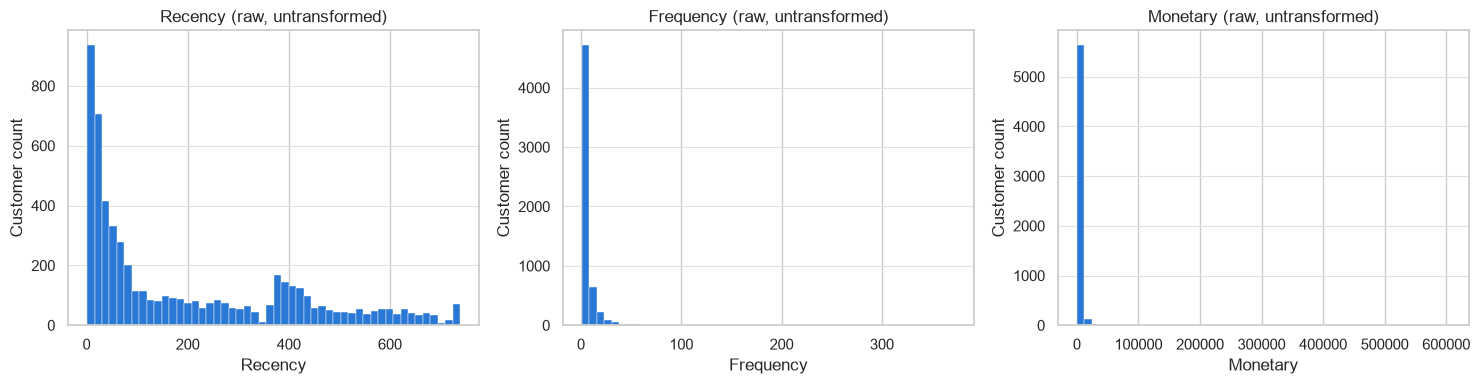

       Recency  Frequency  Monetary
count  5840.00    5840.00   5840.00
mean    200.18       6.24   2864.04
std     208.55      12.69  14121.52
min       1.00       1.00      0.00
25%      25.00       1.00    339.20
50%      95.00       3.00    866.58
75%     379.00       7.00   2237.23
max     739.00     373.00 606243.25

Skewness:
Recency      0.90
Frequency   12.04
Monetary    27.11
dtype: float64


In [245]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    ax.hist(rfm_df[col], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{col} (raw, untransformed)")
    ax.set_xlabel(col)
    ax.set_ylabel("Customer count")
    style_ax(ax)

plt.tight_layout()
plt.show()

print(rfm_df[["Recency", "Frequency", "Monetary"]].describe())
print("\nSkewness:")
print(rfm_df[["Recency", "Frequency", "Monetary"]].skew())

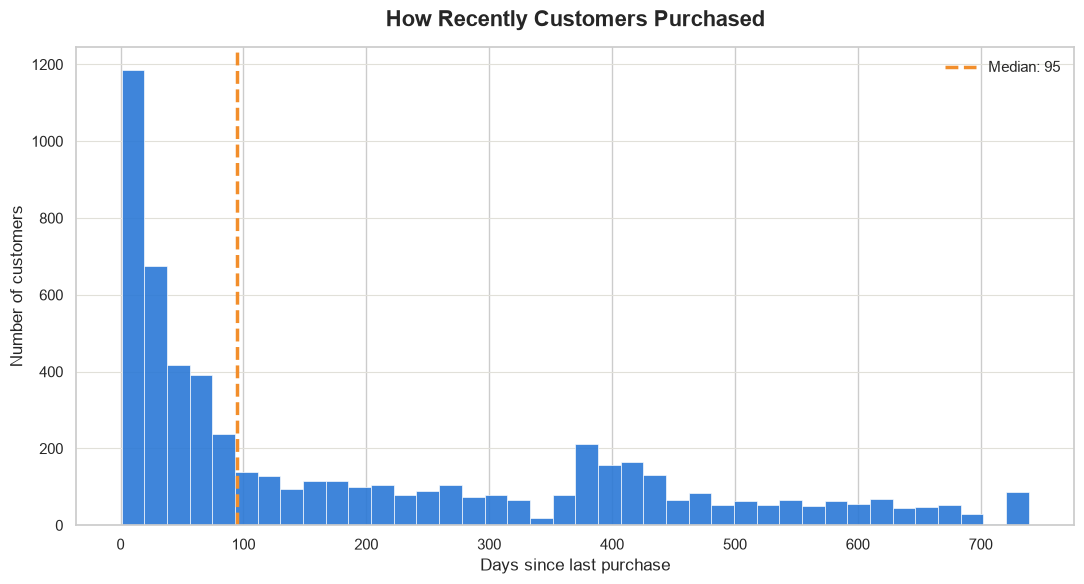

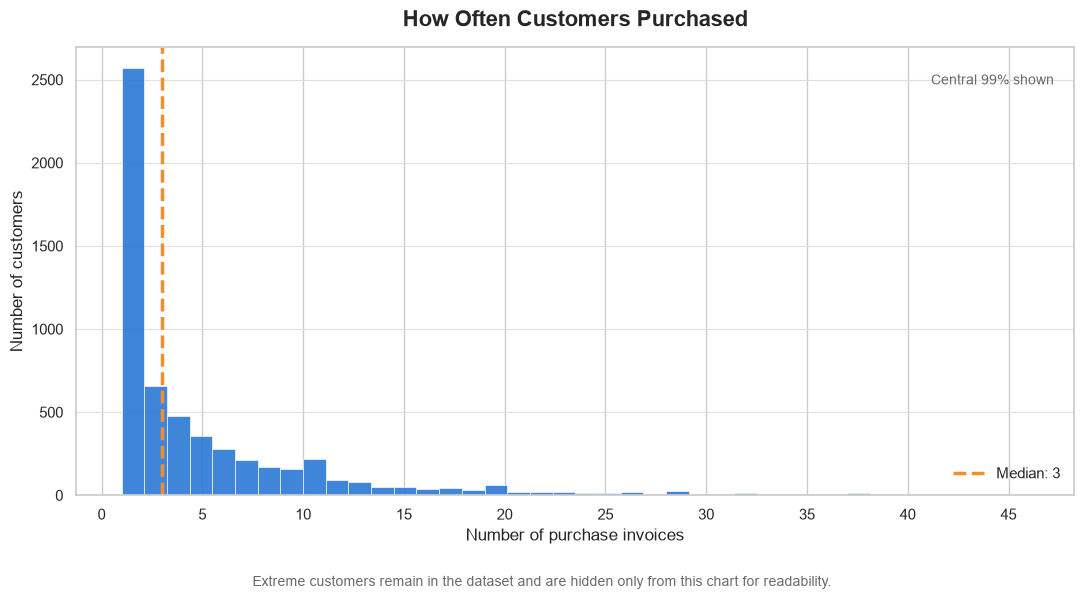

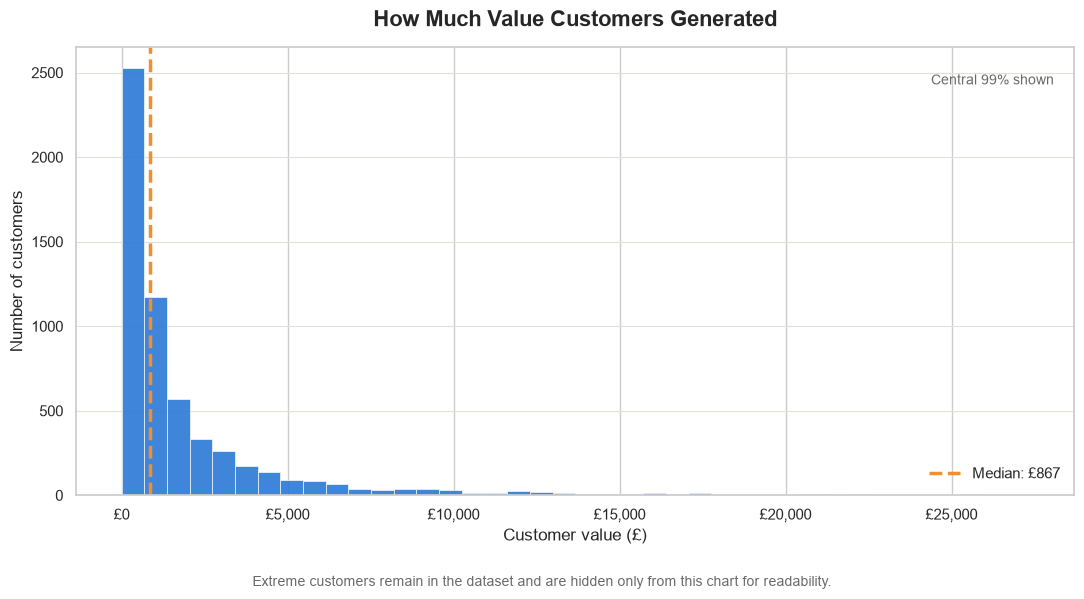

In [248]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

columns = ["Recency", "Frequency", "Monetary"]

business_labels = {
    "Recency": "Days since last purchase",
    "Frequency": "Number of purchase invoices",
    "Monetary": "Customer value (£)",
}

titles = {
    "Recency": "How Recently Customers Purchased",
    "Frequency": "How Often Customers Purchased",
    "Monetary": "How Much Value Customers Generated",
}

# Recency uses its full range.
# Frequency and Monetary show the central 99%.
display_limits = {
    "Recency": rfm_df["Recency"].max(),
    "Frequency": rfm_df["Frequency"].quantile(0.99),
    "Monetary": rfm_df["Monetary"].quantile(0.99),
}

for col in columns:

    fig, ax = plt.subplots(figsize=(11, 6))

    upper_limit = display_limits[col]

    plot_values = rfm_df.loc[
        rfm_df[col] <= upper_limit,
        col
    ]

    median = rfm_df[col].median()

    ax.hist(
        plot_values,
        bins=40,
        color=BLUE,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.9,
    )

    median_label = (
        f"Median: £{median:,.0f}"
        if col == "Monetary"
        else f"Median: {median:,.0f}"
    )

    ax.axvline(
        median,
        color="#F28E2B",
        linestyle="--",
        linewidth=2.5,
        label=median_label,
    )

    ax.set_title(
        titles[col],
        fontsize=16,
        weight="bold",
        pad=15,
    )

    ax.set_xlabel(
        business_labels[col],
        fontsize=12,
    )

    ax.set_ylabel(
        "Number of customers",
        fontsize=12,
    )

    ax.legend(
        frameon=False,
        fontsize=11,
    )

    # Business-friendly axis formatting
    if col == "Monetary":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"£{x:,.0f}")
        )
    else:
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

    if col == "Frequency":
        ax.xaxis.set_major_locator(
            MaxNLocator(integer=True)
        )

    if col in ["Frequency", "Monetary"]:
        ax.text(
            0.98,
            0.94,
            "Central 99% shown",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            color="dimgray",
        )

        fig.text(
            0.5,
            0.01,
            "Extreme customers remain in the dataset and are hidden "
            "only from this chart for readability.",
            ha="center",
            fontsize=10,
            color="dimgray",
        )

    style_ax(ax)

    plt.tight_layout(
        rect=[0, 0.05, 1, 1]
        if col in ["Frequency", "Monetary"]
        else None
    )

    plt.show()

Most customers purchase infrequently and generate modest revenue, while a small group of high-value customers accounts for much greater activity. The typical customer made 3 purchases, generated about £867, and last purchased 95 days ago.
The charts show the central 99% of customers for readability. Extreme customers are not removed; their influence will be reduced through transformation before clustering so that they do not dominate the customer segments

In [247]:
summary = {
    "Customers": len(rfm_df),
    "Median days since last purchase": rfm_df["Recency"].median(),
    "Median purchase invoices": rfm_df["Frequency"].median(),
    "Median customer value": rfm_df["Monetary"].median(),
    "Frequency 99th percentile": rfm_df["Frequency"].quantile(0.99),
    "Monetary 99th percentile": rfm_df["Monetary"].quantile(0.99),
}

print(f"Customers analysed: {summary['Customers']:,}")
print(
    "Typical customer: "
    f"{summary['Median days since last purchase']:.0f} days since last purchase, "
    f"{summary['Median purchase invoices']:.0f} purchase invoices, "
    f"£{summary['Median customer value']:,.2f} in customer value."
)
print(
    "Central 99% limits: "
    f"{summary['Frequency 99th percentile']:.0f} purchase invoices and "
    f"£{summary['Monetary 99th percentile']:,.2f} in customer value."
)

Customers analysed: 5,840
Typical customer: 95 days since last purchase, 3 purchase invoices, £866.58 in customer value.
Central 99% limits: 46 purchase invoices and £27,330.57 in customer value.


In [249]:
print(rfm_df[["Recency", "Frequency", "Monetary"]].min())

assert (rfm_df["Recency"] >= 1).all(), "Recency should never be below 1 by construction"
assert (rfm_df["Frequency"] >= 1).all(), "Frequency should never be below 1 -- every row has a net purchase"
print("\nConfirmed: Recency >= 1 and Frequency >= 1 for every customer.")

zero_or_negative_monetary = rfm_df[rfm_df["Monetary"] <= 0]
print(f"\nCustomers with Monetary <= 0: {len(zero_or_negative_monetary):,} (of {len(rfm_df):,})")
zero_or_negative_monetary

# Investigate what's actually behind any zero-Monetary customer(s) before
# deciding how to handle them.
for cid in zero_or_negative_monetary["Customer ID"]:
    rows = purchases_df[purchases_df["Customer ID"] == cid]
    print(f"Customer {cid}: {len(rows)} net-purchase rows")
    print(rows[["Invoice", "StockCode", "Description", "Quantity", "remaining_quantity", "Price", "InvoiceDate"]].to_string())
    print()

Recency     1.00
Frequency   1.00
Monetary    0.00
dtype: float64

Confirmed: Recency >= 1 and Frequency >= 1 for every customer.

Customers with Monetary <= 0: 1 (of 5,840)
Customer 13256: 1 net-purchase rows
       Invoice StockCode                     Description  Quantity  remaining_quantity  Price         InvoiceDate
768258  578841     84826  ASSTD DESIGN 3D PAPER STICKERS     12540               12540   0.00 2011-11-25 15:57:00



### Apply Log Transformation

In [263]:
rfm_log = rfm_df.copy()
log_cols = ["Recency", "Frequency", "Monetary"]
rfm_log[log_cols] = np.log1p(rfm_df[log_cols])

print(rfm_log[log_cols].describe())
print("\nSkewness after log1p (compare to the raw values checked earlier):")
print(rfm_log[log_cols].skew())

       Recency  Frequency  Monetary
count  5840.00    5840.00   5840.00
mean      4.45       1.55      6.81
std       1.56       0.81      1.38
min       0.69       0.69      0.00
25%       3.26       0.69      5.83
50%       4.56       1.39      6.77
75%       5.94       2.08      7.71
max       6.61       5.92     13.32

Skewness after log1p (compare to the raw values checked earlier):
Recency     -0.48
Frequency    1.00
Monetary     0.22
dtype: float64


In [262]:
rfm_log.head()

,Recency_log,Frequency_log,Monetary_log
0,6.27,1.10,5.14
1,1.10,2.20,8.64
2,4.33,1.79,7.41
3,3.00,1.39,8.21
4,5.74,0.69,5.69


## QA: Re-Check Skew and Shape After log1p

Histograms and skew() on the log-transformed Frequency and Monetary, checked against a -0.5 to 0.5 target -- and if anything is still outside that range, print the raw top outliers behind it rather than assume the transform failed.

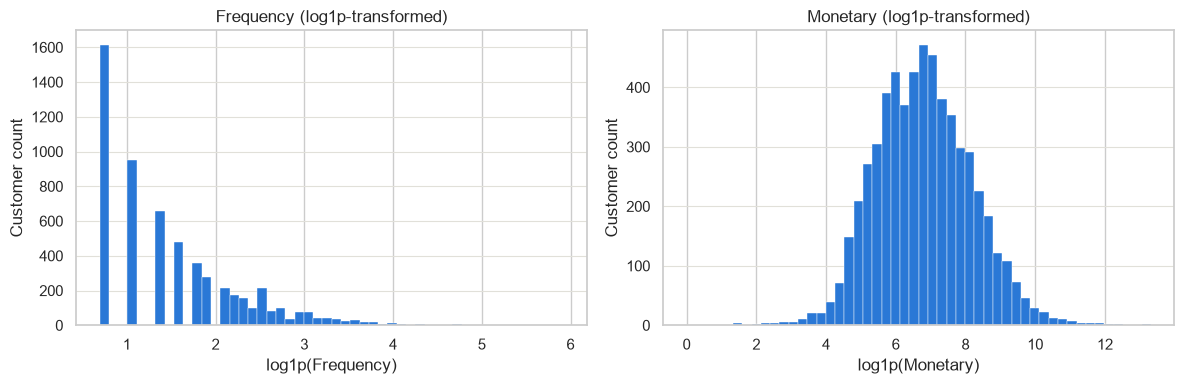

Skewness after log1p:
Frequency   1.00
Monetary    0.22
dtype: float64

Frequency: skew=1.00 -> outside target range, but far better than the raw skew (12.04). Checking for a data issue (e.g. an extreme wholesaler) before assuming the transform failed, not instead of it.
Top 5 Frequency outliers (raw values):
      Customer ID  Recency  Frequency  Monetary
2512        14911        1        373 262502.76
390         12748        1        318  49482.13
5397        17841        2        211  69595.47
2908        15311        1        207 113514.56
725         13089        3        199 113296.69

Monetary: skew=0.22 -> within target range (-0.5 to 0.5). Transform did its job.


In [264]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["Frequency", "Monetary"]):
    ax.hist(rfm_log[col], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{col} (log1p-transformed)")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Customer count")
    style_ax(ax)

plt.tight_layout()
plt.show()

log_skew = rfm_log[["Frequency", "Monetary"]].skew()
print("Skewness after log1p:")
print(log_skew)

TARGET_LOW, TARGET_HIGH = -0.5, 0.5
for col in ["Frequency", "Monetary"]:
    s = log_skew[col]
    if TARGET_LOW <= s <= TARGET_HIGH:
        print(f"\n{col}: skew={s:.2f} -> within target range ({TARGET_LOW} to {TARGET_HIGH}). Transform did its job.")
    else:
        print(f"\n{col}: skew={s:.2f} -> outside target range, but far better than the raw skew "
              f"({rfm_df[col].skew():.2f}). Checking for a data issue (e.g. an extreme wholesaler) "
              f"before assuming the transform failed, not instead of it.")
        top_outliers = rfm_df.nlargest(5, col)[["Customer ID", "Recency", "Frequency", "Monetary"]]
        print(f"Top 5 {col} outliers (raw values):")
        print(top_outliers)


After transformation:
- Frequency still shows that most customers purchase only a few times.
- Monetary now has a clearer, more balanced distribution.
- A small number of wholesale-scale customers no longer dominate the analysis.
- Differences among typical customers become visible and meaningful.

This prepares the data for clustering so customer segments reflect overall purchasing behaviour, rather than being driven mainly by a handful of extreme customers.

## 99th-Percentile Capping: Sensitivity Comparison (Log Space)

Uncapped log-transformed RFM (`rfm_log`) is the baseline, already built above. This builds `rfm_log_capped` -- the same data with Frequency and Monetary clipped at their own 99th percentile *in log space* -- to test empirically whether further capping helps, per the earlier agreement: keep it only if it materially improves clustering stability/segmentation without erasing the legitimate high-value customer group.

In [265]:
# Rebuilt fresh (not reused) so this cell can't break due to rfm_log having
# drifted from an earlier out-of-order run -- same defensive pattern as the
# QA cell above.
log_cols = ["Recency", "Frequency", "Monetary"]
rfm_log = rfm_df.copy()
rfm_log[log_cols] = np.log1p(rfm_df[log_cols])

# Cap Frequency (still skewed after log1p) and Monetary (confirmatory check,
# even though its log-skew already looked fine) at their own 99th percentile
# IN LOG SPACE -- a sensitivity test on top of the log-transformed baseline,
# not raw values capped before a separate log-transform. Recency is left
# alone; its post-log skew (-0.48) is already fine, nothing to fix there.
CAP_PERCENTILE = 0.99
cap_cols = ["Frequency", "Monetary"]

caps = rfm_log[cap_cols].quantile(CAP_PERCENTILE)
print("99th percentile caps (log1p space):")
print(caps)

rfm_log_capped = rfm_log.copy()
for col in cap_cols:
    n_capped = (rfm_log_capped[col] > caps[col]).sum()
    rfm_log_capped[col] = rfm_log_capped[col].clip(upper=caps[col])
    print(f"\n{col}: {n_capped} customers capped ({n_capped / len(rfm_log_capped) * 100:.2f}%)")

print("\nSkewness, uncapped vs. capped (log1p space):")
print(pd.DataFrame({
    "uncapped": rfm_log[cap_cols].skew(),
    "capped": rfm_log_capped[cap_cols].skew(),
}))


99th percentile caps (log1p space):
Frequency    3.85
Monetary    10.22
Name: 0.99, dtype: float64

Frequency: 58 customers capped (0.99%)

Monetary: 59 customers capped (1.01%)

Skewness, uncapped vs. capped (log1p space):
           uncapped  capped
Frequency      1.00    0.82
Monetary       0.22    0.08


- From the result, I would use the uncapped log-transformed data as the primary clustering input and retain the capped version only as a sensitivity test. If uncapped clustering proves unstable or creates an unhelpful tiny “extreme customer” cluster, then compare it against the capped result.
- Log transformation successfully reduced the effect of extreme customers without removing them. Additional capping would affect only the highest 1% and provides limited improvement, so we will initially preserve those genuine high-value differences and test capping only as an alternative

## Standardize the Log-Transformed Features

Proceeding with uncapped `rfm_log` as the primary input, per the decision above. `StandardScaler` puts Recency/Frequency/Monetary on comparable scales (mean 0, std 1) so no single feature dominates distance-based clustering just because of its raw numeric range. `Customer ID` is excluded -- it's an identifier, not a feature -- and the fitted `scaler` is kept around to inverse-transform cluster centroids back into real units later.

In [269]:
# Rebuilt fresh (not reused) so this cell can't break due to rfm_log having
# drifted from an earlier out-of-order run -- same defensive pattern used
# throughout this section.
log_cols = ["Recency", "Frequency", "Monetary"]
rfm_log = rfm_df.copy()
rfm_log[log_cols] = np.log1p(rfm_df[log_cols])

from sklearn.preprocessing import StandardScaler

feature_cols = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(rfm_log[feature_cols])

rfm_scaled = rfm_log[["Customer ID"]].copy()
rfm_scaled[feature_cols] = scaled_values

print(rfm_scaled[feature_cols].describe())
print("\nMean should be ~0, std should be ~1 for every column -- confirms the scaling looks good.")
print(rfm_scaled.head())



       Recency  Frequency  Monetary
count  5840.00    5840.00   5840.00
mean      0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -2.41      -1.06     -4.92
25%      -0.76      -1.06     -0.71
50%       0.07      -0.20     -0.03
75%       0.96       0.66      0.66
max       1.39       5.42      4.71

Mean should be ~0, std should be ~1 for every column -- confirms the scaling looks good.
   Customer ID  Recency  Frequency  Monetary
0        12346     1.17      -0.55     -1.21
1        12347    -2.15       0.81      1.32
2        12348    -0.08       0.30      0.44
3        12349    -0.93      -0.20      1.02
4        12350     0.83      -1.06     -0.81


In [267]:
rfm_scaled.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,1.17,-0.55,-1.21
1,12347,-2.15,0.81,1.32
2,12348,-0.08,0.30,0.44
3,12349,-0.93,-0.20,1.02
4,12350,0.83,-1.06,-0.81


## K-Means: Elbow + Silhouette Sweep (Choosing k)

Running K-Means across k=2..10 on `rfm_scaled` (uncapped, primary path) and tracking two diagnostics: **inertia** (elbow method -- where does another cluster stop meaningfully tightening the groups) and **silhouette score** (how well-separated clusters actually are). `random_state=42` and `n_init=10` are fixed explicitly so this is reproducible run to run. Neither metric alone should pick k -- the elbow bend and the silhouette peak should agree, or be reconciled against what the resulting clusters actually look like once profiled.

c:\Users\ND\anaconda3\envs\dp-analysis\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


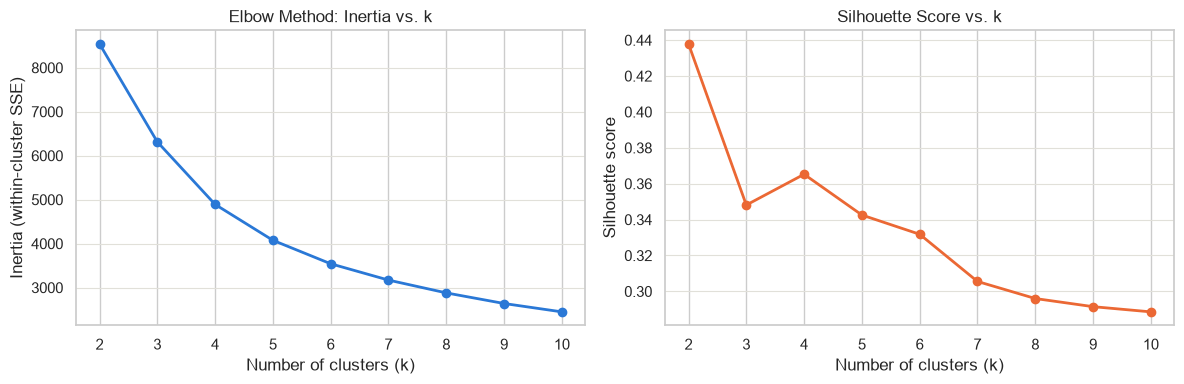

k, inertia, silhouette:
  k=2: inertia=8,542.4, silhouette=0.438
  k=3: inertia=6,314.5, silhouette=0.348
  k=4: inertia=4,891.8, silhouette=0.365
  k=5: inertia=4,075.8, silhouette=0.343
  k=6: inertia=3,542.1, silhouette=0.332
  k=7: inertia=3,171.0, silhouette=0.306
  k=8: inertia=2,879.8, silhouette=0.296
  k=9: inertia=2,638.7, silhouette=0.291
  k=10: inertia=2,448.4, silhouette=0.289

Highest silhouette score at k=2 (0.438) -- a starting candidate, not an automatic pick. Cross-check it against where the elbow chart actually bends, and against whether that k produces cluster profiles that make business sense once we look at them.


In [268]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, color=BLUE, marker="o", linewidth=2)
axes[0].set_title("Elbow Method: Inertia vs. k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
style_ax(axes[0])

axes[1].plot(list(k_range), silhouette_scores, color=ORANGE, marker="o", linewidth=2)
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
style_ax(axes[1])

plt.tight_layout()
plt.show()

print("k, inertia, silhouette:")
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"  k={k}: inertia={inertia:,.1f}, silhouette={sil:.3f}")

best_k_by_silhouette = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nHighest silhouette score at k={best_k_by_silhouette} ({max(silhouette_scores):.3f}) -- a starting"
      " candidate, not an automatic pick. Cross-check it against where the elbow chart actually bends,"
      " and against whether that k produces cluster profiles that make business sense once we look at them.")


The strongest statistical split is two customer groups, but the elbow and secondary silhouette peak indicate that four groups may provide a more useful level of business detail. Both solutions will be profiled, with four clusters preferred only if each segment is stable, distinct and actionable

## Profile k=2 vs. k=4

Fit both, attach cluster labels back to `rfm_df` (real units, not scaled log values) so the profiles are actually readable, and look at cluster sizes plus mean/median Recency/Frequency/Monetary per cluster. The specific thing to check for k=2: is one cluster a handful of customers that's obviously just "the wholesalers," confirming the silhouette-trap hypothesis, or is it a genuinely useful two-way split? k=4 is only worth preferring if its segments are distinct, reasonably sized, and describable in plain business terms -- not just because the elbow bent near it.

In [270]:
from sklearn.cluster import KMeans

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

candidate_ks = [2, 4]  # the two candidates worth comparing: strongest statistical
                       # split (k=2) vs. the elbow/secondary-silhouette candidate (k=4)

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    profile = rfm_df.copy()  # real, untransformed units -- far more readable than scaled log values
    profile["Cluster"] = labels

    print("=" * 70)
    print(f"k={k}")
    print("=" * 70)

    sizes = profile["Cluster"].value_counts().sort_index()
    print("Cluster sizes:")
    print(sizes)
    print(f"Smallest cluster: {sizes.min():,} customers ({sizes.min() / len(profile) * 100:.2f}% of the base)")

    print("\nCluster profiles (real units, mean / median):")
    print(profile.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"]).round(1))
    print()


k=2
Cluster sizes:
Cluster
0    2335
1    3505
Name: count, dtype: int64
Smallest cluster: 2,335 customers (39.98% of the base)

Cluster profiles (real units, mean / median):
        Recency        Frequency        Monetary        
           mean median      mean median     mean  median
Cluster                                                 
0         50.50  23.00     12.50   8.00  6263.10 2806.10
1        299.90 290.00      2.10   2.00   599.60  408.80

k=4
Cluster sizes:
Cluster
0    1973
1    1170
2    1240
3    1457
Name: count, dtype: int64
Smallest cluster: 1,170 customers (20.03% of the base)

Cluster profiles (real units, mean / median):
        Recency        Frequency        Monetary        
           mean median      mean median     mean  median
Cluster                                                 
0        393.30 401.00      1.40   1.00   319.60  275.40
1         27.50  16.00     19.30  13.00 10471.50 5026.20
2         28.10  24.00      3.00   3.00   841.20  725.00
3 

Although k=2 has the stronger silhouette score, it creates only a broad division:
Cluster 0: active, frequent and higher-value customers
Cluster 1: inactive, infrequent and lower-value customers
That separation is statistically clean but offers limited targeting detail.

### Recommended k=4 interpretation

| Cluster | Suggested label | Profile | Possible action |
|---|---|---|---|
| 0 | Low-value | Last purchase ~401 days ago, typically 1 order and £275 | Low-cost reactivation or suppress from expensive campaigns |
| 1 | Champions | Last purchase ~16 days ago, typically 13 orders and £5,026 | VIP retention, early access and priority service |
| 2 | Recent developing customers | Last purchase ~24 days ago, typically 3 orders and £725 | Encourage the next purchase and build loyalty |
| 3 | At-risk established customers | Last purchase ~178 days ago, typically 5 orders and £1,473 | Targeted win-back before they become fully lapsed |

| Cluster | Size | Recency (median) | Frequency (median) | Monetary (median) | Reads as |
|---|---:|---:|---:|---:|---|
| 0 | 1,973 | 401 days | 1 | £275 | Dormant / one-and-done |
| 1 | 1,170 | 16 days | 13 | £5,026 | High-value active (VIP) |
| 2 | 1,240 | 24 days | 3 | £725 | Recent, casual/low-spend |
| 3 | 1,457 | 178 days | 5 | £1,473 | Slipping / at-risk mid-value |

- Selected four clusters because they provide distinct, balanced and actionable customer groups. Retain the two-cluster result as a statistical benchmark, but it is too broad for the intended customer-intelligence use case

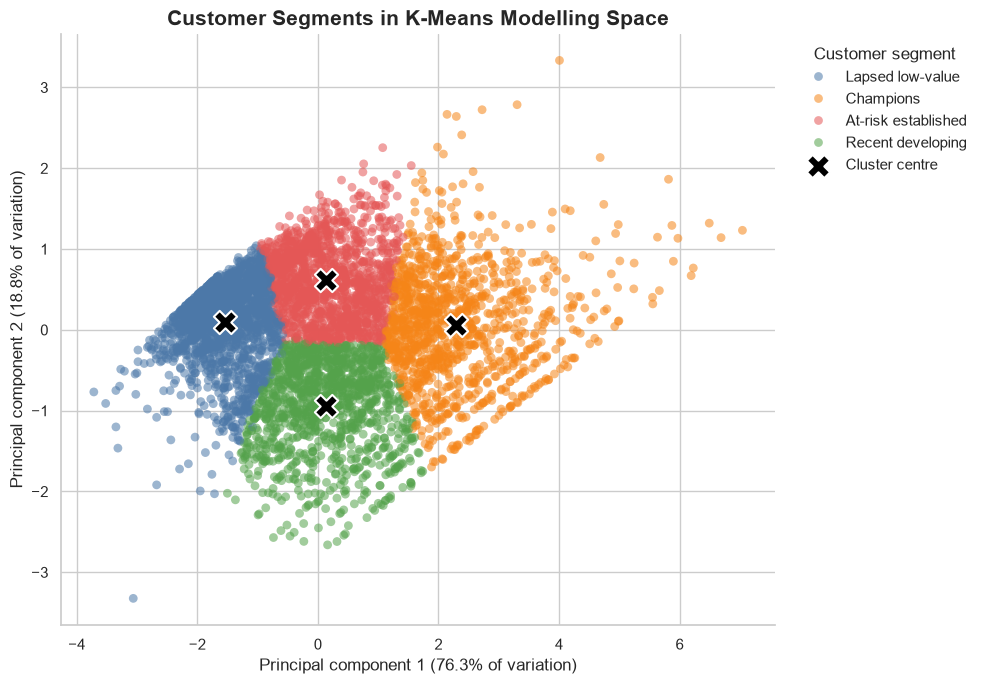

In [279]:
# ---------------------------------------------------------
# PCA visualization: transformed and scaled modelling space
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette=palette,
    alpha=0.55,
    s=40,
    linewidth=0,
    ax=ax,
)

# Project cluster centres into the same PCA space
ax.scatter(
    pca_centroids[:, 0],
    pca_centroids[:, 1],
    marker="X",
    s=280,
    color="black",
    edgecolor="white",
    linewidth=1.5,
    label="Cluster centre",
)

ax.set_title(
    "Customer Segments in K-Means Modelling Space",
    fontsize=15,
    weight="bold",
)

ax.set_xlabel(
    f"Principal component 1 "
    f"({pca.explained_variance_ratio_[0]:.1%} of variation)"
)

ax.set_ylabel(
    f"Principal component 2 "
    f"({pca.explained_variance_ratio_[1]:.1%} of variation)"
)

ax.legend(
    title="Customer segment",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

sns.despine()
plt.tight_layout()
plt.show()

- Stakeholder business visualization

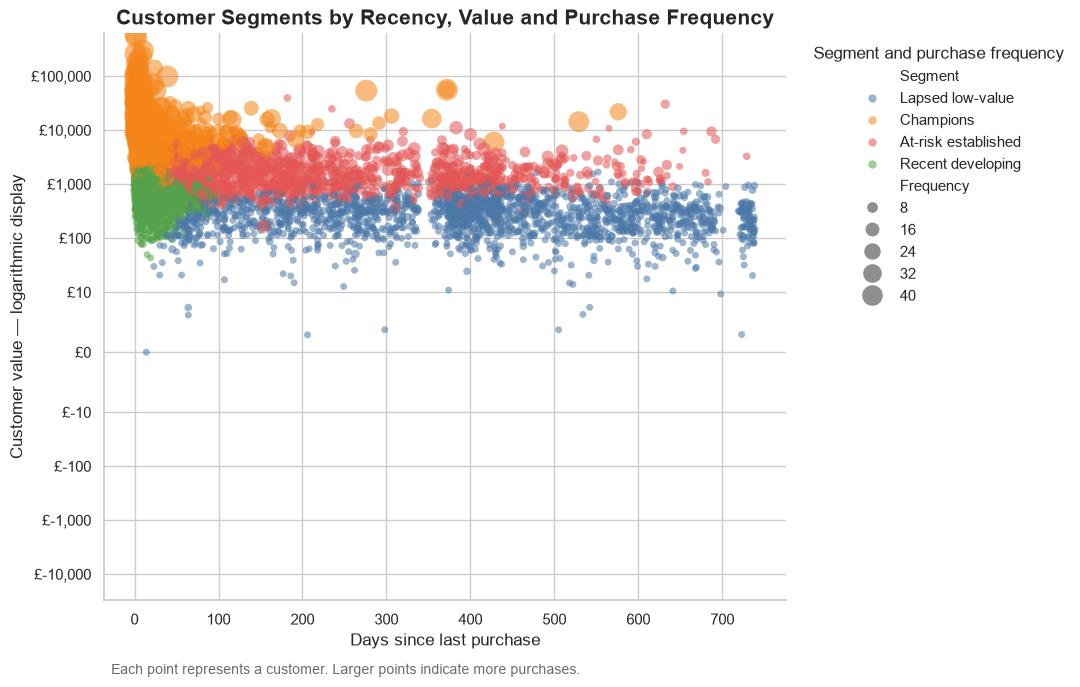

In [280]:
# ---------------------------------------------------------
# Business visualization: original RFM values
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=clustered_rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    size=frequency_size,
    sizes=(25, 250),
    palette=palette,
    alpha=0.55,
    linewidth=0,
    ax=ax,
)

# Supports Monetary = 0 while compressing the extreme upper range
ax.set_yscale("symlog", linthresh=10)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

ax.set_title(
    "Customer Segments by Recency, Value and Purchase Frequency",
    fontsize=15,
    weight="bold",
)

ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Customer value — logarithmic display")

ax.legend(
    title="Segment and purchase frequency",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.text(
    0.01,
    -0.13,
    "Each point represents a customer. Larger points indicate more purchases.",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray",
)

sns.despine()
plt.tight_layout()
plt.show()

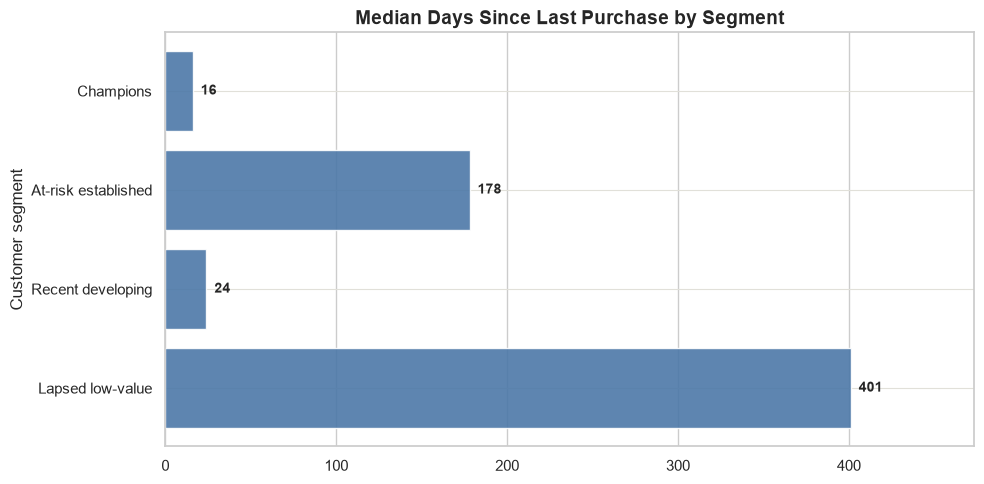

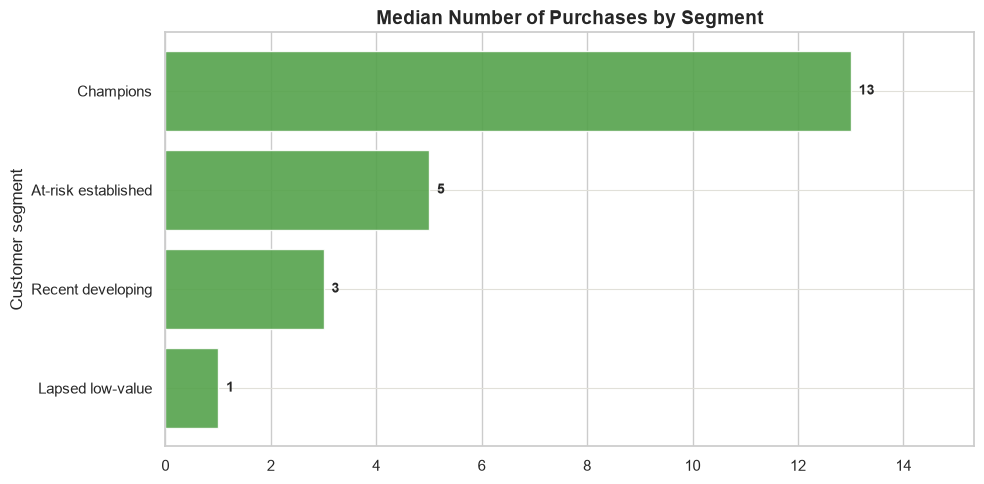

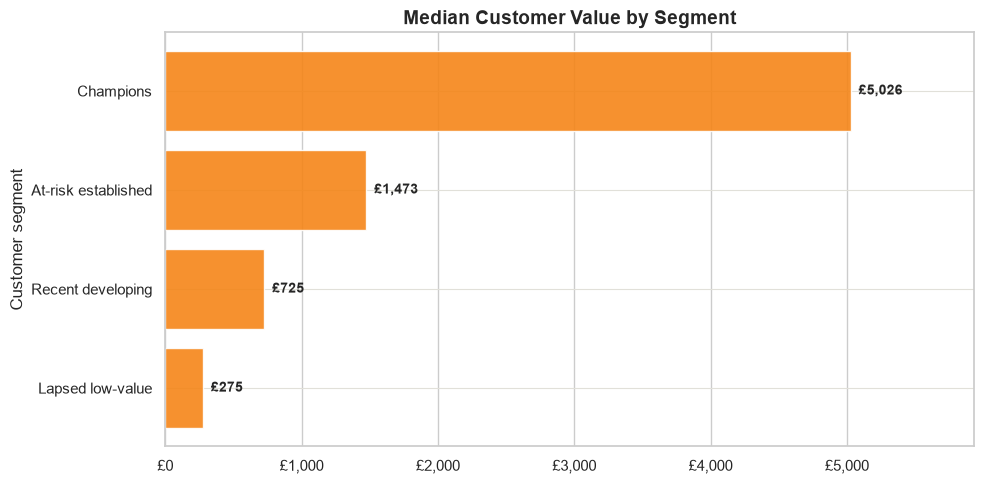

In [278]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

cluster_summary = (
    clustered_rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median"),
    )
    .sort_values("MedianMonetary")
)

charts = [
    (
        "MedianRecency",
        "Median Days Since Last Purchase by Segment",
        "#4C78A8",
    ),
    (
        "MedianFrequency",
        "Median Number of Purchases by Segment",
        "#54A24B",
    ),
    (
        "MedianMonetary",
        "Median Customer Value by Segment",
        "#F58518",
    ),
]

for column, title, color in charts:

    fig, ax = plt.subplots(figsize=(10, 5))

    values = cluster_summary[column]

    bars = ax.barh(
        cluster_summary.index,
        values,
        color=color,
        alpha=0.9,
    )

    ax.set_title(
        title,
        fontsize=14,
        weight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel("Customer segment")

    # Format the Monetary axis as pounds
    if column == "MedianMonetary":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"£{value:,.0f}")
        )

    # Add value labels to each bar
    for bar, value in zip(bars, values):

        label = (
            f"£{value:,.0f}"
            if column == "MedianMonetary"
            else f"{value:,.0f}"
        )

        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f"  {label}",
            va="center",
            fontsize=10,
            weight="bold",
        )

    # Leave space for labels beyond the bars
    ax.set_xlim(
        0,
        values.max() * 1.18
    )

    style_ax(ax)
    plt.tight_layout()
    plt.show()

## k=4 Stability Check

Refit k=4 across 8 different random seeds on the same `rfm_scaled` matrix, then compare every pair of runs with **Adjusted Rand Index** (not raw label matching -- K-Means labels are arbitrary between runs, ARI accounts for that). If the same four groups keep showing up regardless of seed, k=4 is a real structure in the data, not an artifact of one lucky initialization.

ARI is used to confirm the same four groups emerge each time, before trusting it.  ARI accounts for that and gives a 0–1 similarity score between any two clusterings, corrected for chance agreement. 
Why ARI specifically, not just comparing cluster sizes: K-Means labels are meaningless outside a single run — "cluster 1" in seed 0's run has no relationship to "cluster 1" in seed 42's run, even if they're grouping customers identically. ARI is built to ignore label numbering and just ask "do these two runs agree on which customers belong together," corrected for chance agreement, so it's the right tool rather than something homemade.

Once you run it, the number to watch is mean pairwise ARI: above ~0.8 means k=4 is a real, reliably-recovered structure regardless of where K-Means starts; 0.6–0.8 means it's usable but somewhat seed-sensitive (worth knowing, not necessarily disqualifying); below 0.6 would mean the four segments you've already built the whole visualization and labeling layer on top of aren't actually stable, and that's worth knowing before this goes any further. Run it and share the numbers.

In [292]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

k = 4
seeds = [0, 1, 2, 3, 4, 42, 99, 123]

all_labels = []
for seed in seeds:
    km = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = km.fit_predict(X)
    all_labels.append(labels)

print("Cluster sizes per seed (sorted descending -- labels are arbitrary between runs,")
print("so compare the SET of sizes, not which number got which size):")
for seed, labels in zip(seeds, all_labels):
    sizes = sorted(pd.Series(labels).value_counts().tolist(), reverse=True)
    print(f"  seed {seed}: {sizes}")

print("\nPairwise Adjusted Rand Index between every pair of seed runs:")
ari_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        ari_scores.append(ari)
        print(f"  seed {seeds[i]} vs seed {seeds[j]}: ARI = {ari:.3f}")

print(f"\nMean pairwise ARI: {np.mean(ari_scores):.3f}")
print(f"Min pairwise ARI:  {np.min(ari_scores):.3f}")
print(
    "\nReading the score: 1.0 = identical clustering every time; ~0 = no better than random "
    "agreement. Above ~0.8 is strong stability; 0.6-0.8 is usable but shows some seed-sensitivity; "
    "below 0.6 means k=4 is not landing on the same structure reliably and shouldn't be trusted as-is."
)


Cluster sizes per seed (sorted descending -- labels are arbitrary between runs,
so compare the SET of sizes, not which number got which size):
  seed 0: [1957, 1452, 1246, 1185]
  seed 1: [1957, 1452, 1246, 1185]
  seed 2: [1957, 1452, 1246, 1185]
  seed 3: [1966, 1456, 1244, 1174]
  seed 4: [1967, 1454, 1245, 1174]
  seed 42: [1973, 1457, 1240, 1170]
  seed 99: [1973, 1459, 1240, 1168]
  seed 123: [1966, 1457, 1244, 1173]

Pairwise Adjusted Rand Index between every pair of seed runs:
  seed 0 vs seed 1: ARI = 1.000
  seed 0 vs seed 2: ARI = 1.000
  seed 0 vs seed 3: ARI = 0.986
  seed 0 vs seed 4: ARI = 0.989
  seed 0 vs seed 42: ARI = 0.984
  seed 0 vs seed 99: ARI = 0.983
  seed 0 vs seed 123: ARI = 0.990
  seed 1 vs seed 2: ARI = 1.000
  seed 1 vs seed 3: ARI = 0.986
  seed 1 vs seed 4: ARI = 0.989
  seed 1 vs seed 42: ARI = 0.984
  seed 1 vs seed 99: ARI = 0.983
  seed 1 vs seed 123: ARI = 0.990
  seed 2 vs seed 3: ARI = 0.986
  seed 2 vs seed 4: ARI = 0.989
  seed 2 vs seed 42: A

This proves the four customer segments are highly stable and reliable.
Running the model repeatedly with different starting points produced almost identical results:
- Average agreement was 99.1%.
- The lowest agreement was still 98.3%.
- Cluster sizes remained nearly unchanged across every run.
- Only a small number of customers near segment boundaries moved between groups.
For stakeholders:
- The segments are not the result of a lucky or arbitrary model run. The same four customer groups consistently reappear when the model is restarted under different conditions, giving us confidence that they represent genuine patterns in customer purchasing behaviour.

One qualification:
- Customers near the boundary between two segments may occasionally change assignment. Their segment should be treated as less certain than customers located near the centre of a group.

Limitation of Kmeans
- One thing this result does not resolve, worth keeping in mind: stability tells you K-Means finds the same answer every time, not that the answer is maximally useful. The earlier finding still stands — Cluster 1 ("Champions") still has real internal skew (mean Monetary £10,472 vs. median £5,026), meaning the true extreme wholesalers are stable inside that cluster, not stable because they've been cleanly separated from the merely-good VIPs. K-Means, even reliably, still can't split that further without being told to

# DBSCAN: A Density-Based Second Opinion

K-Means (k=4) is stable and validated, but by construction it must assign every customer to one of four groups -- it can't say "this one doesn't really belong anywhere." DBSCAN can: it groups points by density and labels anything too sparse to belong to a dense region as noise (label -1). The specific question this answers: does DBSCAN independently pull the extreme wholesalers out of the "Champions" cluster as their own group or as noise, confirming the internal-skew finding from the stability check?

## Step 1: Pick eps via a k-Distance Plot

DBSCAN needs `eps` (neighbor distance threshold) and `min_samples` (how many neighbors make a dense region) before it can run -- unlike K-Means' `k`, these aren't found by sweeping a metric and picking a peak. The standard method: for every point, find the distance to its `min_samples`-th nearest neighbor, sort those distances, and look for where the curve bends sharply upward. That bend is the natural `eps` -- below it, points sit in dense neighborhoods; above it, they're increasingly isolated (which is exactly the outlier-detection behavior we want to test).

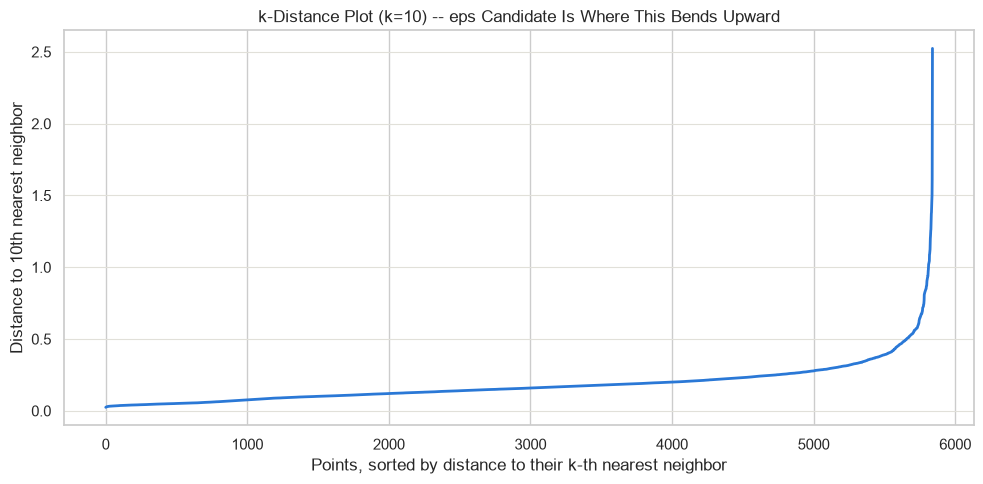

k-distance range: 0.024 to 2.524
Percentiles (candidate eps values to read off the knee against):
  80th percentile: 0.245
  85th percentile: 0.274
  90th percentile: 0.319
  92th percentile: 0.350
  95th percentile: 0.410
  97th percentile: 0.507
  99th percentile: 0.793


In [293]:
from sklearn.neighbors import NearestNeighbors

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

# Rule of thumb for min_samples: roughly 2x the number of features (3 here),
# rounded up a bit for robustness given ~5,840 records. This is a starting
# point, not final -- can revisit once we see how DBSCAN's results look.
MIN_SAMPLES = 10

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(X)
distances, _ = neighbors.kneighbors(X)

# Distance to each point's MIN_SAMPLES-th nearest neighbor, sorted ascending.
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color=BLUE, linewidth=2)
ax.set_title(f"k-Distance Plot (k={MIN_SAMPLES}) -- eps Candidate Is Where This Bends Upward")
ax.set_xlabel("Points, sorted by distance to their k-th nearest neighbor")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor")
style_ax(ax)
plt.tight_layout()
plt.show()

print(f"k-distance range: {k_distances.min():.3f} to {k_distances.max():.3f}")
print("Percentiles (candidate eps values to read off the knee against):")
for p in [80, 85, 90, 92, 95, 97, 99]:
    print(f"  {p}th percentile: {np.percentile(k_distances, p):.3f}")


## Step 2: Fit DBSCAN, Bracketing the Knee

Testing eps=0.40, 0.45, 0.50 (bracketing the visual knee from the k-distance plot) with min_samples=10, on the same `rfm_scaled` matrix used throughout. For each: how many clusters DBSCAN finds on its own, how many customers get labeled noise (-1), and each cluster's real-unit RFM profile -- specifically watching whether the known extreme wholesalers end up isolated as noise or their own small cluster, rather than folded into a larger group the way K-Means had to.

In [294]:
from sklearn.cluster import DBSCAN

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

MIN_SAMPLES = 10
candidate_eps = [0.40, 0.45, 0.50]  # bracketing the visual knee from the k-distance plot

for eps in candidate_eps:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print("=" * 70)
    print(f"eps={eps}")
    print("=" * 70)
    print(f"Clusters found: {n_clusters}")
    print(f"Noise points: {n_noise:,} ({n_noise / len(labels) * 100:.2f}%)")

    profile = rfm_df.copy()
    profile["Cluster"] = labels
    sizes = profile["Cluster"].value_counts().sort_index()
    print("\nCluster sizes (label -1 = noise):")
    print(sizes)

    print("\nCluster profiles (real units, mean / median):")
    print(profile.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"]).round(1))
    print()


eps=0.4
Clusters found: 2
Noise points: 149 (2.55%)

Cluster sizes (label -1 = noise):
Cluster
-1     149
 0    4105
 1    1586
Name: count, dtype: int64

Cluster profiles (real units, mean / median):
        Recency        Frequency        Monetary         
           mean median      mean median     mean   median
Cluster                                                  
-1       151.80  38.00     38.50  15.00 37401.20 13133.80
 0       142.10  60.00      7.10   4.00  2594.50  1318.80
 1       355.10 387.00      1.00   1.00   317.10   230.10

eps=0.45
Clusters found: 2
Noise points: 105 (1.80%)

Cluster sizes (label -1 = noise):
Cluster
-1     105
 0    4143
 1    1592
Name: count, dtype: int64

Cluster profiles (real units, mean / median):
        Recency        Frequency        Monetary         
           mean median      mean median     mean   median
Cluster                                                  
-1       137.80  30.00     46.90  19.00 47483.60 16408.80
 0       142.30 

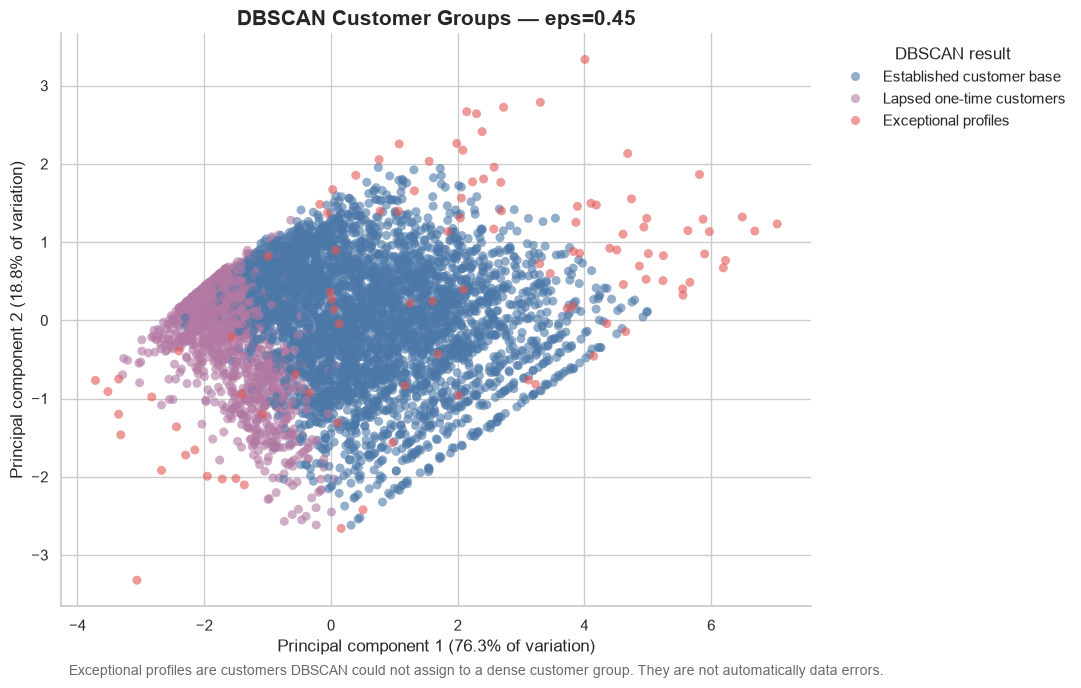

In [300]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------------------------------
# Fit the selected DBSCAN model
# ---------------------------------------------------------
DBSCAN_EPS = 0.45
MIN_SAMPLES = 10

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=MIN_SAMPLES,
)

dbscan_labels = dbscan.fit_predict(X)

# ---------------------------------------------------------
# Project the full scaled RFM space into two dimensions
# ---------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

dbscan_plot = rfm_df[
    ["Customer ID", "Recency", "Frequency", "Monetary"]
].copy()

dbscan_plot["PC1"] = X_pca[:, 0]
dbscan_plot["PC2"] = X_pca[:, 1]
dbscan_plot["DBSCAN_Cluster"] = dbscan_labels

# Names based on the profiles produced in cell 138
dbscan_names = {
    -1: "Exceptional profiles",
     0: "Established customer base",
     1: "Lapsed one-time customers",
}

dbscan_plot["Segment"] = (
    dbscan_plot["DBSCAN_Cluster"].map(dbscan_names)
)

dbscan_palette = {
    "Exceptional profiles": "#E45756",
    "Established customer base": "#4C78A8",
    "Lapsed one-time customers": "#B279A2",
}

# Draw normal clusters first and exceptional profiles last
dbscan_plot["plot_order"] = (
    dbscan_plot["DBSCAN_Cluster"] == -1
).astype(int)

dbscan_plot = dbscan_plot.sort_values("plot_order")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=dbscan_plot,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette=dbscan_palette,
    alpha=0.60,
    s=42,
    linewidth=0,
    ax=ax,
)

ax.set_title(
    f"DBSCAN Customer Groups — eps={DBSCAN_EPS}",
    fontsize=15,
    weight="bold",
)

ax.set_xlabel(
    f"Principal component 1 "
    f"({pca.explained_variance_ratio_[0]:.1%} of variation)"
)

ax.set_ylabel(
    f"Principal component 2 "
    f"({pca.explained_variance_ratio_[1]:.1%} of variation)"
)

ax.legend(
    title="DBSCAN result",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.text(
    0.01,
    -0.12,
    "Exceptional profiles are customers DBSCAN could not assign to a dense "
    "customer group. They are not automatically data errors.",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray",
)

sns.despine()
plt.tight_layout()
plt.show()

# Hybrid Segmentation: DBSCAN Outliers + K-Means on the Remainder

Plan: identify the customers DBSCAN robustly flags as noise (outliers regardless of the exact eps choice), split them out as their own segment, then re-fit K-Means (k=4) on everyone else. Comparing the new cluster profiles against the original full-population k=4 result is the direct test of whether this actually fixes the internal-skew problem found in the "Champions" cluster, not just a hopeful assumption.

In [295]:
from sklearn.cluster import DBSCAN

feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm_scaled[feature_cols].values

MIN_SAMPLES = 10

# Recompute noise sets across the three tested eps values and take the
# INTERSECTION -- customers flagged as outliers no matter which eps was
# used, not just at one arbitrary parameter choice.
noise_sets = {}
for eps in [0.40, 0.45, 0.50]:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X)
    noise_sets[eps] = set(rfm_scaled.loc[labels == -1, "Customer ID"])

for eps, s in noise_sets.items():
    print(f"eps={eps}: {len(s)} noise customers")

core_outliers = noise_sets[0.40] & noise_sets[0.45] & noise_sets[0.50]
print(f"\nCore outliers (noise at ALL three eps values): {len(core_outliers)}")

is_outlier = rfm_df["Customer ID"].isin(core_outliers)
rfm_outliers = rfm_df[is_outlier].reset_index(drop=True)
rfm_remainder = rfm_df[~is_outlier].reset_index(drop=True)

print(f"\nOutlier segment: {len(rfm_outliers):,} customers")
print(f"Remainder (for re-clustering): {len(rfm_remainder):,} customers")
print("\nOutlier segment profile (real units):")
print(rfm_outliers[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"]).round(1))

eps=0.4: 149 noise customers
eps=0.45: 105 noise customers
eps=0.5: 82 noise customers

Core outliers (noise at ALL three eps values): 82

Outlier segment: 82 customers
Remainder (for re-clustering): 5,758 customers

Outlier segment profile (real units):
        Recency  Frequency  Monetary
mean     141.30      54.30  56794.00
median    27.50      22.50  18164.40


In [296]:
# Rebuild log-transform + scaling for JUST the remainder. Refitting
# StandardScaler here (not reusing the full-population scaler) matters --
# removing ~100 extreme customers shifts the mean/std of what's left, so the
# remainder needs its own scale, not one calibrated against outliers that
# are no longer in the data.
log_cols = ["Recency", "Frequency", "Monetary"]

rfm_remainder_log = rfm_remainder.copy()
rfm_remainder_log[log_cols] = np.log1p(rfm_remainder[log_cols])

remainder_scaler = StandardScaler()
remainder_scaled_values = remainder_scaler.fit_transform(rfm_remainder_log[log_cols])

rfm_remainder_scaled = rfm_remainder_log[["Customer ID"]].copy()
rfm_remainder_scaled[log_cols] = remainder_scaled_values

print(rfm_remainder_scaled[log_cols].describe())

       Recency  Frequency  Monetary
count  5758.00    5758.00   5758.00
mean      0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -2.43      -1.08     -3.65
25%      -0.75      -1.08     -0.72
50%       0.07      -0.18     -0.02
75%       0.96       0.72      0.69
max       1.39       3.71      3.16


In [297]:
from sklearn.cluster import KMeans

X_remainder = rfm_remainder_scaled[log_cols].values

km_remainder = KMeans(n_clusters=4, random_state=42, n_init=10)
remainder_labels = km_remainder.fit_predict(X_remainder)

profile_remainder = rfm_remainder.copy()
profile_remainder["Cluster"] = remainder_labels

print("New K-Means (k=4) on the remainder -- cluster sizes:")
print(profile_remainder["Cluster"].value_counts().sort_index())

print("\nNew cluster profiles (real units, mean / median):")
print(profile_remainder.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"]).round(1))

New K-Means (k=4) on the remainder -- cluster sizes:
Cluster
0    1208
1    1186
2    1937
3    1427
Name: count, dtype: int64

New cluster profiles (real units, mean / median):
        Recency        Frequency        Monetary        
           mean median      mean median     mean  median
Cluster                                                 
0         28.80  24.00      2.90   3.00   800.90  706.60
1         26.00  17.00     15.80  12.00  6705.10 4556.60
2        395.80 402.00      1.40   1.00   317.70  273.00
3        227.90 185.00      5.00   4.00  1775.50 1436.80


## Before vs. After: Did Removing the Outliers Fix the Skew?

The direct test: recompute the ORIGINAL k=4 (fit on the full population, outliers included) and compare its mean/median Monetary ratio per cluster against the NEW remainder-only k=4. A ratio near 1.0 means the cluster is homogeneous (mean and median agree, no hidden internal skew); a ratio well above 1.0 means a handful of extreme values are still dragging the average up, same problem as before.

In [298]:
original_km = KMeans(n_clusters=4, random_state=42, n_init=10)
original_labels = original_km.fit_predict(X)  # X = full-population rfm_scaled from earlier

profile_original = rfm_df.copy()
profile_original["Cluster"] = original_labels

original_stats = profile_original.groupby("Cluster")["Monetary"].agg(["mean", "median"])
original_stats["mean_over_median"] = (original_stats["mean"] / original_stats["median"]).round(2)

new_stats = profile_remainder.groupby("Cluster")["Monetary"].agg(["mean", "median"])
new_stats["mean_over_median"] = (new_stats["mean"] / new_stats["median"]).round(2)

print("ORIGINAL k=4 (full population, outliers included) -- Monetary mean/median ratio per cluster:")
print(original_stats.round(1))

print("\nNEW k=4 (outliers removed first) -- Monetary mean/median ratio per cluster:")
print(new_stats.round(1))

print(f"\nOriginal worst-case ratio (most internally skewed cluster): {original_stats['mean_over_median'].max():.2f}")
print(f"New worst-case ratio (most internally skewed cluster):      {new_stats['mean_over_median'].max():.2f}")
print("Closer to 1.0 = more homogeneous. A clear drop confirms removing the DBSCAN outliers actually fixed the skew, not just moved it.")

ORIGINAL k=4 (full population, outliers included) -- Monetary mean/median ratio per cluster:
            mean  median  mean_over_median
Cluster                                   
0         319.60  275.40              1.20
1       10471.50 5026.20              2.10
2         841.20  725.00              1.20
3        1922.30 1473.30              1.30

NEW k=4 (outliers removed first) -- Monetary mean/median ratio per cluster:
           mean  median  mean_over_median
Cluster                                  
0        800.90  706.60              1.10
1       6705.10 4556.60              1.50
2        317.70  273.00              1.20
3       1775.50 1436.80              1.20

Original worst-case ratio (most internally skewed cluster): 2.08
New worst-case ratio (most internally skewed cluster):      1.47
Closer to 1.0 = more homogeneous. A clear drop confirms removing the DBSCAN outliers actually fixed the skew, not just moved it.


## Final Combined Segmentation

Five segments: the DBSCAN-identified outlier group, plus the four re-fit K-Means clusters from everyone else.

In [299]:
rfm_hybrid = pd.concat([
    rfm_outliers.assign(Cluster="Outlier"),
    profile_remainder.assign(Cluster=profile_remainder["Cluster"].astype(str)),
], ignore_index=True)

print(f"Total customers accounted for: {len(rfm_hybrid):,} (should match rfm_df: {len(rfm_df):,})")
print("\nFinal segment sizes:")
print(rfm_hybrid["Cluster"].value_counts())

print("\nFinal segment profiles (real units, mean / median):")
print(rfm_hybrid.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"]).round(1))

Total customers accounted for: 5,840 (should match rfm_df: 5,840)

Final segment sizes:
Cluster
2          1937
3          1427
0          1208
1          1186
Outlier      82
Name: count, dtype: int64

Final segment profiles (real units, mean / median):
        Recency        Frequency        Monetary         
           mean median      mean median     mean   median
Cluster                                                  
0         28.80  24.00      2.90   3.00   800.90   706.60
1         26.00  17.00     15.80  12.00  6705.10  4556.60
2        395.80 402.00      1.40   1.00   317.70   273.00
3        227.90 185.00      5.00   4.00  1775.50  1436.80
Outlier  141.30  27.50     54.30  22.50 56794.00 18164.40


the 82-customer Outlier segment is itself not homogeneous (that 3.13 mean/median ratio). If there's ever a business need to split "very good customer" from "true mega-wholesaler" within that group, that's what HDBSCAN is actually good for — it doesn't need a single global eps the way DBSCAN does, so it can find varying-density sub-structure inside what plain DBSCAN just calls one flat noise bucket. I'd only reach for it if someone downstream actually asks for finer VIP tiering.

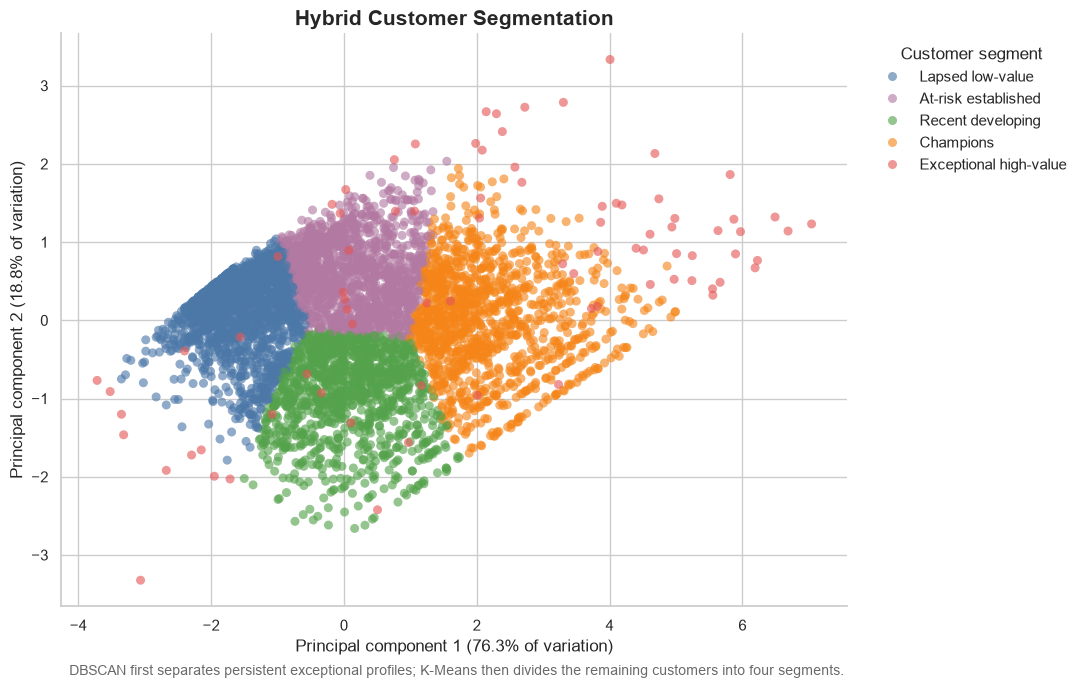

In [301]:
# ---------------------------------------------------------
# Add stakeholder-friendly hybrid segment names
# Mapping is based on the profiles from cells 142 and 146
# ---------------------------------------------------------
hybrid_names = {
    "0": "Recent developing",
    "1": "Champions",
    "2": "Lapsed low-value",
    "3": "At-risk established",
    "Outlier": "Exceptional high-value",
}

hybrid_plot = rfm_hybrid.copy()
hybrid_plot["Segment"] = (
    hybrid_plot["Cluster"].astype(str).map(hybrid_names)
)

# Reuse the full-population PCA coordinates so every customer is
# displayed in the same coordinate system as the DBSCAN chart.
pca_coordinates = pd.DataFrame({
    "Customer ID": rfm_df["Customer ID"].values,
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
})

hybrid_plot = hybrid_plot.merge(
    pca_coordinates,
    on="Customer ID",
    how="left",
    validate="one_to_one",
)

hybrid_palette = {
    "Recent developing": "#54A24B",
    "Champions": "#F58518",
    "Lapsed low-value": "#4C78A8",
    "At-risk established": "#B279A2",
    "Exceptional high-value": "#E45756",
}

# Plot exceptional customers last so they remain visible
hybrid_plot["plot_order"] = (
    hybrid_plot["Segment"] == "Exceptional high-value"
).astype(int)

hybrid_plot = hybrid_plot.sort_values("plot_order")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=hybrid_plot,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette=hybrid_palette,
    alpha=0.62,
    s=42,
    linewidth=0,
    ax=ax,
)

ax.set_title(
    "Hybrid Customer Segmentation",
    fontsize=15,
    weight="bold",
)

ax.set_xlabel(
    f"Principal component 1 "
    f"({pca.explained_variance_ratio_[0]:.1%} of variation)"
)

ax.set_ylabel(
    f"Principal component 2 "
    f"({pca.explained_variance_ratio_[1]:.1%} of variation)"
)

ax.legend(
    title="Customer segment",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.text(
    0.01,
    -0.12,
    "DBSCAN first separates persistent exceptional profiles; "
    "K-Means then divides the remaining customers into four segments.",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray",
)

sns.despine()
plt.tight_layout()
plt.show()

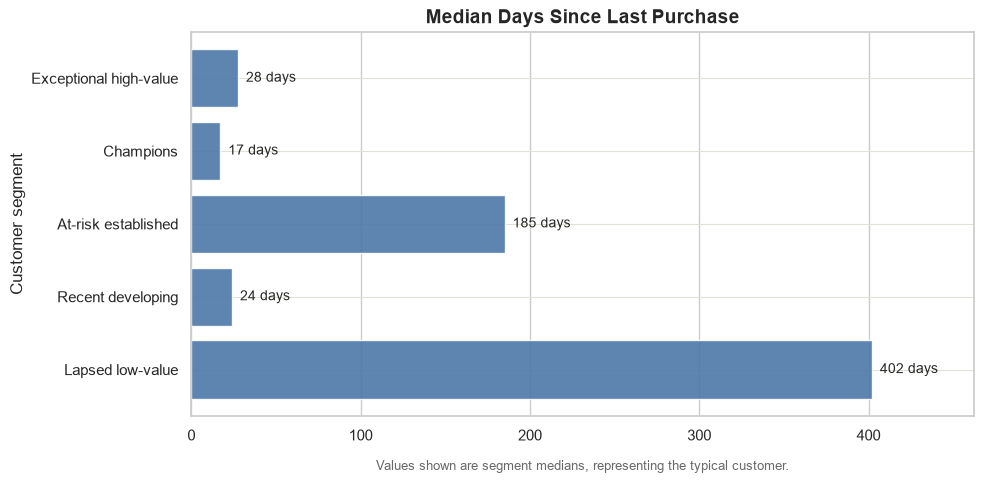

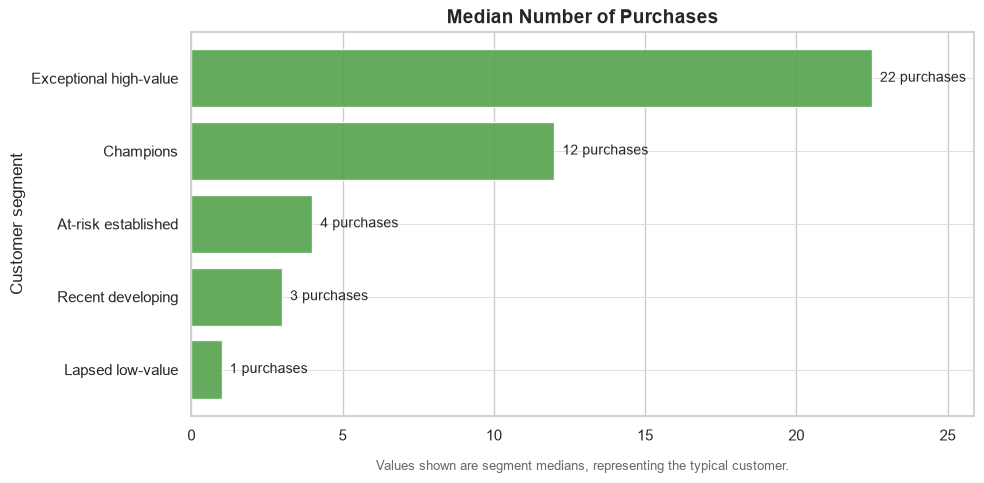

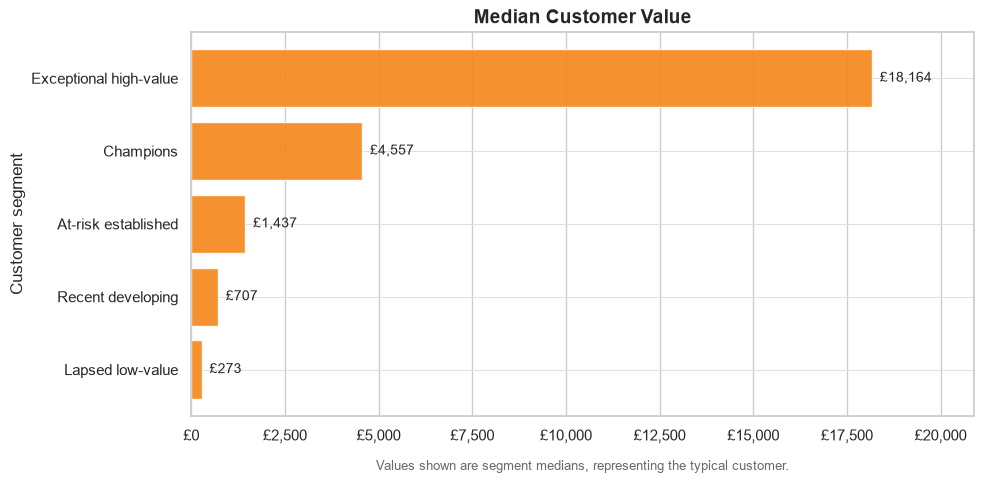

In [303]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

hybrid_summary = (
    hybrid_plot.groupby("Segment", observed=True)
    .agg(
        Customers=("Customer ID", "count"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median"),
    )
    .sort_values("MedianMonetary")
)

chart_settings = [
    (
        "MedianRecency",
        "Median Days Since Last Purchase",
        "#4C78A8",
    ),
    (
        "MedianFrequency",
        "Median Number of Purchases",
        "#54A24B",
    ),
    (
        "MedianMonetary",
        "Median Customer Value",
        "#F58518",
    ),
]

# Each loop iteration creates and displays a separate image
for column, title, color in chart_settings:

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.barh(
        hybrid_summary.index,
        hybrid_summary[column],
        color=color,
        alpha=0.9,
    )

    ax.set_title(
        title,
        fontsize=14,
        weight="bold",
    )

    ax.set_xlabel("")
    ax.set_ylabel("Customer segment")

    # Add value labels at the end of each bar
    for bar, value in zip(bars, hybrid_summary[column]):

        if column == "MedianMonetary":
            label = f"£{value:,.0f}"
        elif column == "MedianRecency":
            label = f"{value:,.0f} days"
        else:
            label = f"{value:,.0f} purchases"

        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f"  {label}",
            va="center",
            fontsize=10,
        )

    if column == "MedianMonetary":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"£{value:,.0f}")
        )

    ax.margins(x=0.15)

    ax.text(
        0.5,
        -0.14,
        "Values shown are segment medians, representing the typical customer.",
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        color="dimgray",
    )

    style_ax(ax)
    plt.tight_layout()
    plt.show()

# Sanity-Check Segments Against What We Already Know

Before treating these five segments as genuine behavioral personas, check them against two things already established earlier in this analysis: **Country** (is any segment just a geography artifact?) and **which year-sheet(s) a customer appears in** (is "Dormant" a real behavioral type, or just "customers whose last purchase happened to fall in 2009-2010, before the snapshot window ran out")? A segment that turns out to be a structural artifact isn't wrong, but it needs a different explanation than a segment that's genuinely behavioral.

In [304]:
# Attach customer-level Country (most frequent per customer) and cohort/
# tenure info (which year-sheet(s) they appear in) from purchases_df.
customer_country = (
    purchases_df.groupby("Customer ID")["Country"]
    .agg(lambda s: s.mode().iloc[0])
    .rename("PrimaryCountry")
)

customer_years = (
    purchases_df.groupby("Customer ID")["source_sheet"]
    .agg(lambda s: " & ".join(sorted(s.unique())))
    .rename("YearsActive")
)

segment_context = hybrid_plot.merge(customer_country, on="Customer ID", how="left")
segment_context = segment_context.merge(customer_years, on="Customer ID", how="left")

print(f"Customers with context attached: {len(segment_context):,} (should match hybrid_plot: {len(hybrid_plot):,})")
print(f"Missing PrimaryCountry: {segment_context['PrimaryCountry'].isnull().sum()}")
print(f"Missing YearsActive: {segment_context['YearsActive'].isnull().sum()}")

Customers with context attached: 5,840 (should match hybrid_plot: 5,840)
Missing PrimaryCountry: 0
Missing YearsActive: 0


In [305]:
# Check 1: is any segment a geography artifact? Compare each segment's UK
# share against the overall baseline (~90%).
segment_context["IsUK"] = segment_context["PrimaryCountry"] == "United Kingdom"

uk_share = (segment_context.groupby("Segment")["IsUK"].mean() * 100).sort_values()
print("UK share per segment (%):")
print(uk_share.round(1))
print(f"\nOverall UK share (reference): {segment_context['IsUK'].mean() * 100:.1f}%")

print("\nWhere a segment has non-UK customers, top countries represented:")
for segment in segment_context["Segment"].unique():
    sub = segment_context[(segment_context["Segment"] == segment) & (~segment_context["IsUK"])]
    if len(sub) == 0:
        continue
    print(f"\n{segment}: {len(sub)} non-UK customers")
    print(sub["PrimaryCountry"].value_counts().head(3))

UK share per segment (%):
Segment
Exceptional high-value   82.90
At-risk established      90.40
Champions                90.60
Recent developing        91.00
Lapsed low-value         92.70
Name: IsUK, dtype: float64

Overall UK share (reference): 91.2%

Where a segment has non-UK customers, top countries represented:

Lapsed low-value: 141 non-UK customers
PrimaryCountry
France     29
Germany    18
Spain      11
Name: count, dtype: int64

At-risk established: 137 non-UK customers
PrimaryCountry
Germany        28
Switzerland    11
France         11
Name: count, dtype: int64

Recent developing: 109 non-UK customers
PrimaryCountry
Germany    29
France     20
Spain      14
Name: count, dtype: int64

Champions: 112 non-UK customers
PrimaryCountry
France     32
Germany    29
Belgium     7
Name: count, dtype: int64

Exceptional high-value: 14 non-UK customers
PrimaryCountry
Norway     2
Sweden     2
Germany    2
Name: count, dtype: int64


#### Stakeholder summary
Customer behaviour is broadly consistent across geography: the principal segments closely match the company’s overall UK concentration. Exceptional high-value customers are more internationally represented, suggesting that some important wholesale-scale relationships exist outside the UK. France and Germany appear repeatedly across the standard segments, but no country dominates sufficiently to explain the segmentation.

#### Business implications
- Keep the main campaign strategy behaviour-based rather than creating separate UK and international segments.
- Localize communications for France, Germany and other meaningful markets.
- Review the 14 exceptional non-UK accounts individually because account-level management is appropriate for this segment.
- Consider shipping cost, currency, delivery time and country-specific purchasing patterns when profiling international exceptional accounts.
- Do not create country-specific clusters based on these figures alone.

In [306]:
# Check 2: is a segment (e.g. "Dormant") really just "customers who only
# appear in the earlier year-sheet" -- a structural artifact of the snapshot
# date, not a distinct behavioral pattern?
years_counts = pd.crosstab(segment_context["Segment"], segment_context["YearsActive"])
years_pct = (pd.crosstab(segment_context["Segment"], segment_context["YearsActive"], normalize="index") * 100).round(1)

print("Years-active counts per segment:")
print(years_counts)
print("\nYears-active share per segment (%):")
print(years_pct)

Years-active counts per segment:
YearsActive             Year 2009-2010  Year 2009-2010 & Year 2010-2011  \
Segment                                                                   
At-risk established                328                              966   
Champions                            0                             1075   
Exceptional high-value              12                               51   
Lapsed low-value                  1174                              191   
Recent developing                    0                              476   

YearsActive             Year 2010-2011  
Segment                                 
At-risk established                133  
Champions                          111  
Exceptional high-value              19  
Lapsed low-value                   572  
Recent developing                  732  

Years-active share per segment (%):
YearsActive             Year 2009-2010  Year 2009-2010 & Year 2010-2011  \
Segment                                   

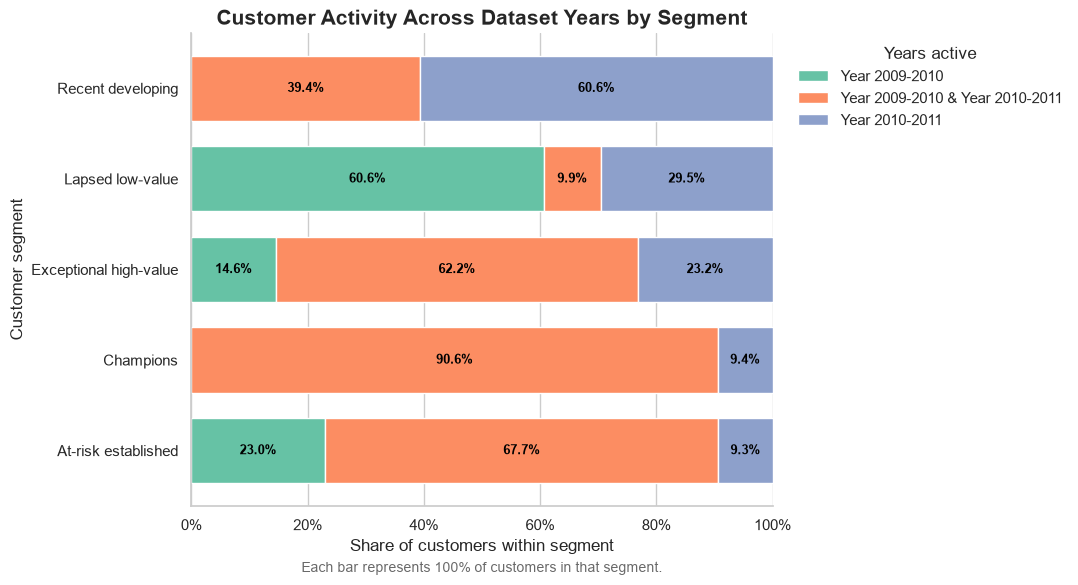

In [307]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# Build count and percentage tables
# ---------------------------------------------------------
years_counts = pd.crosstab(
    segment_context["Segment"],
    segment_context["YearsActive"],
)

years_pct = (
    pd.crosstab(
        segment_context["Segment"],
        segment_context["YearsActive"],
        normalize="index",
    )
    .mul(100)
    .round(1)
)

# Keep segment order consistent with the current table
years_pct = years_pct.loc[years_counts.index]

# ---------------------------------------------------------
# Stakeholder-friendly 100% stacked bar chart
# ---------------------------------------------------------
colors = sns.color_palette("Set2", n_colors=len(years_pct.columns))

fig, ax = plt.subplots(figsize=(11, 6))

years_pct.plot(
    kind="barh",
    stacked=True,
    color=colors,
    width=0.72,
    ax=ax,
)

# Add percentage labels inside sufficiently large sections
for segment_position, segment in enumerate(years_pct.index):

    cumulative_width = 0

    for category in years_pct.columns:
        percentage = years_pct.loc[segment, category]

        if percentage >= 5:
            ax.text(
                cumulative_width + percentage / 2,
                segment_position,
                f"{percentage:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                weight="bold",
                color="black",
            )

        cumulative_width += percentage

ax.set_title(
    "Customer Activity Across Dataset Years by Segment",
    fontsize=15,
    weight="bold",
)

ax.set_xlabel("Share of customers within segment")
ax.set_ylabel("Customer segment")
ax.set_xlim(0, 100)

ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{value}%" for value in range(0, 101, 20)])

ax.legend(
    title="Years active",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.text(
    0.5,
    -0.14,
    "Each bar represents 100% of customers in that segment.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="dimgray",
)

sns.despine()
plt.tight_layout()
plt.show()

In [308]:
display(
    years_pct.style
    .format("{:.1f}%")
    .background_gradient(cmap="Blues", axis=None)
    .set_caption("Share of Customers by Years Active and Segment")
)

YearsActive,Year 2009-2010,Year 2009-2010 & Year 2010-2011,Year 2010-2011
Segment,,,
At-risk established,23.0%,67.7%,9.3%
Champions,0.0%,90.6%,9.4%
Exceptional high-value,14.6%,62.2%,23.2%
Lapsed low-value,60.6%,9.9%,29.5%
Recent developing,0.0%,39.4%,60.6%


In [309]:
combined_table = years_counts.astype(str) + (
    " (" + years_pct.astype(str) + "%)"
)

display(
    combined_table.style
    .set_caption("Customer Count and Share by Years Active")
)

YearsActive,Year 2009-2010,Year 2009-2010 & Year 2010-2011,Year 2010-2011
Segment,,,
At-risk established,328 (23.0%),966 (67.7%),133 (9.3%)
Champions,0 (0.0%),1075 (90.6%),111 (9.4%)
Exceptional high-value,12 (14.6%),51 (62.2%),19 (23.2%)
Lapsed low-value,1174 (60.6%),191 (9.9%),572 (29.5%)
Recent developing,0 (0.0%),476 (39.4%),732 (60.6%)


| Current segment | Recommended business label | Interpretation | Primary action |
|---|---|---|---|
| Champions | Champions | Sustained, recent, frequent, high-value customers | Retention, VIP treatment, early access |
| Lapsed low-value | Never-Repeat / Early Lapsed | Mostly early one-time buyers, not formerly loyal customers | Second-purchase activation rather than loyalty win-back |
| Recent developing | New & Developing | Primarily new customers with limited purchase history | Onboarding and nurture toward a second/third purchase |
| At-risk established | At-Risk Established | Previously demonstrated repeat behaviour but becoming inactive | Personalized win-back |
| Exceptional high-value | Exceptional / Key Accounts | Wholesale-scale customers, including sustained and newer accounts | Individual account management |

#### Stakeholder summary
- The segments reflect genuine differences in customer behaviour, but lifecycle analysis revealed that not all inactive or low-frequency customers should receive the same treatment. Most dormant customers were never repeat buyers, so they require second-purchase activation rather than traditional win-back messaging. Recent low-frequency customers also divide into genuinely new customers and established occasional buyers. Champions, at-risk established customers, and exceptional accounts show sustained behavioural patterns consistent with their segment definitions

## Quantitative Backing for the Segment-Action Table

Pairs the qualitative table above with actual computed numbers -- size, share of the base, RFM medians, and UK share -- so the recommendations above can be sized and prioritized, not just read.

In [310]:
segment_stats = (
    segment_context.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median"),
        UKShare=("IsUK", "mean"),
    )
)
segment_stats["SharePct"] = (segment_stats["Customers"] / segment_stats["Customers"].sum() * 100).round(1)
segment_stats["UKShare"] = (segment_stats["UKShare"] * 100).round(1)
segment_stats = segment_stats.sort_values("MedianMonetary", ascending=False)

segment_stats[["Customers", "SharePct", "MedianRecency", "MedianFrequency", "MedianMonetary", "UKShare"]]

,Customers,SharePct,MedianRecency,MedianFrequency,MedianMonetary,UKShare
Segment,,,,,,
Exceptional high-value,82,1.40,27.50,22.50,18164.45,82.90
Champions,1186,20.30,17.00,12.00,4556.55,90.60
At-risk established,1427,24.40,185.00,4.00,1436.79,90.40
Recent developing,1208,20.70,24.00,3.00,706.62,91.00
Lapsed low-value,1937,33.20,402.00,1.00,272.96,92.70


## Refinement: "New & Developing" Is Two Different Audiences

The years-active check found this segment is 60.6% genuinely new customers (2010-2011 only) and 39.4% customers who\'ve been around since 2009-2010 and never grew past casual. One action line doesn\'t serve both -- onboarding nurture makes sense for someone in their first purchase cycle, not for someone two years into being a customer and still ordering once in a while. Splitting the action avoids spending onboarding budget on people who already know the brand and simply aren\'t going to escalate.

In [311]:
recent_developing = segment_context[segment_context["Segment"] == "Recent developing"]

genuinely_new = recent_developing[recent_developing["YearsActive"] == "Year 2010-2011"]
long_tenured_casual = recent_developing[recent_developing["YearsActive"] != "Year 2010-2011"]

print(f"Genuinely new (2010-2011 only): {len(genuinely_new):,} customers ({len(genuinely_new) / len(recent_developing) * 100:.1f}%)")
print(f"  -> Action: onboarding sequence, second-purchase incentive. This is where nurture spend belongs.")
print(f"  Median Recency={genuinely_new['Recency'].median():.0f}d, Frequency={genuinely_new['Frequency'].median():.0f}, Monetary=£{genuinely_new['Monetary'].median():,.0f}")

print(f"\nLong-tenured but still casual (active since 2009-2010): {len(long_tenured_casual):,} customers ({len(long_tenured_casual) / len(recent_developing) * 100:.1f}%)")
print(f"  -> Action: low-priority for growth spend. Two years of opportunity without escalating suggests low")
print(f"     intent, not an onboarding gap -- monitor rather than actively invest in converting them to Champions.")
print(f"  Median Recency={long_tenured_casual['Recency'].median():.0f}d, Frequency={long_tenured_casual['Frequency'].median():.0f}, Monetary=£{long_tenured_casual['Monetary'].median():,.0f}")

Genuinely new (2010-2011 only): 732 customers (60.6%)
  -> Action: onboarding sequence, second-purchase incentive. This is where nurture spend belongs.
  Median Recency=23d, Frequency=2, Monetary=£602

Long-tenured but still casual (active since 2009-2010): 476 customers (39.4%)
  -> Action: low-priority for growth spend. Two years of opportunity without escalating suggests low
     intent, not an onboarding gap -- monitor rather than actively invest in converting them to Champions.
  Median Recency=25d, Frequency=3, Monetary=£851


# Final Visuals: The Hybrid Segmentation

Two things not yet covered by the existing charts: the "business" Recency/Monetary scatter earlier in the notebook still uses \`clustered_rfm\` -- the pre-hybrid k=4-only result -- not the final five segments. And there\'s no dedicated segment-size chart; counts have only shown up inside tables so far.

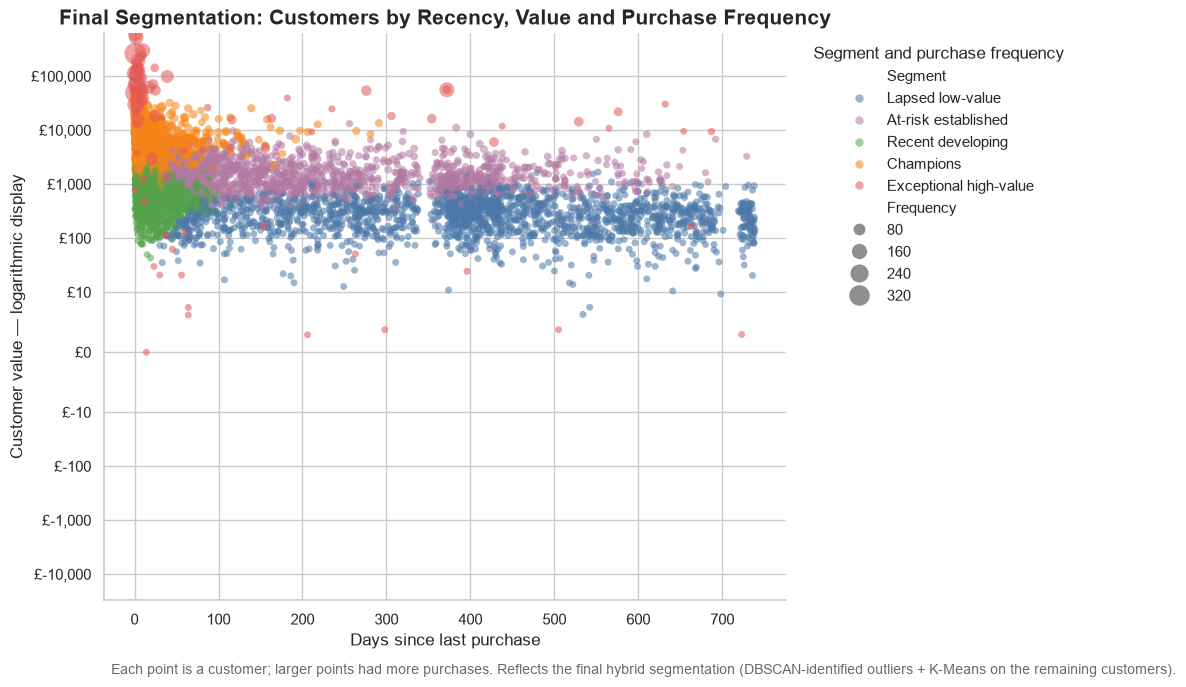

In [312]:
# Business scatter, final segmentation (supersedes the earlier clustered_rfm
# version -- Outlier is now its own visible group, not folded into Champions).
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=hybrid_plot.sort_values("plot_order"),  # Exceptional high-value plotted last, stays visible
    x="Recency",
    y="Monetary",
    hue="Segment",
    size="Frequency",
    sizes=(25, 250),
    palette=hybrid_palette,
    alpha=0.55,
    linewidth=0,
    ax=ax,
)

# Supports Monetary = 0 while compressing the extreme upper range
ax.set_yscale("symlog", linthresh=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"£{value:,.0f}"))

ax.set_title(
    "Final Segmentation: Customers by Recency, Value and Purchase Frequency",
    fontsize=15,
    weight="bold",
)
ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Customer value — logarithmic display")

ax.legend(
    title="Segment and purchase frequency",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.text(
    0.01,
    -0.13,
    "Each point is a customer; larger points had more purchases. Reflects the final hybrid "
    "segmentation (DBSCAN-identified outliers + K-Means on the remaining customers).",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray",
)

sns.despine()
plt.tight_layout()
plt.show()

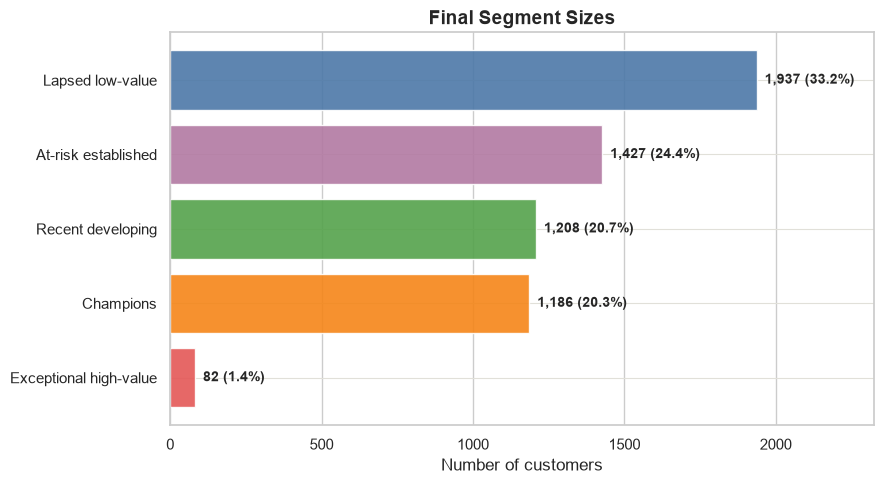

In [313]:
# Segment-size overview. Horizontal bar, not a pie -- five segments of quite
# different sizes are far easier to compare precisely as bar lengths than as
# wedge angles, and direct count/share labels remove any need to eyeball it.
segment_sizes = hybrid_plot["Segment"].value_counts()
segment_share = (segment_sizes / segment_sizes.sum() * 100).round(1)

order = segment_sizes.sort_values(ascending=True).index
colors = [hybrid_palette[s] for s in order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(order, segment_sizes.loc[order], color=colors, alpha=0.9)

for bar, seg in zip(bars, order):
    count = segment_sizes.loc[seg]
    pct = segment_share.loc[seg]
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  {count:,} ({pct}%)",
            va="center", fontsize=10, weight="bold")

ax.set_title("Final Segment Sizes", fontsize=14, weight="bold")
ax.set_xlabel("Number of customers")
ax.set_ylabel("")
ax.set_xlim(0, segment_sizes.max() * 1.2)

style_ax(ax)
plt.tight_layout()
plt.show()